<a href="https://colab.research.google.com/github/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-/blob/main/NB3_Final(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANLOK Water Prediction Project — Notebook 3
## Exploratory Data Analysis (EDA) + Feature Engineering

**Purpose**

This notebook is built directly from the handoff produced by **Notebook 2 — Data Cleaning & Preprocessing**.

The workflow is:

```text
GitHub Repository
      ↓
git pull
      ↓
Outputs/CleanData/              ← Notebook 2
      ↓
Notebook 3
      ├── Data inventory
      ├── Statistical EDA
      ├── Distribution analysis
      ├── Correlation analysis
      ├── Water-focused analysis
      ├── Temporal analysis
      ├── Feature engineering
      └── Modelling-data preparation
              ↓
Outputs/EDA/
Outputs/FeatureEngineering/
Outputs/ModellingData/
      ↓
git add → git commit → git push
      ↓
GitHub Repository
```

> **Important:** Notebook 3 does not repeat Notebook 2's cleaning. It consumes the cleaned datasets generated by Notebook 2 and saves all new results back into the same GitHub repository.


In [1]:
# ============================================================
# ANLOK WATER PREDICTION PROJECT
# NOTEBOOK 3 — EDA + FEATURE ENGINEERING
# ============================================================

print("=" * 90)
print("ANLOK WATER PREDICTION PROJECT")
print("NOTEBOOK 3 — EDA + FEATURE ENGINEERING")
print("=" * 90)


ANLOK WATER PREDICTION PROJECT
NOTEBOOK 3 — EDA + FEATURE ENGINEERING


### Google Colab

This notebook is intended to run from the same GitHub project as Notebook 2.

**Repository:** `LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-`

If you open this notebook from GitHub/Colab, the repository is pulled again before the analysis starts so that Notebook 3 uses the latest Notebook 2 outputs.


In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import glob
import re
import shutil
import subprocess
import warnings
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


In [3]:
# ============================================================
# PROJECT CONFIGURATION
# BASED ON NOTEBOOK 2
# ============================================================

PROJECT_ROOT = "/content/ANLOK-WATER-PREDICTION-PROJECT-"

GITHUB_REPO_URL = "https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git"

# Notebook 2 outputs
CLEAN_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "CleanData"
)

DATA_CLEANING_DIR = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "DataCleaning"
)

# Notebook 3 outputs
EDA_DIR = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "EDA"
)

EDA_VISUALISATION_DIR = os.path.join(
    EDA_DIR,
    "Visualisations"
)

FEATURE_ENGINEERING_DIR = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "FeatureEngineering"
)

FEATURE_VISUALISATION_DIR = os.path.join(
    FEATURE_ENGINEERING_DIR,
    "Visualisations"
)

MODELLING_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "ModellingData"
)

# Create Notebook 3 output directories
for directory in [
    EDA_DIR,
    EDA_VISUALISATION_DIR,
    FEATURE_ENGINEERING_DIR,
    FEATURE_VISUALISATION_DIR,
    MODELLING_DATA_DIR,
]:
    os.makedirs(directory, exist_ok=True)

print("Project configuration loaded.")
print()
print("Project root:")
print(PROJECT_ROOT)
print()
print("GitHub repository:")
print(GITHUB_REPO_URL)
print()
print("Notebook 2 clean data:")
print(CLEAN_DATA_DIR)
print()
print("Notebook 3 EDA outputs:")
print(EDA_DIR)
print()
print("Notebook 3 feature engineering outputs:")
print(FEATURE_ENGINEERING_DIR)
print()
print("Notebook 3 modelling outputs:")
print(MODELLING_DATA_DIR)


Project configuration loaded.

Project root:
/content/ANLOK-WATER-PREDICTION-PROJECT-

GitHub repository:
https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git

Notebook 2 clean data:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData

Notebook 3 EDA outputs:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/EDA

Notebook 3 feature engineering outputs:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering

Notebook 3 modelling outputs:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/ModellingData


In [4]:
# ============================================================
# CONNECT TO / UPDATE THE GITHUB REPOSITORY
# ============================================================

print("=" * 90)
print("GITHUB PROJECT CONNECTION")
print("=" * 90)

git_dir = os.path.join(PROJECT_ROOT, ".git")

# Clone the repository if it is not already present.
if not os.path.exists(git_dir):

    if os.path.exists(PROJECT_ROOT):
        print("Removing incomplete project directory...")
        shutil.rmtree(PROJECT_ROOT)

    print("Cloning GitHub repository...")

    result = subprocess.run(
        ["git", "clone", GITHUB_REPO_URL, PROJECT_ROOT],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "GitHub clone failed. Check the repository URL/access."
        )

    print("Repository cloned successfully.")

else:
    print("Existing Git repository detected.")

# Move into repository.
os.chdir(PROJECT_ROOT)

# Pull the latest version so Notebook 3 receives the newest
# Notebook 2 outputs and any other project updates.
pull_result = subprocess.run(
    ["git", "pull", "--ff-only"],
    capture_output=True,
    text=True
)

print()
print("Git pull:")
print(pull_result.stdout.strip())

if pull_result.returncode != 0:
    print(pull_result.stderr)
    raise RuntimeError(
        "Git pull failed. Resolve the repository state before continuing."
    )

print()
print("GitHub repository is up to date.")


GITHUB PROJECT CONNECTION
Existing Git repository detected.

Git pull:
Already up to date.

GitHub repository is up to date.


In [5]:
# ============================================================
# RECREATE OUTPUT DIRECTORIES AFTER GIT PULL
# ============================================================

for directory in [
    EDA_DIR,
    EDA_VISUALISATION_DIR,
    FEATURE_ENGINEERING_DIR,
    FEATURE_VISUALISATION_DIR,
    MODELLING_DATA_DIR,
]:
    os.makedirs(directory, exist_ok=True)

print("Notebook 3 output directories are ready.")


Notebook 3 output directories are ready.


In [6]:
# ============================================================
# VERIFY NOTEBOOK 2 → NOTEBOOK 3 HANDOFF
# ============================================================

print("=" * 90)
print("VERIFYING NOTEBOOK 2 HANDOFF")
print("=" * 90)

if not os.path.exists(CLEAN_DATA_DIR):
    raise FileNotFoundError(
        "Notebook 2 CleanData directory was not found:\n"
        f"{CLEAN_DATA_DIR}\n\n"
        "Run Notebook 2 and push its outputs to GitHub first."
    )

clean_csv_files = sorted(
    glob.glob(
        os.path.join(
            CLEAN_DATA_DIR,
            "*.csv"
        )
    )
)

if len(clean_csv_files) == 0:
    raise FileNotFoundError(
        "No cleaned CSV files were found in Outputs/CleanData."
    )

print()
print(f"Clean datasets found: {len(clean_csv_files)}")

for file in clean_csv_files:
    print("  ✓", os.path.basename(file))

print()
print("Notebook 2 → Notebook 3 handoff verified.")


VERIFYING NOTEBOOK 2 HANDOFF

Clean datasets found: 27
  ✓ Areas of Highest Vulnerability_ 2026_04_21_clean.csv
  ✓ Drinking Water Quality Compliance - SANS 241 _2006 - National [From_ 2022-07-01 To_ 2026-06-30]_clean.csv
  ✓ Households Served with Water_ 2026_04_21_clean.csv
  ✓ Institutional Compliance_ 2026_04_21_clean.csv
  ✓ Microbiological _ Acute Health_ 2026_04_21_clean.csv
  ✓ NIWIS_Access to Water Infrastructure Delivered- Population_16-Jul-2026 _clean.csv
  ✓ NIWIS_GroundwaterStatus_16-Jul-2026 _clean.csv
  ✓ NIWIS_RWT_16-Jul-2026 _clean.csv
  ✓ NIWIS_WasteWaterQuality_16-Jul-2026 _clean.csv
  ✓ NIWIS_Water Supply Reliability - population_16-Jul-2026 _clean.csv
  ✓ Operational_ 2026_04_21_clean.csv
  ✓ People Served with Water_ 2026_04_21_clean.csv
  ✓ Piped Water Households _ 2026_04_21_clean.csv
  ✓ Potable Systems_ 2026_04_21_clean.csv
  ✓ Protests Identified by Municipal IQ_ 2026_04_21_clean.csv
  ✓ Residential Tariffs_ 2026_04_21_clean.csv
  ✓ Source of Water Households

In [7]:
# ============================================================
# LOAD CLEANED DATASETS
# ============================================================

cleaned_datasets = {}

print("=" * 90)
print("LOADING CLEANED DATASETS FROM NOTEBOOK 2")
print("=" * 90)

for file in clean_csv_files:

    filename = os.path.basename(file)

    dataset_name = re.sub(
        r"_clean\.csv$",
        "",
        filename,
        flags=re.IGNORECASE
    )

    try:
        df = pd.read_csv(
            file,
            low_memory=False
        )

        if df.empty and len(df.columns) == 0:
            print(f"SKIPPED: {filename} (empty dataset)")
            continue

        cleaned_datasets[dataset_name] = df

        print(
            f"LOADED: {dataset_name:<50} "
            f"Shape = {df.shape}"
        )

    except Exception as error:
        print(
            f"ERROR loading {filename}: {error}"
        )

print()
print(
    f"Successfully loaded {len(cleaned_datasets)} cleaned datasets."
)


LOADING CLEANED DATASETS FROM NOTEBOOK 2
LOADED: Areas of Highest Vulnerability_ 2026_04_21         Shape = (11, 21)
LOADED: Drinking Water Quality Compliance - SANS 241 _2006 - National [From_ 2022-07-01 To_ 2026-06-30] Shape = (4, 2)
LOADED: Households Served with Water_ 2026_04_21           Shape = (11, 17)
LOADED: Institutional Compliance_ 2026_04_21               Shape = (11, 5)
LOADED: Microbiological _ Acute Health_ 2026_04_21         Shape = (11, 8)
ERROR loading NIWIS_Access to Water Infrastructure Delivered- Population_16-Jul-2026 _clean.csv: No columns to parse from file
LOADED: NIWIS_GroundwaterStatus_16-Jul-2026                Shape = (1946, 8)
LOADED: NIWIS_RWT_16-Jul-2026                              Shape = (9, 5)
LOADED: NIWIS_WasteWaterQuality_16-Jul-2026                Shape = (143, 5)
LOADED: NIWIS_Water Supply Reliability - population_16-Jul-2026  Shape = (144, 13)
LOADED: Operational_ 2026_04_21                            Shape = (11, 8)
LOADED: People Served with

In [8]:
# ============================================================
# DATASET INVENTORY
# ============================================================

inventory_records = []

for name, df in cleaned_datasets.items():

    inventory_records.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Numeric Columns": len(
            df.select_dtypes(include=np.number).columns
        ),
        "Categorical Columns": len(
            df.select_dtypes(exclude=np.number).columns
        ),
        "Datetime Columns": len(
            df.select_dtypes(include=["datetime"]).columns
        ),
        "Missing Values": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum()),
    })

dataset_inventory_df = pd.DataFrame(inventory_records)

display(dataset_inventory_df)

dataset_inventory_df.to_csv(
    os.path.join(
        EDA_DIR,
        "dataset_inventory.csv"
    ),
    index=False
)

print("Dataset inventory saved.")


,Dataset,Rows,Columns,Numeric Columns,Categorical Columns,Datetime Columns,Missing Values,Duplicate Rows
0,Areas of Highest Vulnerability_ 2026_04_21,11,21,0,21,0,0,0
1,Drinking Water Quality Compliance - SANS 241 _...,4,2,1,1,0,0,0
2,Households Served with Water_ 2026_04_21,11,17,2,15,0,0,0
3,Institutional Compliance_ 2026_04_21,11,5,2,3,0,0,0
4,Microbiological _ Acute Health_ 2026_04_21,11,8,2,6,0,0,0
5,NIWIS_GroundwaterStatus_16-Jul-2026,1946,8,1,7,0,0,0
6,NIWIS_RWT_16-Jul-2026,9,5,3,2,0,0,0
7,NIWIS_WasteWaterQuality_16-Jul-2026,143,5,0,5,0,0,0
8,NIWIS_Water Supply Reliability - population_16...,144,13,0,13,0,0,0
9,Operational_ 2026_04_21,11,8,2,6,0,0,0


Dataset inventory saved.


In [9]:
# ============================================================
# DATASET STRUCTURE AND STATISTICAL SUMMARY
# ============================================================

statistical_summary_records = []

for name, df in cleaned_datasets.items():

    print()
    print("=" * 90)
    print(f"DATASET: {name}")
    print("=" * 90)

    print("Shape:", df.shape)
    print()
    print("Columns:")
    print(list(df.columns))

    numeric_df = df.select_dtypes(
        include=np.number
    )

    if not numeric_df.empty:

        summary = numeric_df.describe().T

        summary["missing"] = numeric_df.isna().sum()
        summary["unique"] = numeric_df.nunique()
        summary["dataset"] = name
        summary["feature"] = summary.index

        statistical_summary_records.append(
            summary.reset_index(drop=True)
        )

        print()
        print("Statistical summary:")
        display(
            summary.drop(
                columns=["dataset", "feature"],
                errors="ignore"
            )
        )

if statistical_summary_records:

    statistical_summary_df = pd.concat(
        statistical_summary_records,
        ignore_index=True
    )

    statistical_summary_df.to_csv(
        os.path.join(
            EDA_DIR,
            "statistical_summary.csv"
        ),
        index=False
    )

    print("Statistical summary saved.")
else:
    statistical_summary_df = pd.DataFrame()
    print("No numeric variables were available.")



DATASET: Areas of Highest Vulnerability_ 2026_04_21
Shape: (11, 21)

Columns:
['region', 'time_frame', 'unnamed__2', '1__water_services_planning', '2__management_skill_level__technical', '3__staff_skill_level__technical', '4__technical_staff_capacity__numbers', '5__water_resource_management__wrm', '6__water_conservation___water_demand_management__wc_wdm', '7__drinking_water_safety___regulatory_compliance', '8__basic_sanitation', '9__wastewater_environmental_safety___regulatory_compliance', '10__infrastructure_asset_management__iam', '11__operation___maintenance__o_m__of_assets', '12__financial_management', '13__revenue_collection', '14__financial_asset_management', '15__information_management__it', '16__organisational_performance_monitoring', '17__water_and_sanitation_service_quality', '18__customer_care__crm']

DATASET: Drinking Water Quality Compliance - SANS 241 _2006 - National [From_ 2022-07-01 To_ 2026-06-30]
Shape: (4, 2)

Columns:
['category', 'sans_241__2006']

Statistical su

,count,mean,std,min,25%,50%,75%,max,missing,unique
sans_241__2006,4.0,95.330799,3.009993,91.560539,94.032929,95.471637,96.769507,98.819385,0,4



DATASET: Households Served with Water_ 2026_04_21
Shape: (11, 17)

Columns:
['region', 'time_frame', 'unnamed__2', 'households_served_with_water_1994_to_april_2025', 'households_served_with_water_201415', 'households_served_with_water_201516', 'households_served_with_water_201617', 'households_served_with_water_201718', 'households_served_with_water_201819', 'households_served_with_water_201920', 'households_served_with_water_202021', 'households_served_with_water_202122', 'households_served_with_water_202223', 'households_served_with_water_202324', 'households_served_with_water_202425', 'households_served_with_water_202526', 'planned_households_to_be_served_202627']

Statistical summary:


,count,mean,std,min,25%,50%,75%,max,missing,unique
households_served_with_water_201415,11.0,106.636364,183.282445,0.0,0.0,9.0,144.0,582.0,0,7
households_served_with_water_202122,11.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0,1



DATASET: Institutional Compliance_ 2026_04_21
Shape: (11, 5)

Columns:
['region', 'time_frame', 'unnamed__2', 'potable_water_compliance_percentage', 'effluent_water_compliance_percentage']

Statistical summary:


...


DATASET: Water demand growth_ 2026_04_21
Shape: (11, 10)

Columns:
['region', 'time_frame', 'unnamed__2', 'water_demand_growth', 'non_revenue_water', 'water_losses', 'system_input_volume__litres', 'revenue_water__litres', 'non_revenue_water__litres', 'water_losses__litres']

Statistical summary:


,count,mean,std,min,25%,50%,75%,max,missing,unique
water_demand_growth,11.0,0.644091,4.658074,-10.13,-0.76,0.575,2.795,8.9,0,11
non_revenue_water,11.0,33.991818,7.209728,23.00,28.86,35.020,37.255,48.8,0,11
water_losses,11.0,31.717273,7.135567,23.00,27.84,30.250,34.320,48.8,0,11



DATASET: Weather
Shape: (21301, 14)

Columns:
['station', 'name', 'latitude', 'longitude', 'elevation', 'date', 'prcp', 'prcp_attributes', 'tavg', 'tavg_attributes', 'tmax', 'tmax_attributes', 'tmin', 'tmin_attributes']

Statistical summary:


,count,mean,std,min,25%,50%,75%,max,missing,unique
latitude,21301.0,-25.945538,0.153683,-26.139,-26.139,-25.917,-25.917,-25.733,0,3
longitude,21301.0,28.218314,0.023565,28.183,28.217,28.217,28.246,28.246,0,3
elevation,21301.0,1520.803319,140.180907,1322.000,1500.000,1500.000,1694.100,1694.100,0,3
prcp,21301.0,1.962011,6.763627,0.000,0.500,0.500,0.500,340.100,0,213
tavg,21301.0,17.589860,4.466002,0.800,14.300,18.100,20.900,31.400,0,275
tmax,21301.0,25.282574,4.443200,6.900,22.300,25.600,28.400,38.800,0,284
tmin,21301.0,11.538435,4.430464,-7.000,8.900,12.200,14.600,26.100,0,276


Statistical summary saved.


In [10]:
# ============================================================
# IDENTIFY WATER-RELATED VARIABLES
# ============================================================

water_keywords = [
    "water",
    "supply",
    "demand",
    "reliab",
    "access",
    "storage",
    "flow",
    "rain",
    "precip",
    "groundwater",
    "surface",
    "quality",
    "compliance",
    "population",
    "household",
    "vulnerability",
    "protest",
    "tariff",
    "temperature",
    "reservoir",
]

water_variable_records = []

for name, df in cleaned_datasets.items():

    for column in df.columns:

        column_lower = str(column).lower()

        matched_keywords = [
            keyword
            for keyword in water_keywords
            if keyword in column_lower
        ]

        if matched_keywords:

            water_variable_records.append({
                "Dataset": name,
                "Column": column,
                "Matched Keywords": ", ".join(
                    matched_keywords
                ),
                "Data Type": str(df[column].dtype),
                "Unique Values": int(
                    df[column].nunique()
                ),
                "Missing Values": int(
                    df[column].isna().sum()
                ),
            })

water_variables_df = pd.DataFrame(
    water_variable_records
)

display(water_variables_df)

water_variables_df.to_csv(
    os.path.join(
        EDA_DIR,
        "water_related_variables.csv"
    ),
    index=False
)

print("Water-related variable inventory saved.")


,Dataset,Column,Matched Keywords,Data Type,Unique Values,Missing Values
0,Areas of Highest Vulnerability_ 2026_04_21,1__water_services_planning,water,object,5,0
1,Areas of Highest Vulnerability_ 2026_04_21,5__water_resource_management__wrm,water,object,5,0
2,Areas of Highest Vulnerability_ 2026_04_21,6__water_conservation___water_demand_managemen...,"water, demand",object,4,0
3,Areas of Highest Vulnerability_ 2026_04_21,7__drinking_water_safety___regulatory_compliance,"water, compliance",object,4,0
4,Areas of Highest Vulnerability_ 2026_04_21,9__wastewater_environmental_safety___regulator...,"water, compliance",object,5,0
...,...,...,...,...,...,...
89,Water demand growth_ 2026_04_21,non_revenue_water,water,float64,11,0
90,Water demand growth_ 2026_04_21,water_losses,water,float64,11,0
91,Water demand growth_ 2026_04_21,revenue_water__litres,water,object,11,0
92,Water demand growth_ 2026_04_21,non_revenue_water__litres,water,object,11,0


Water-related variable inventory saved.


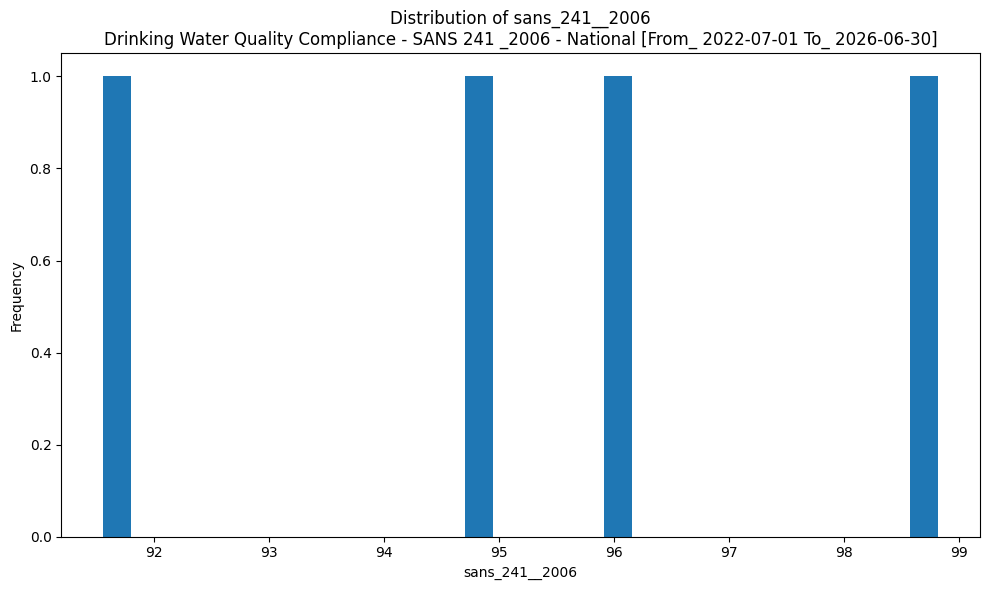

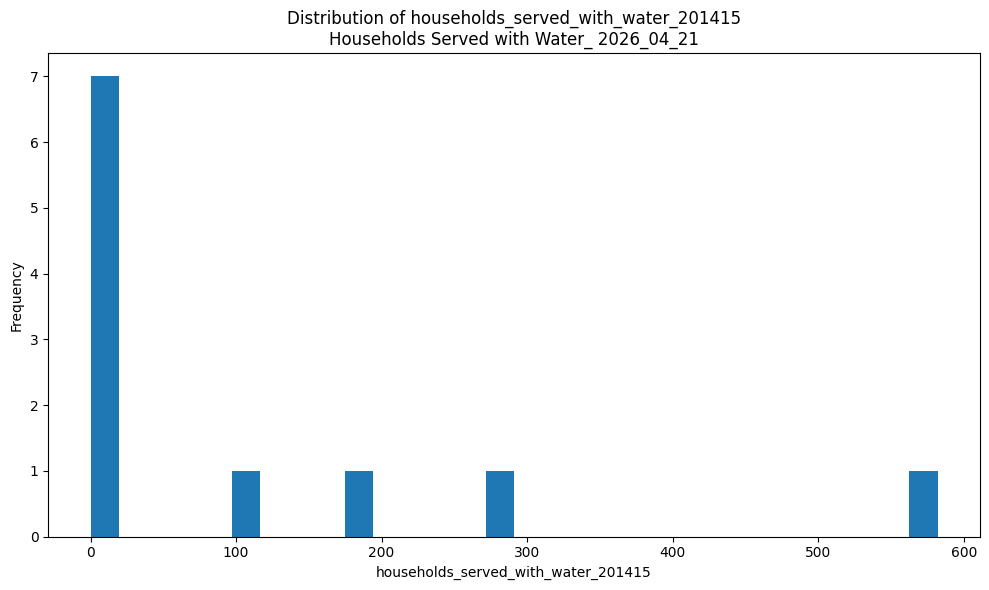

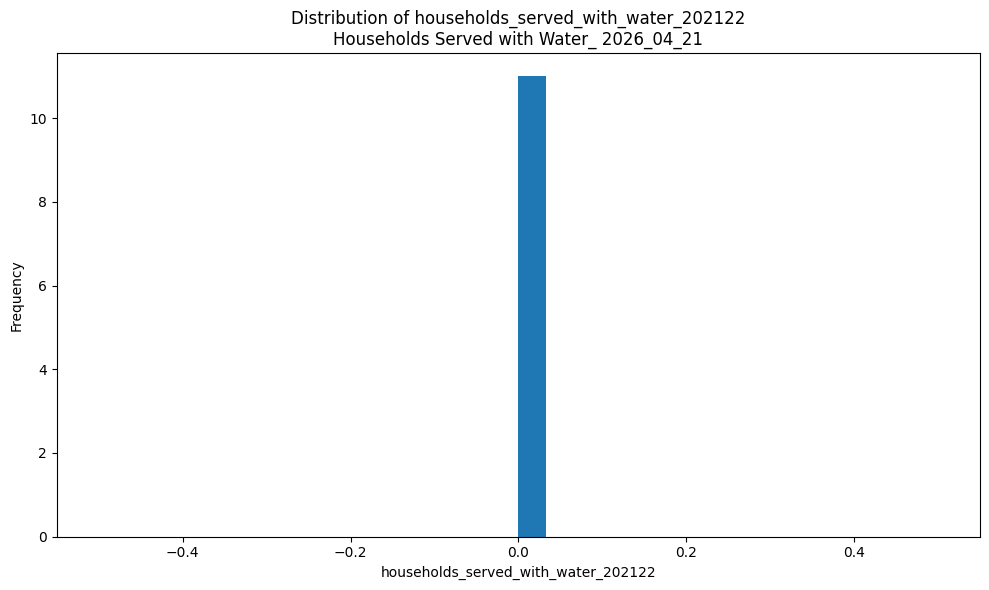

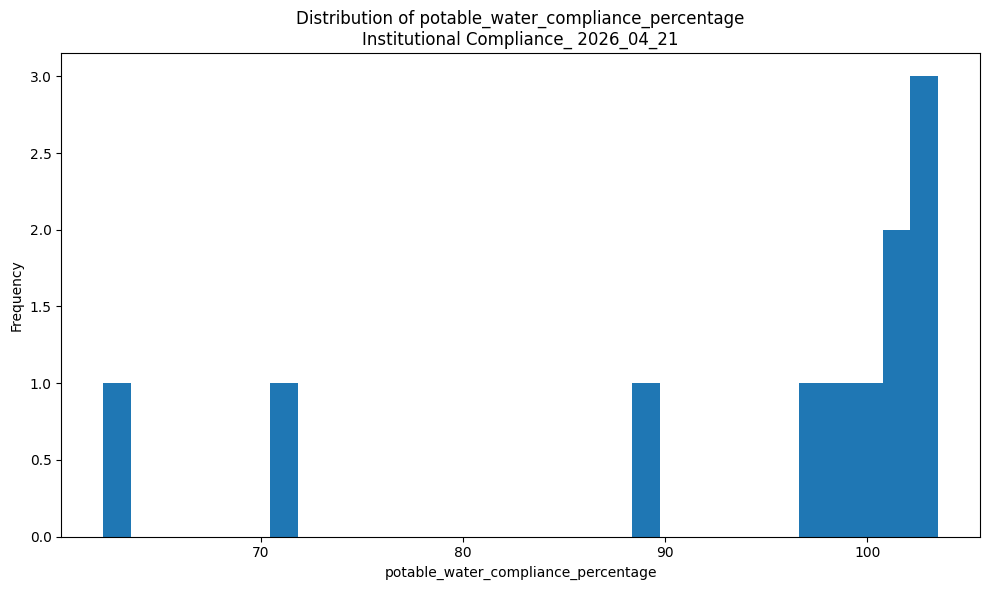

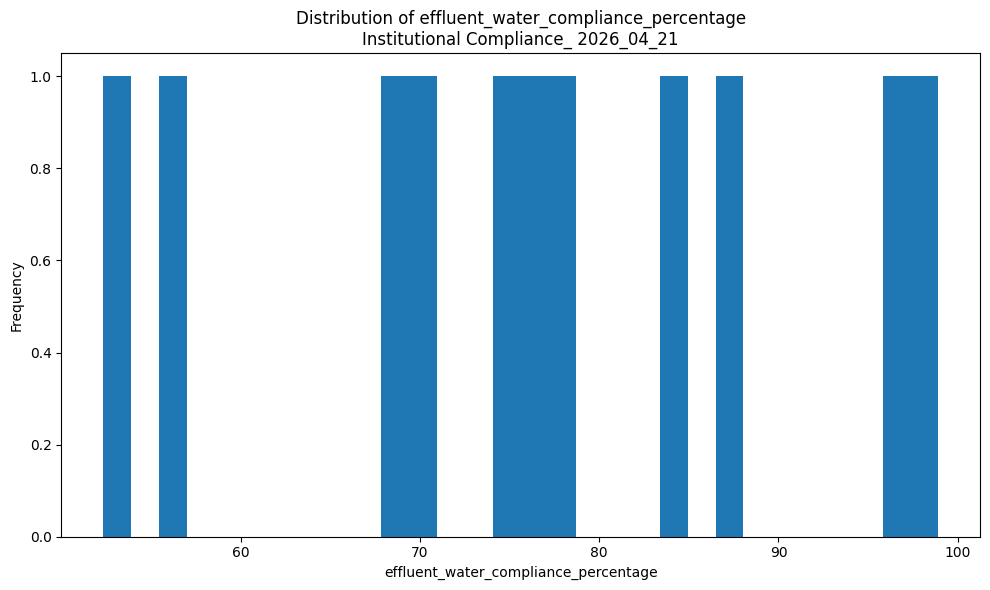

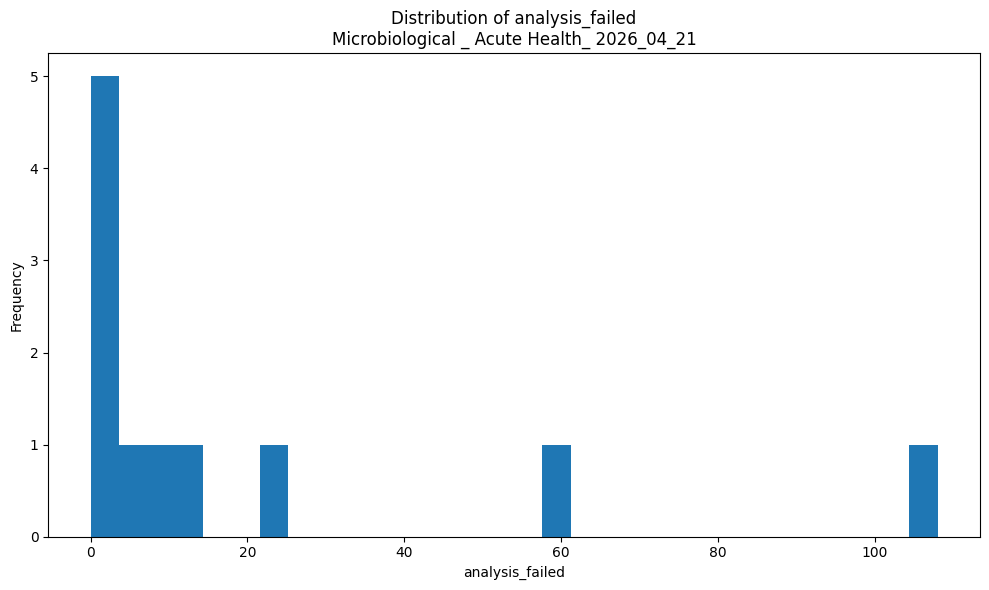

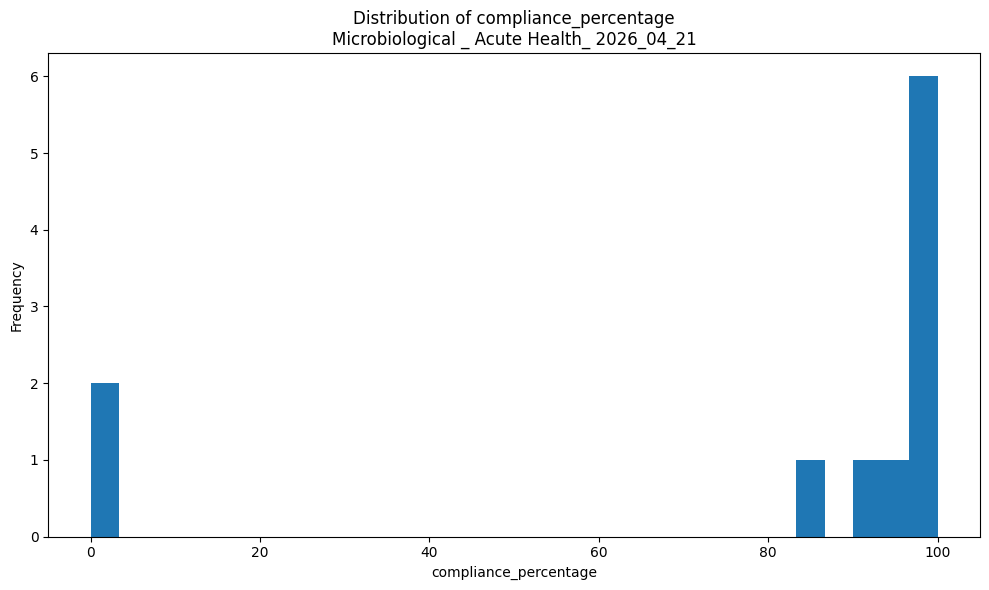

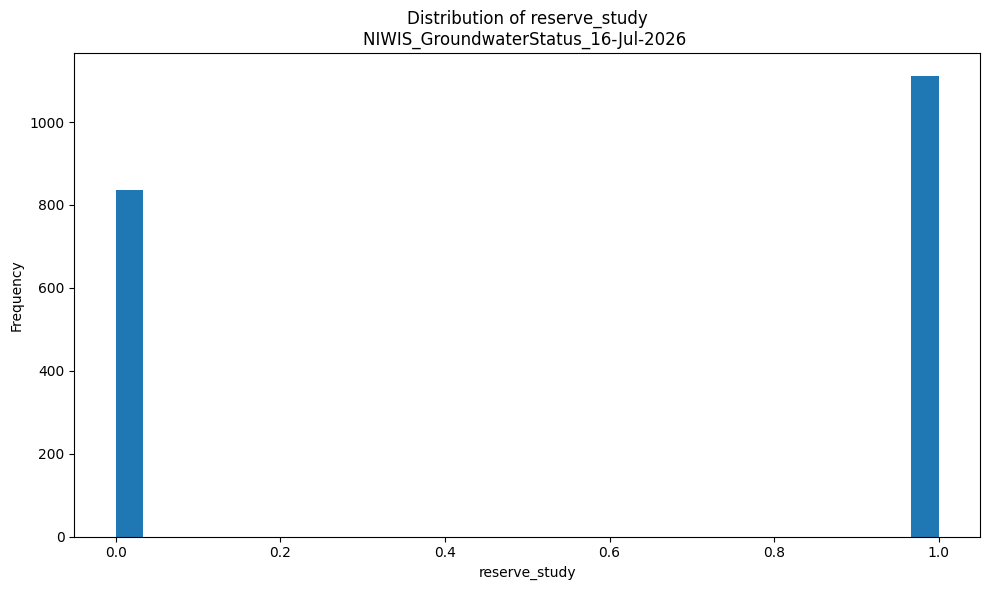

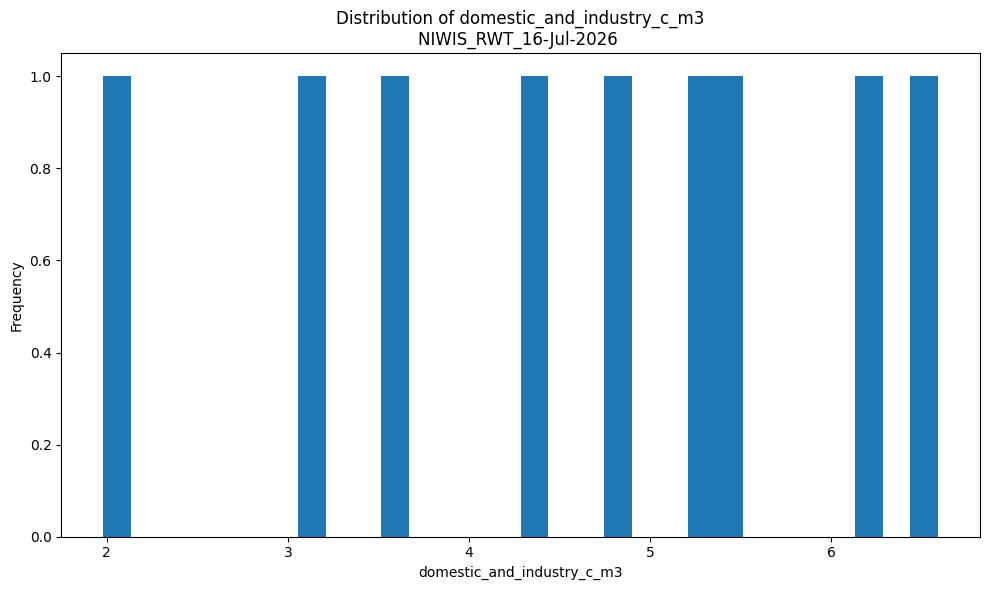

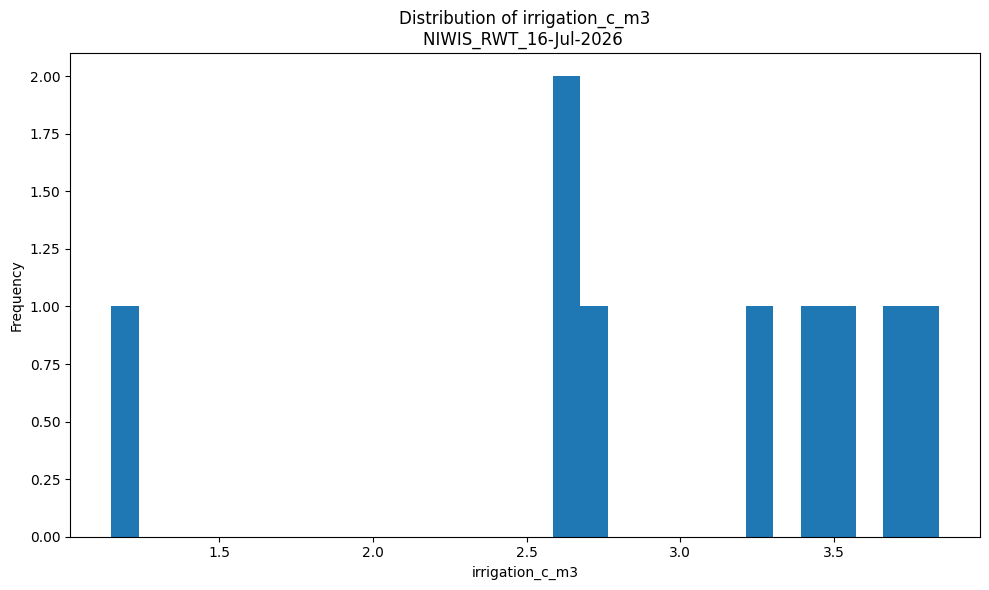

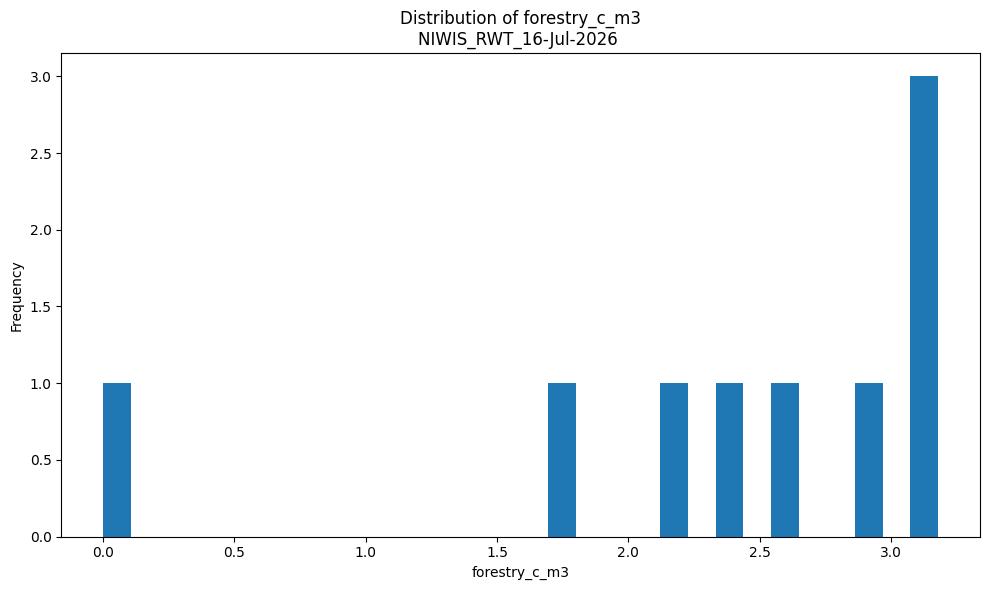

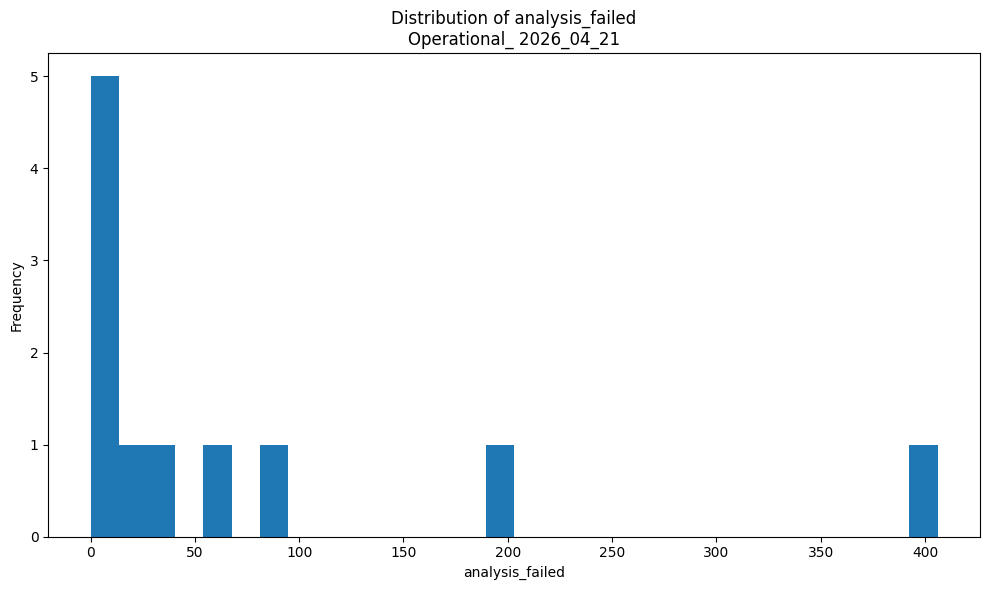

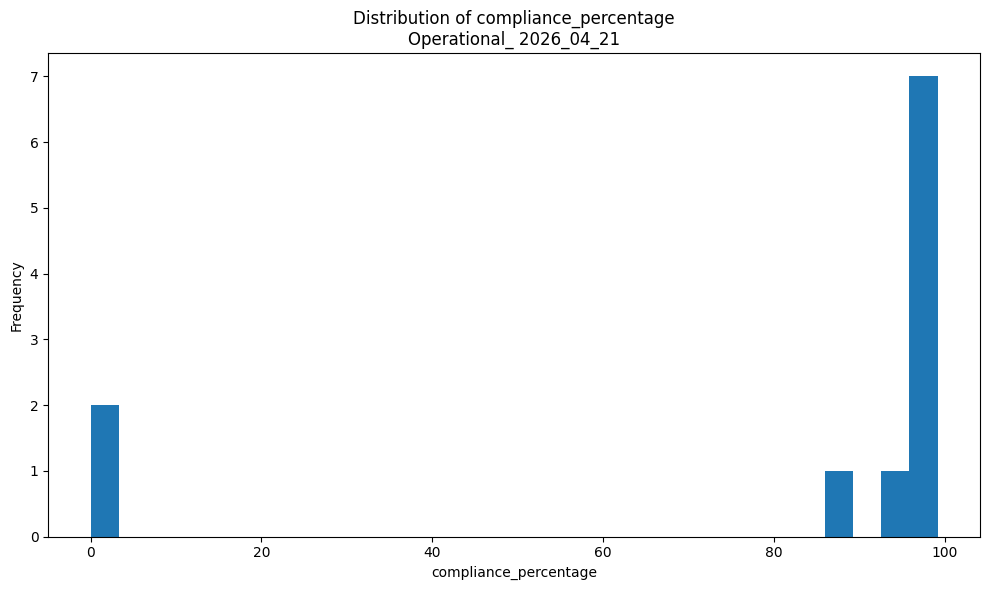

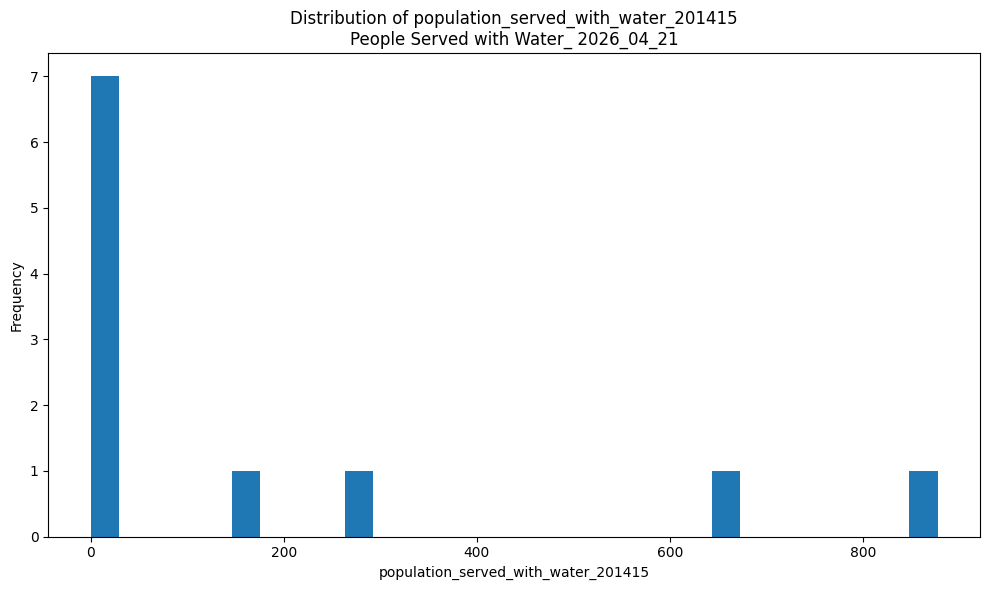

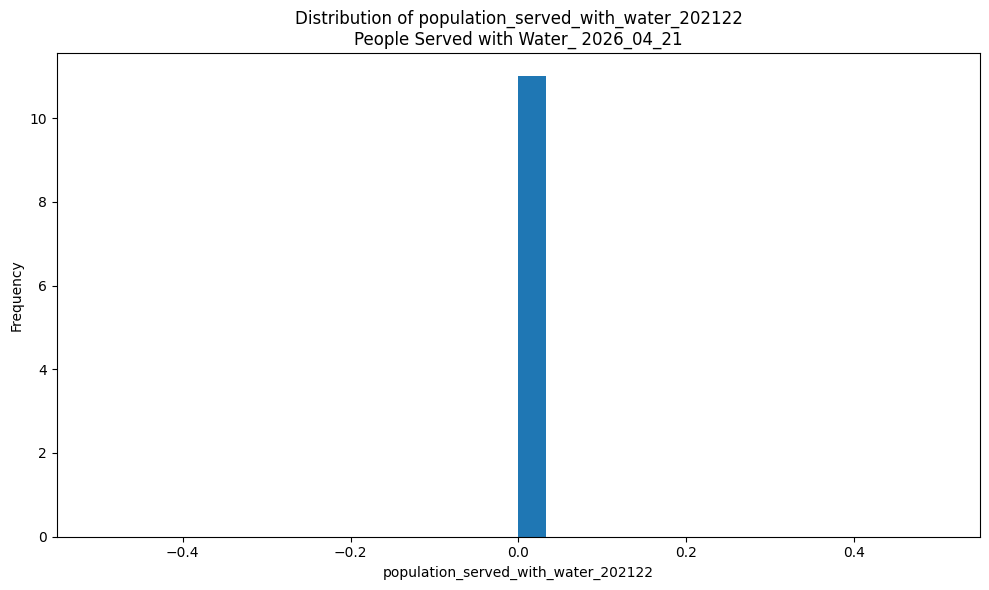

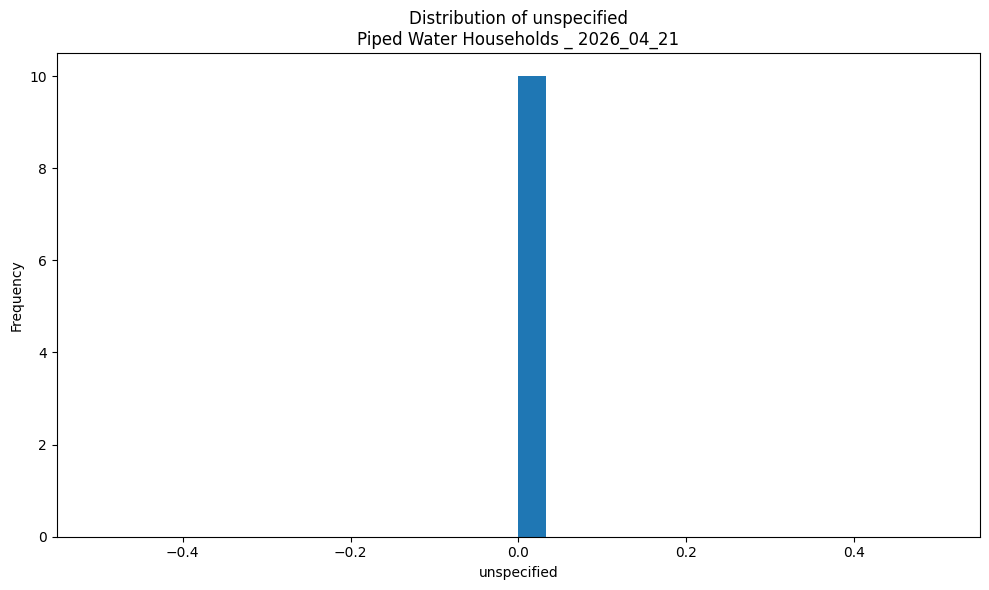

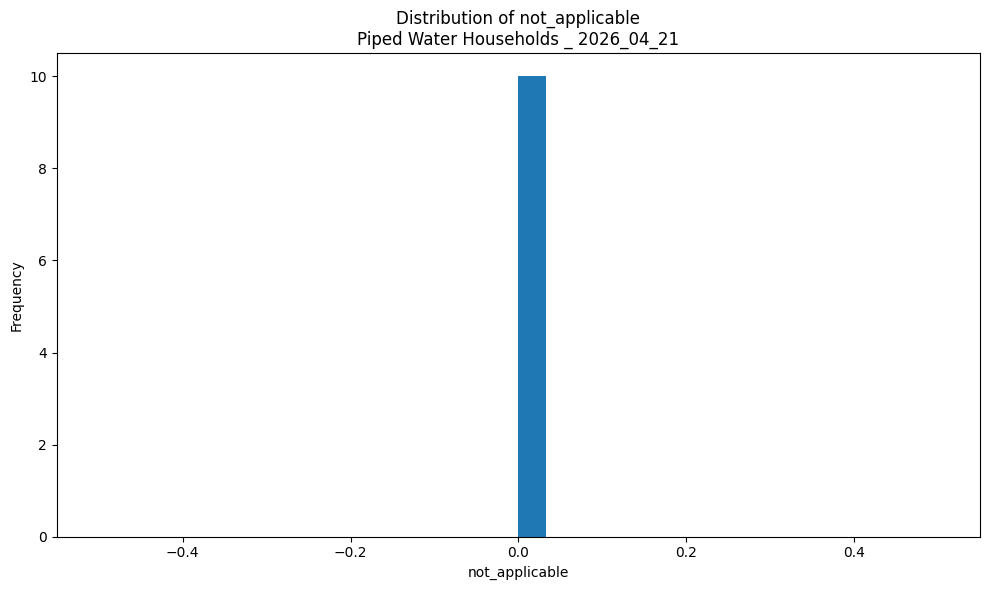

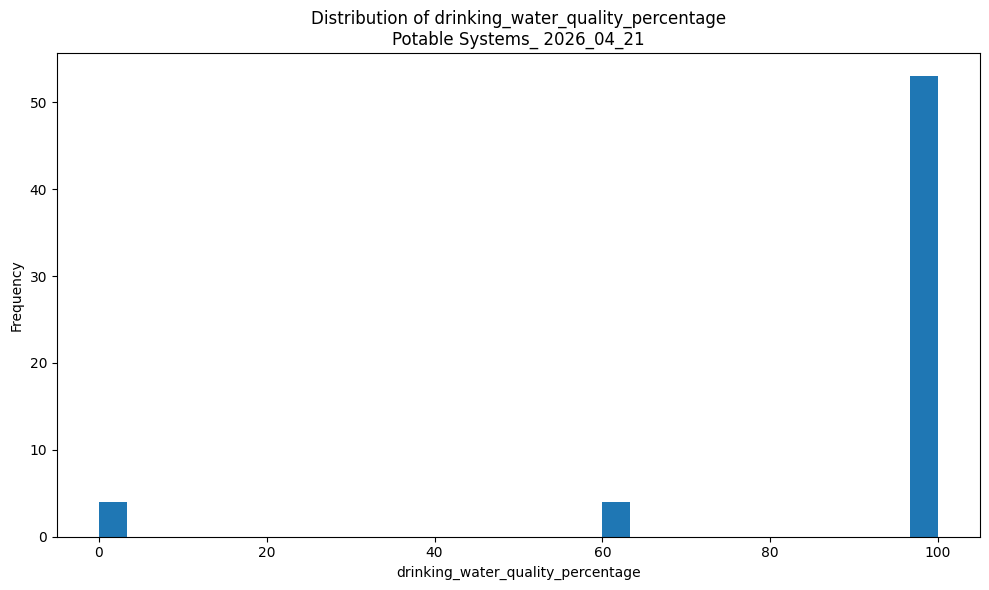

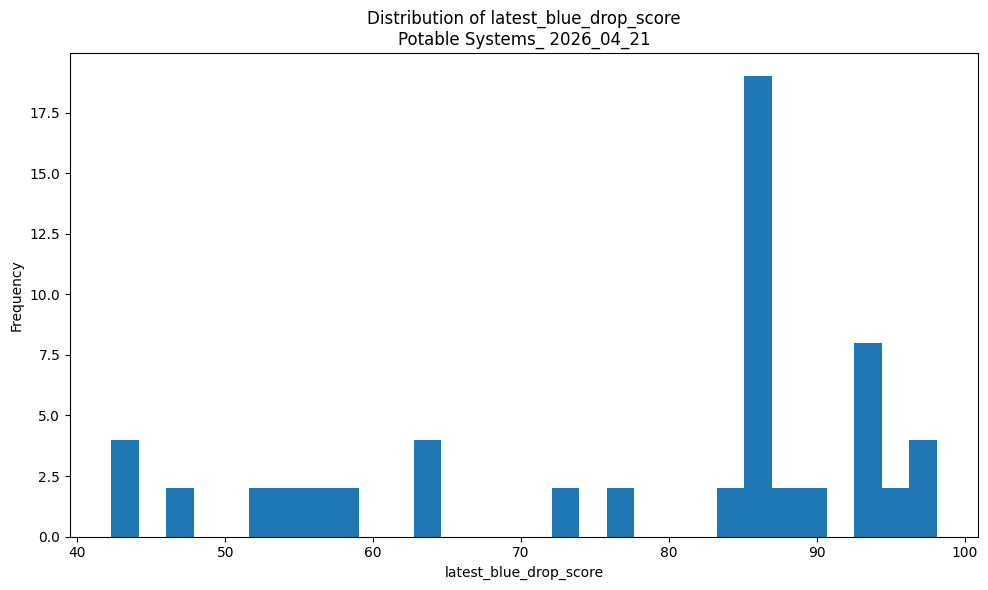

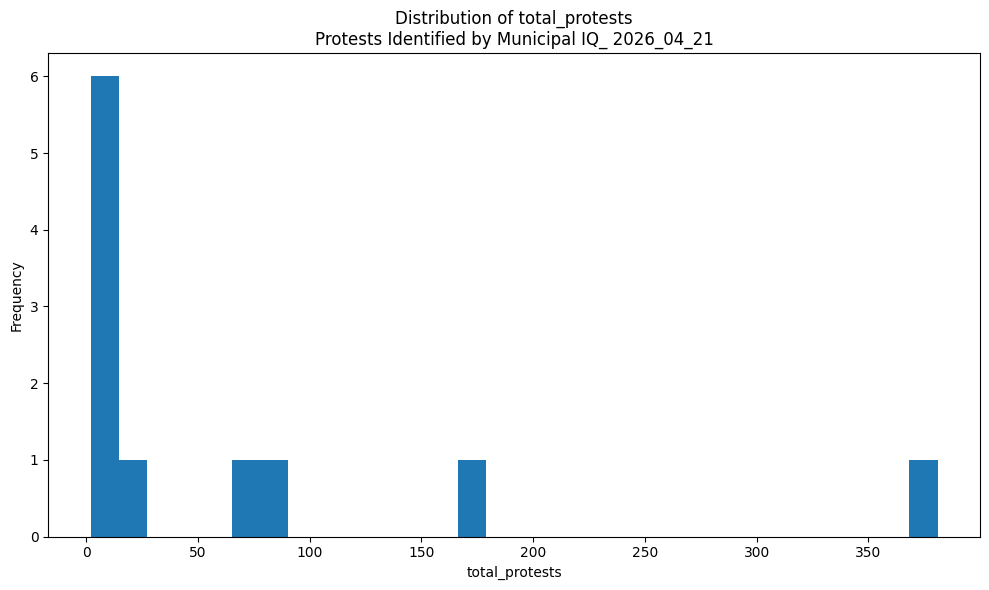

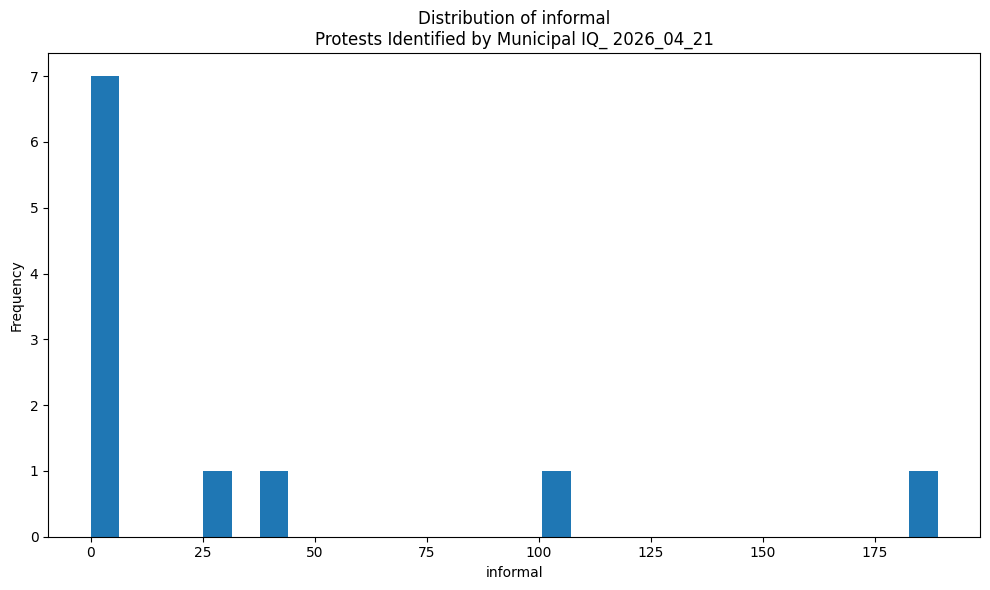

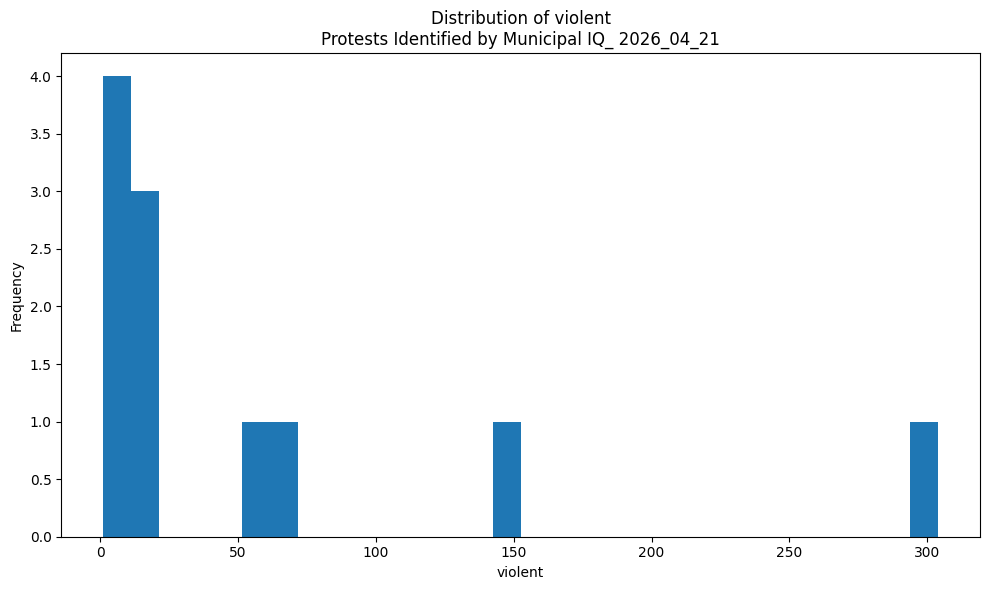

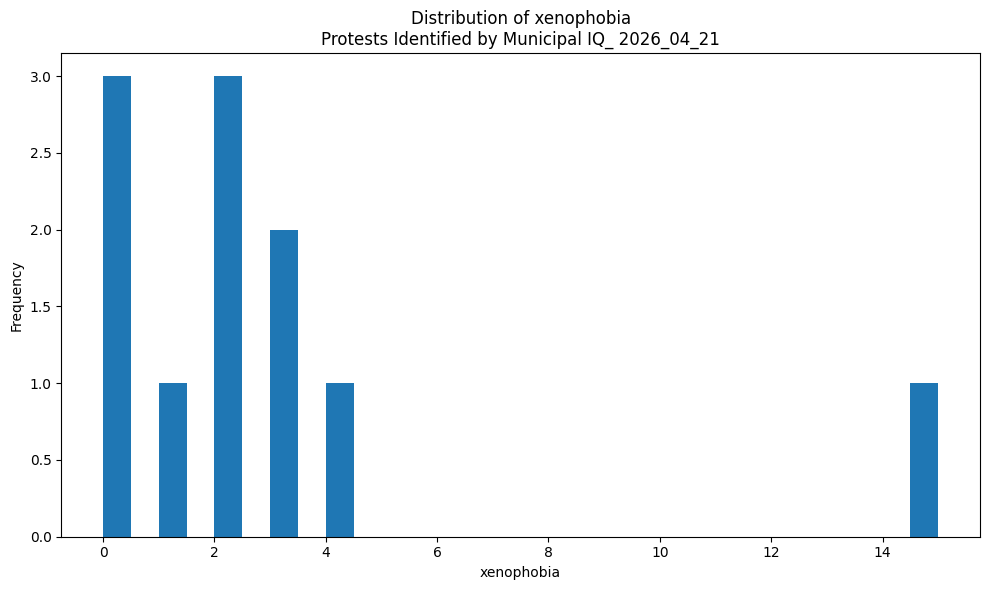

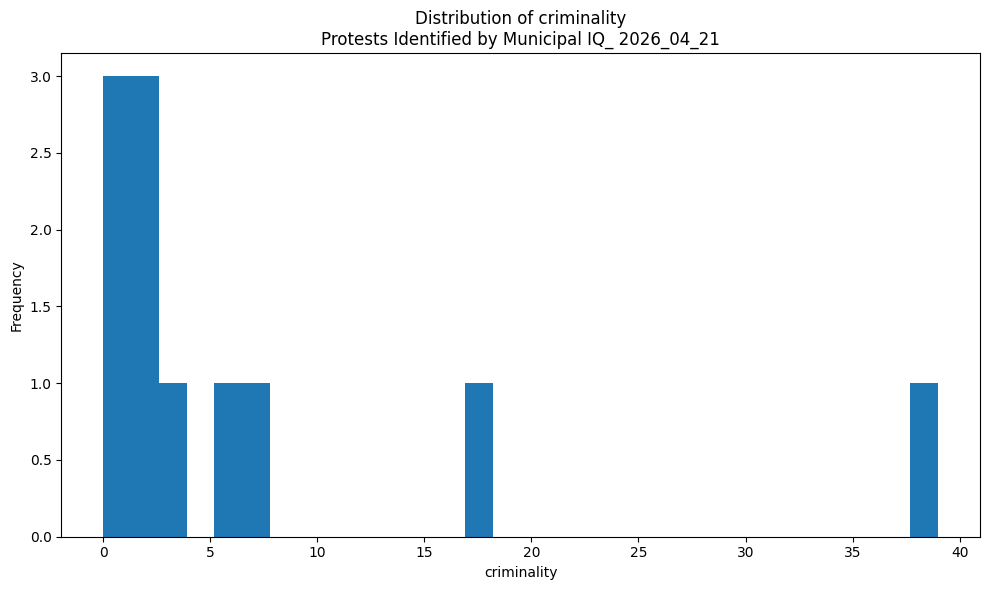

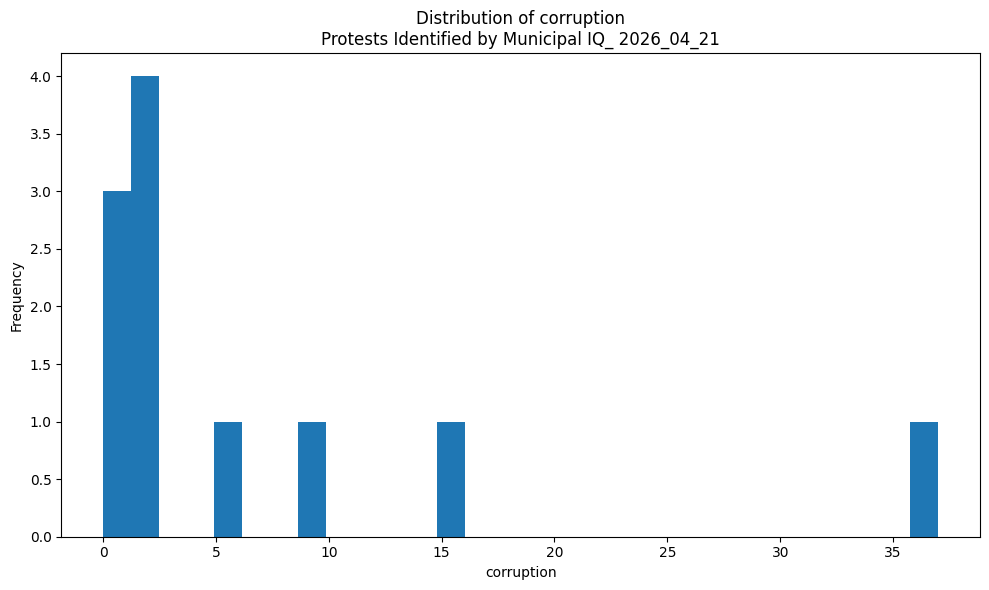

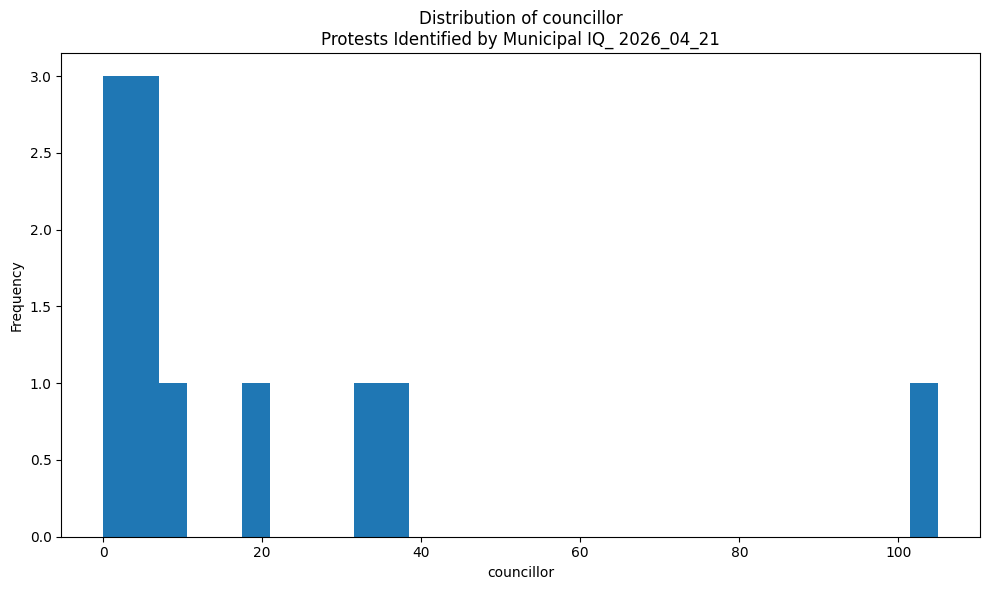

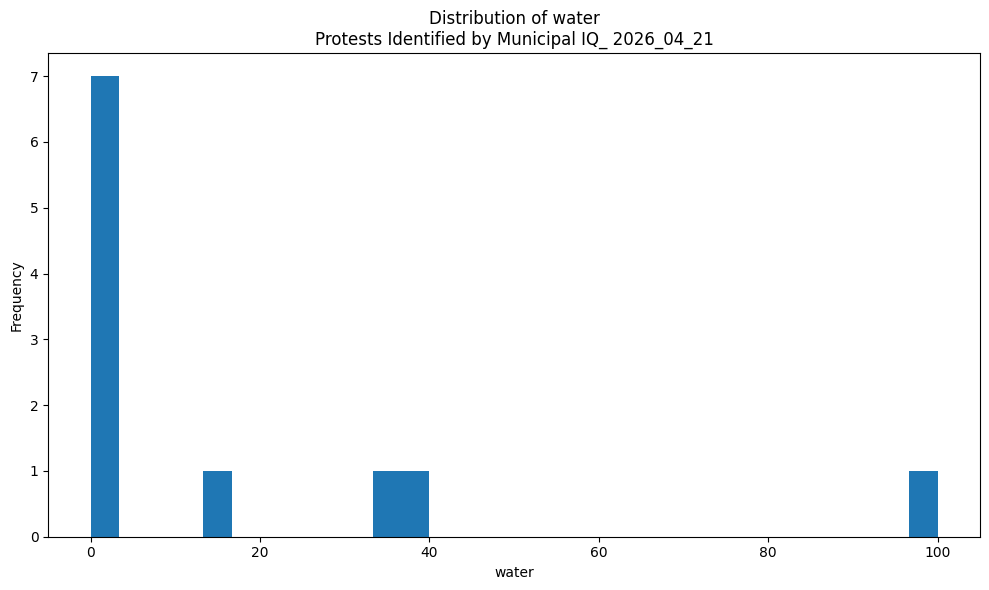

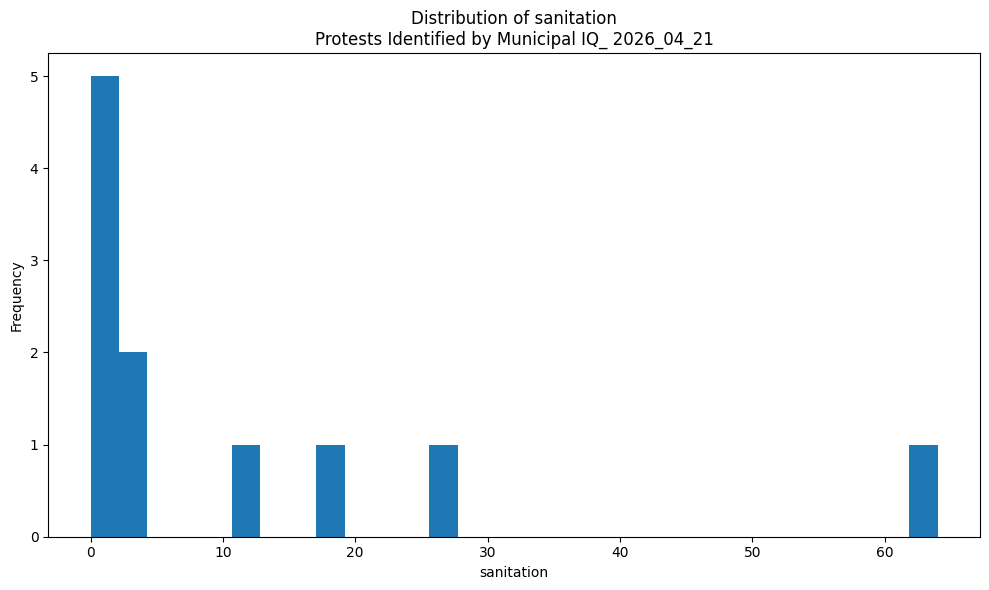

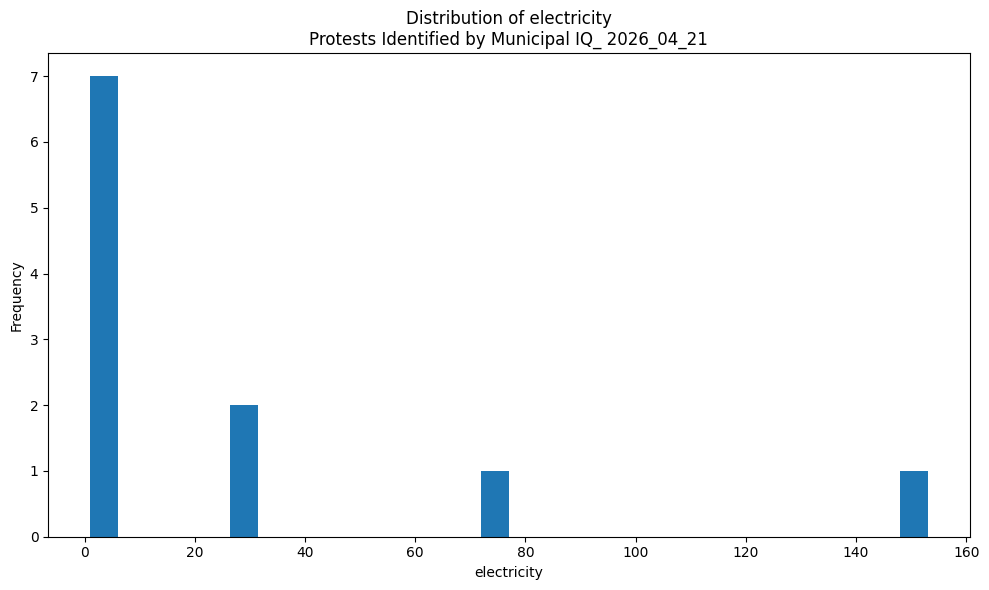

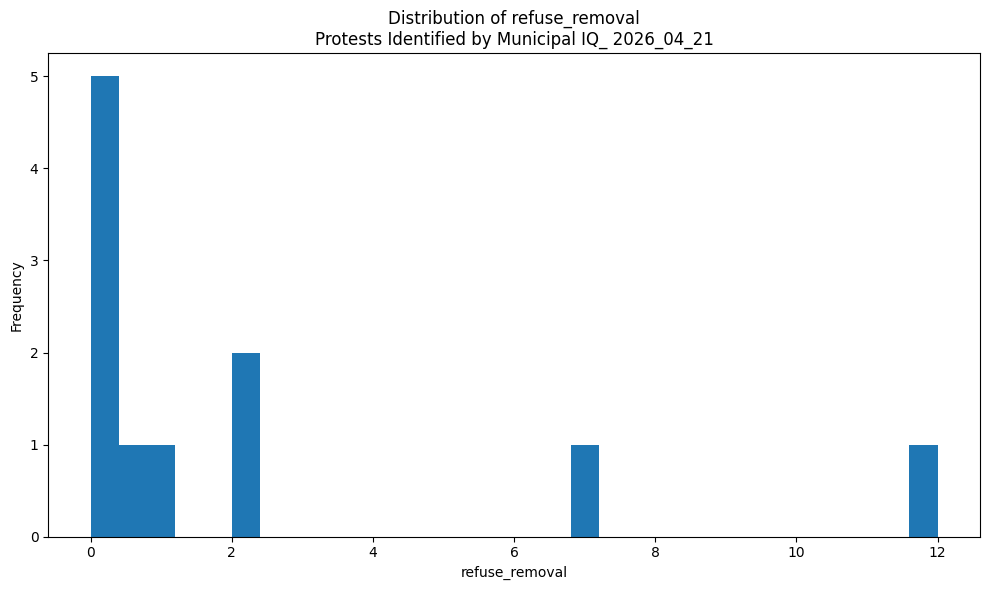

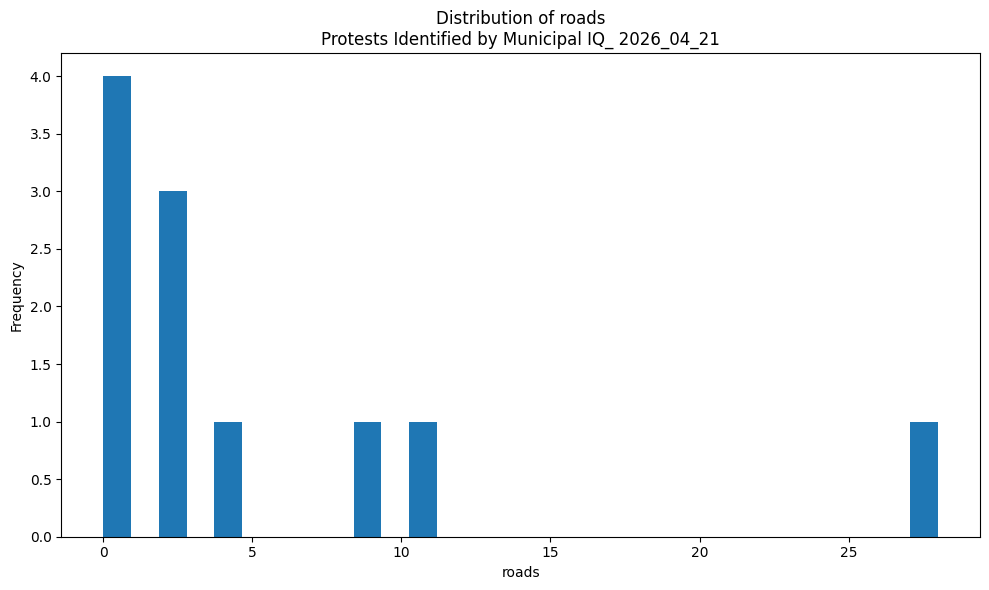

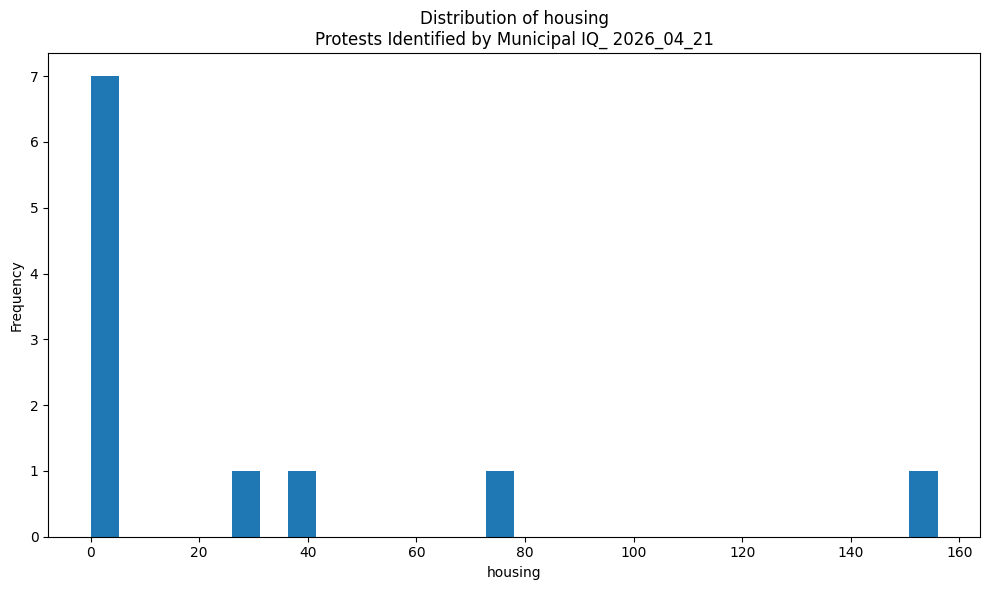

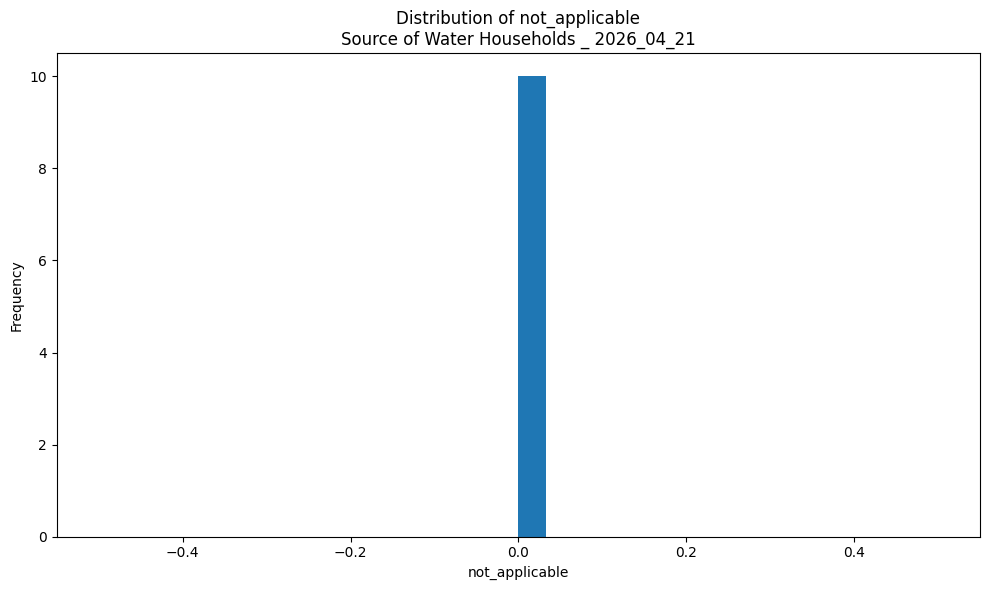

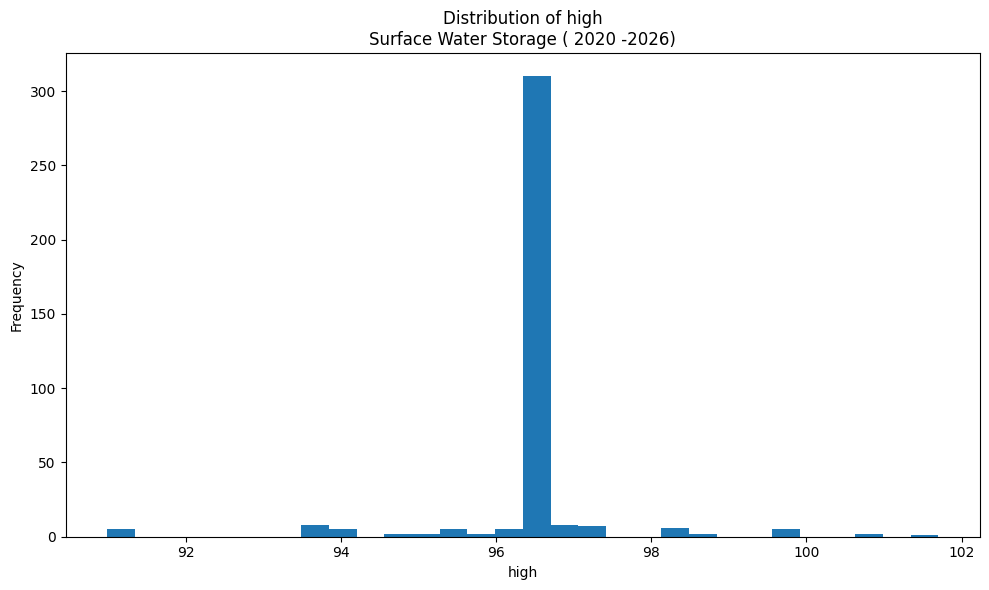

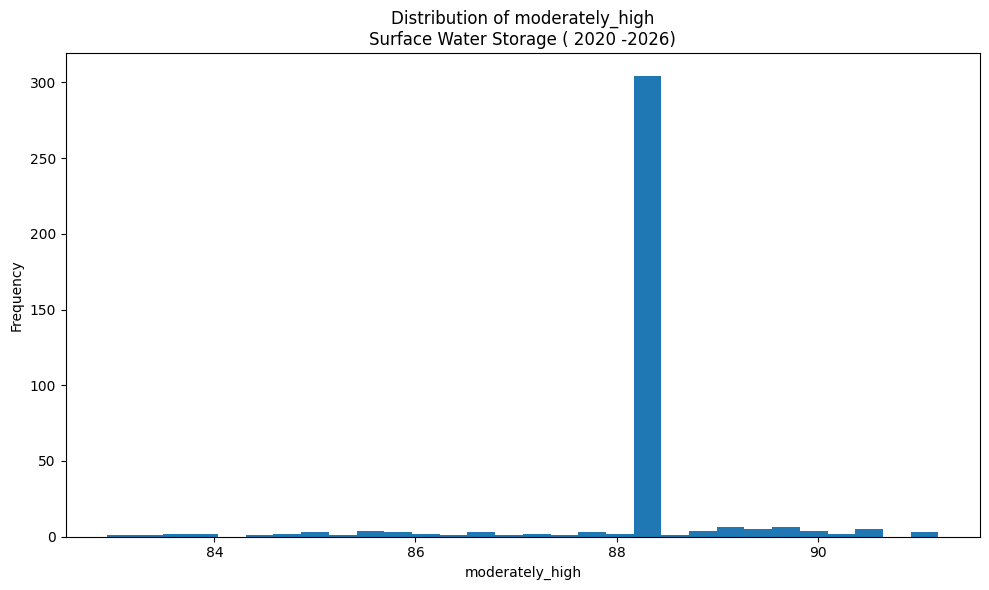

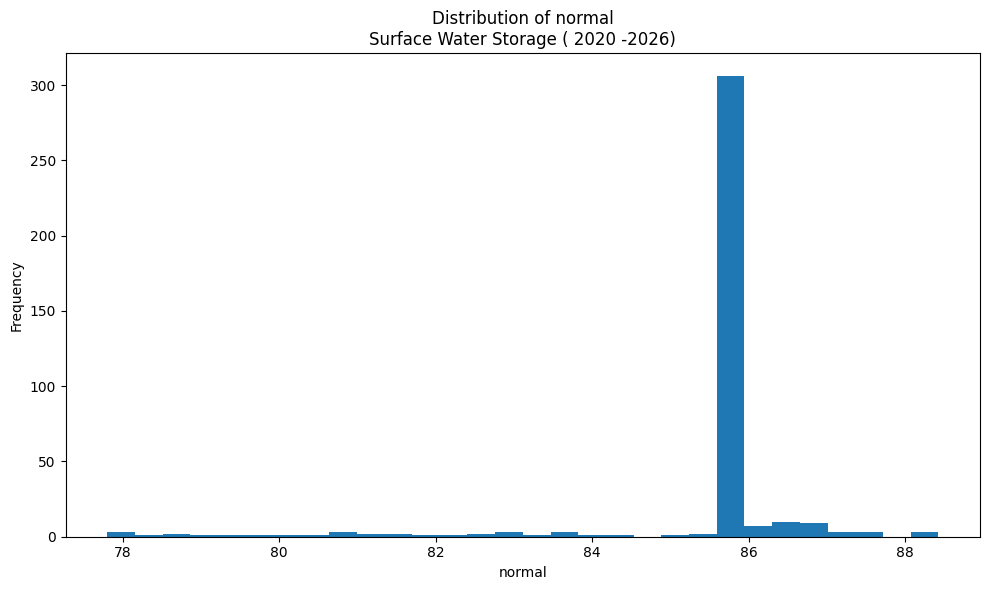

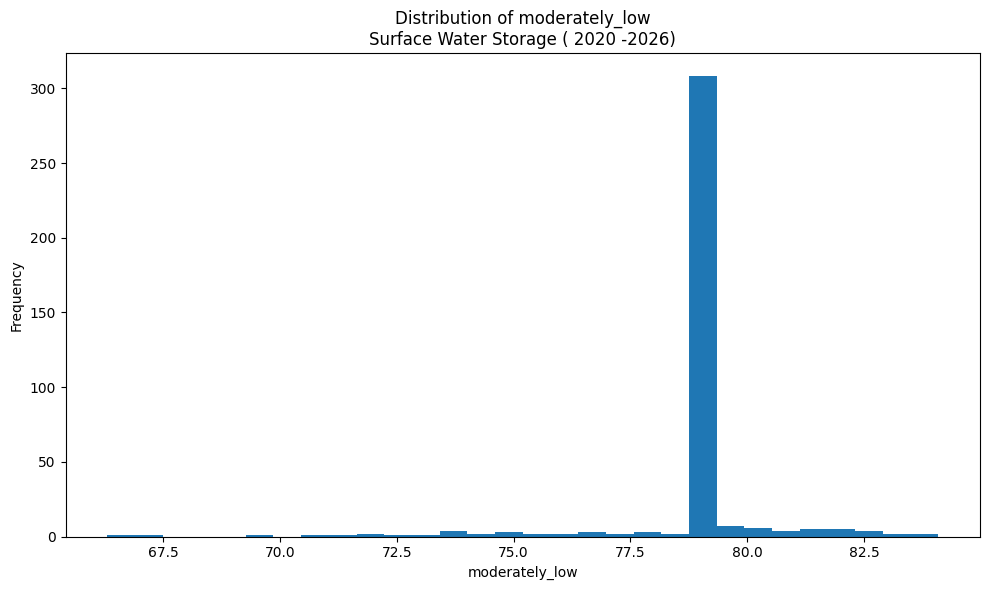

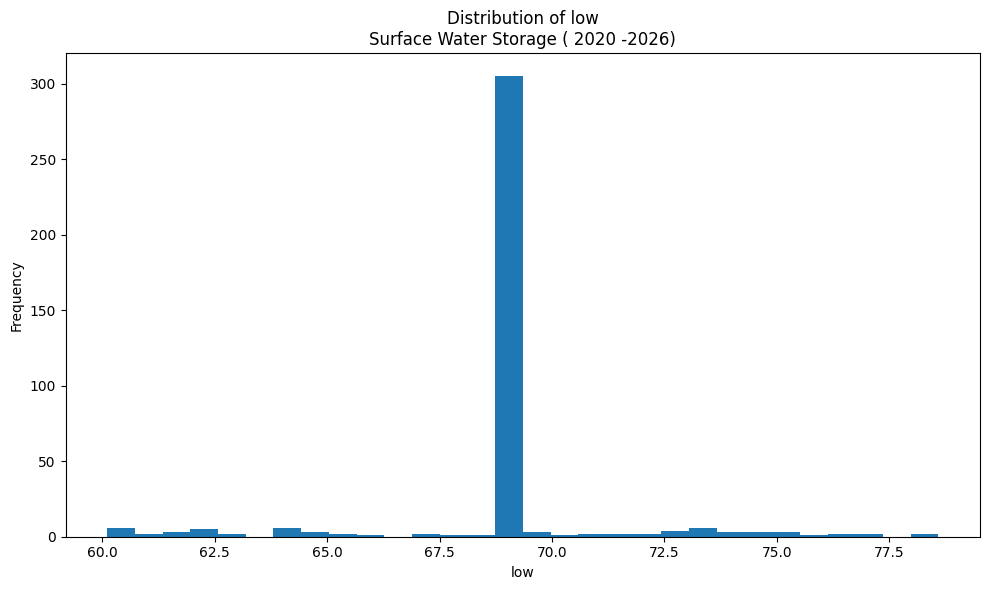

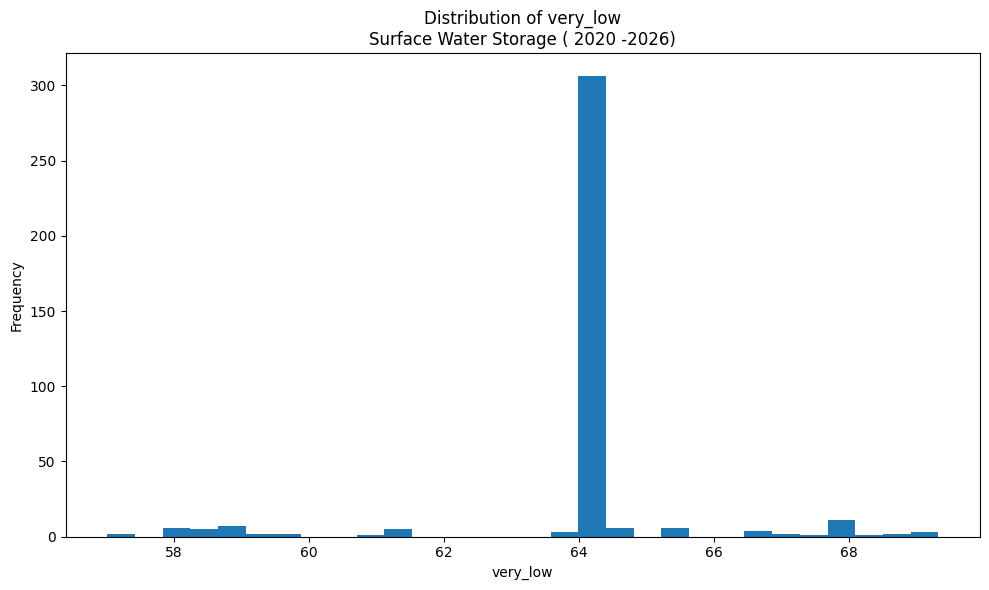

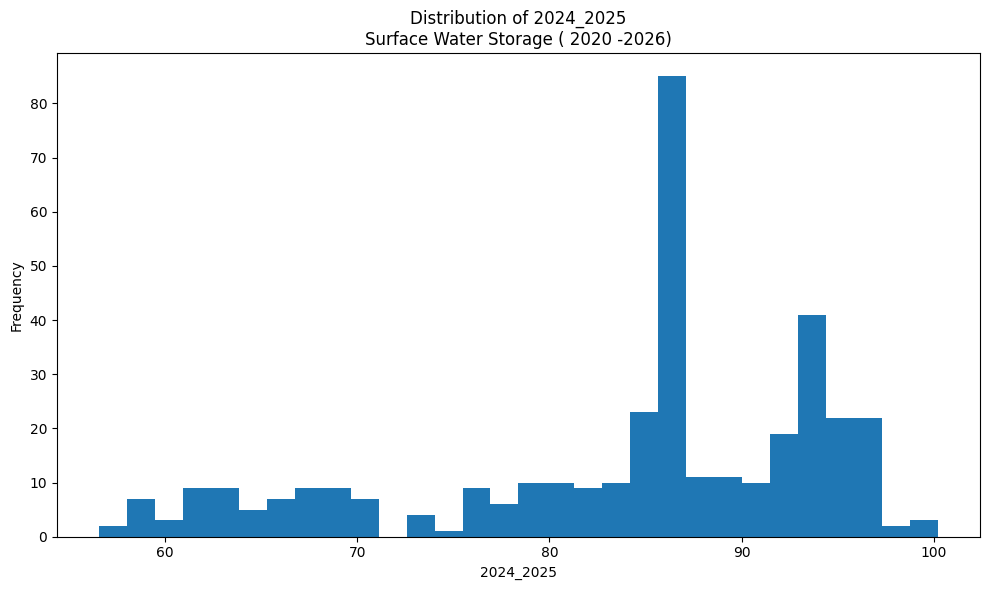

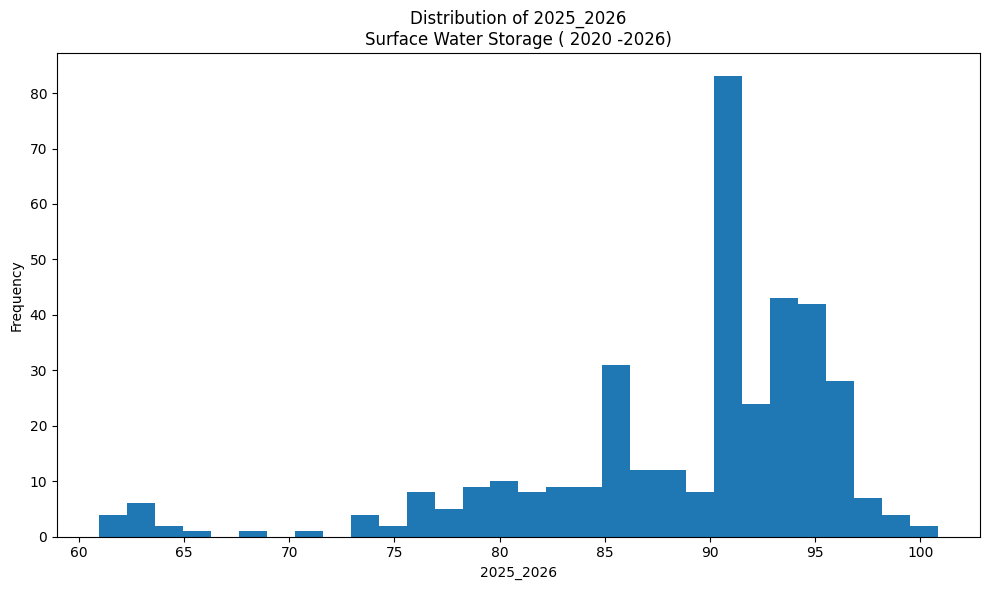

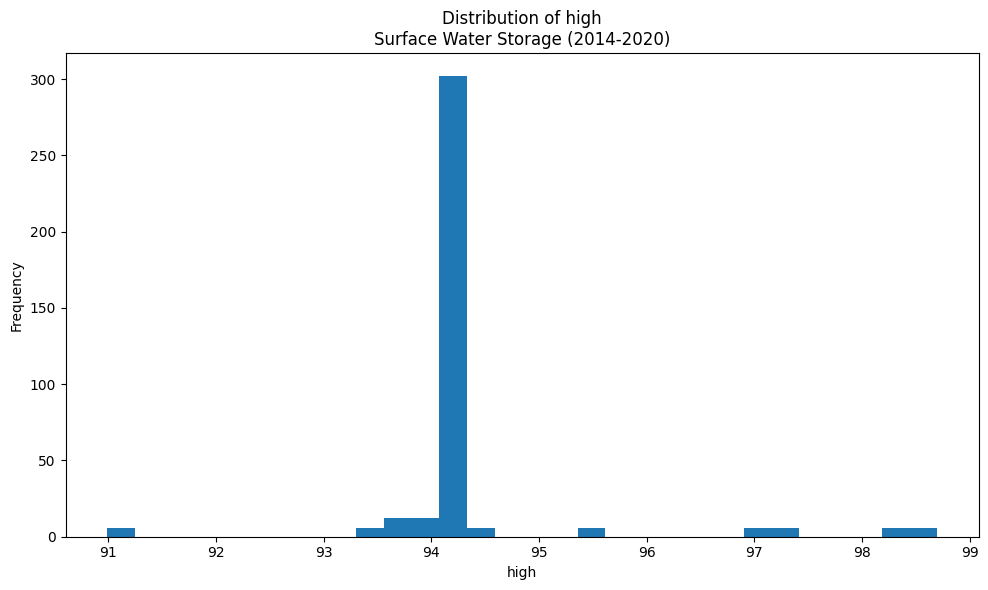

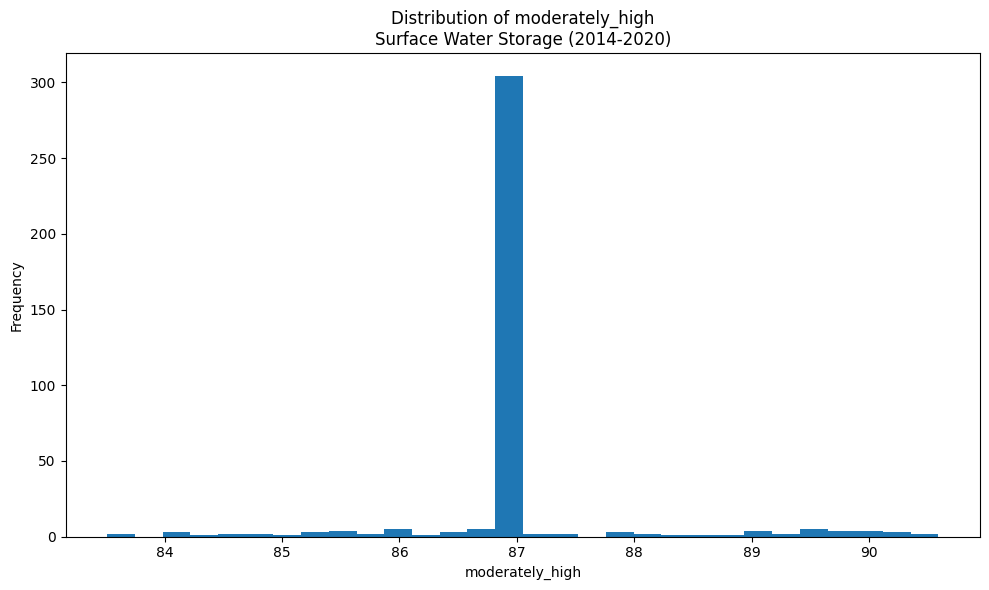

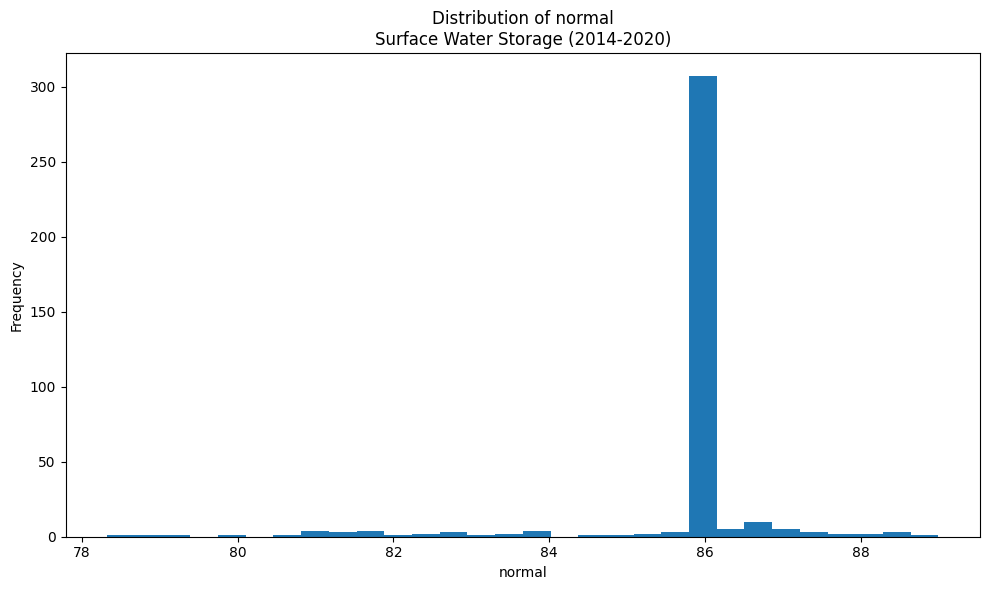

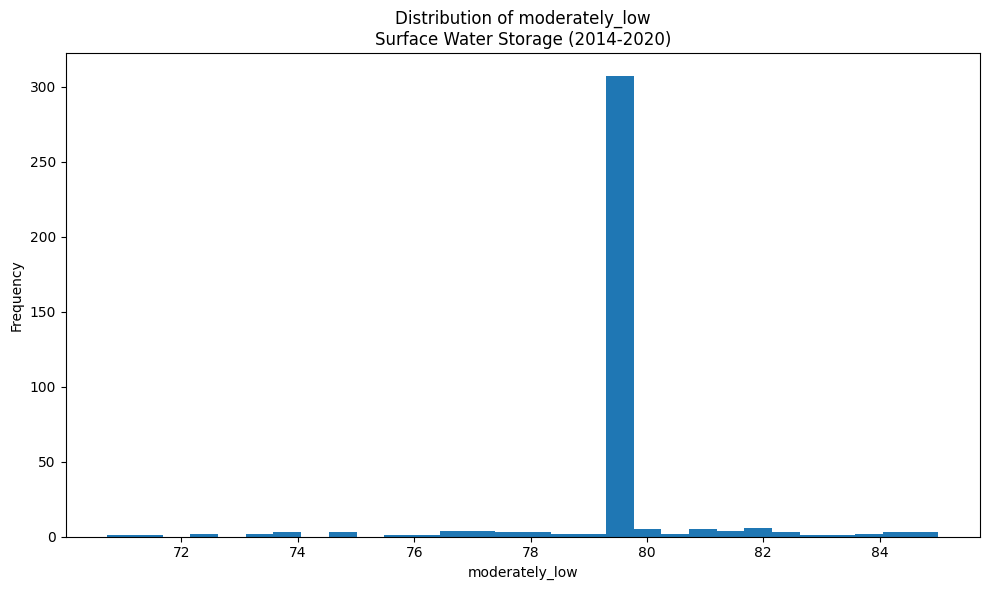

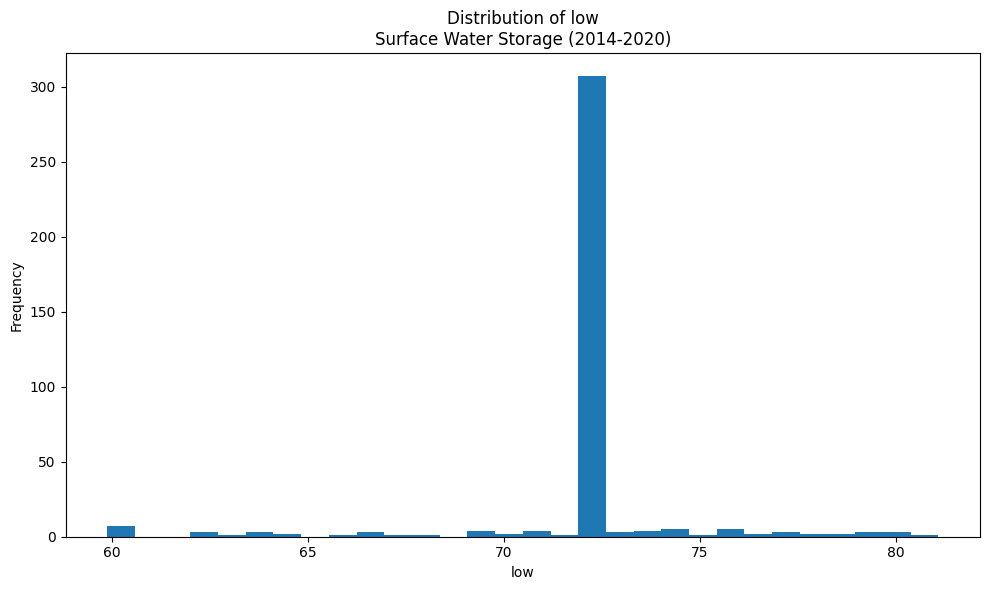

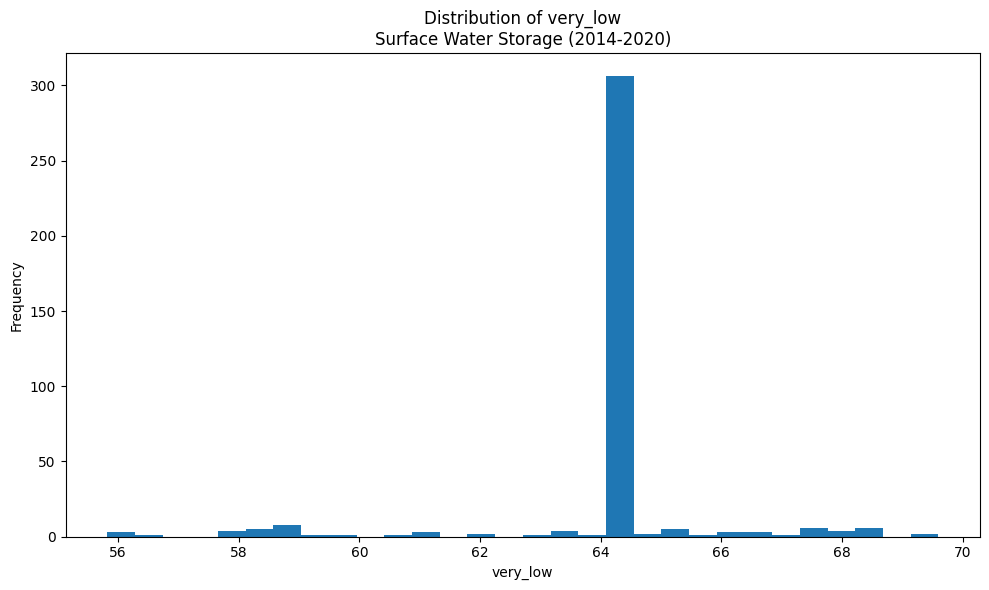

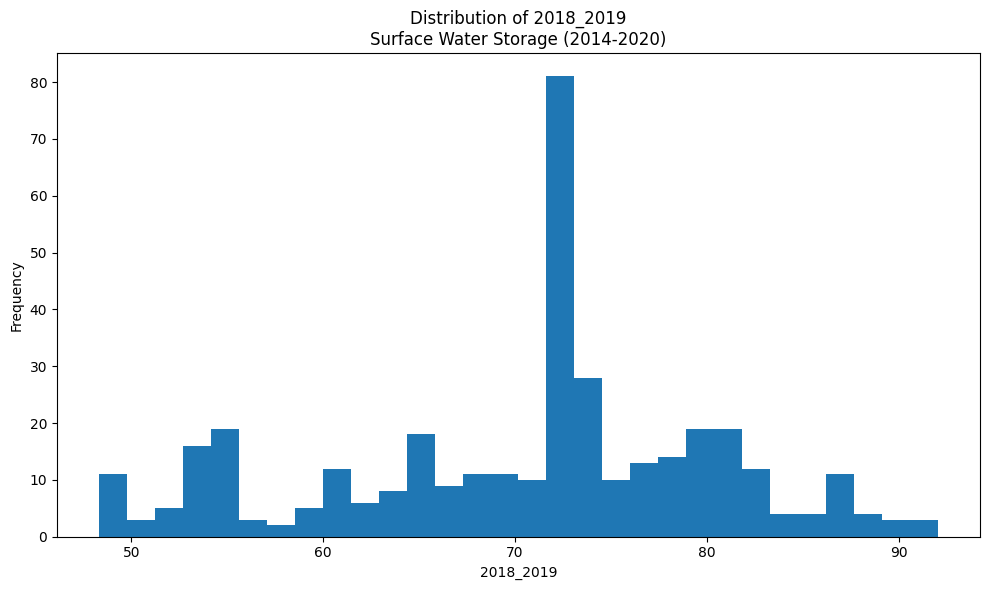

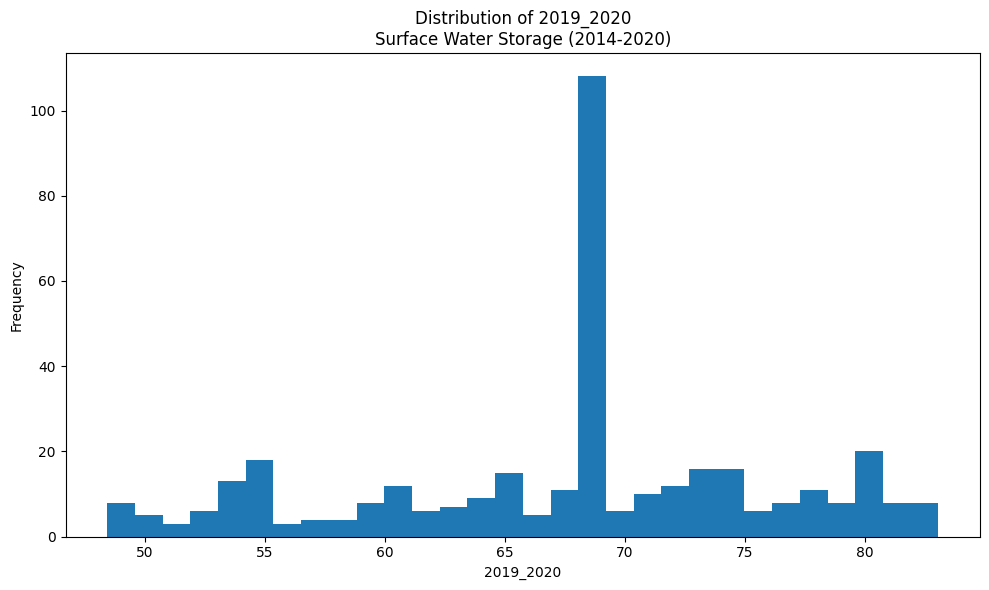

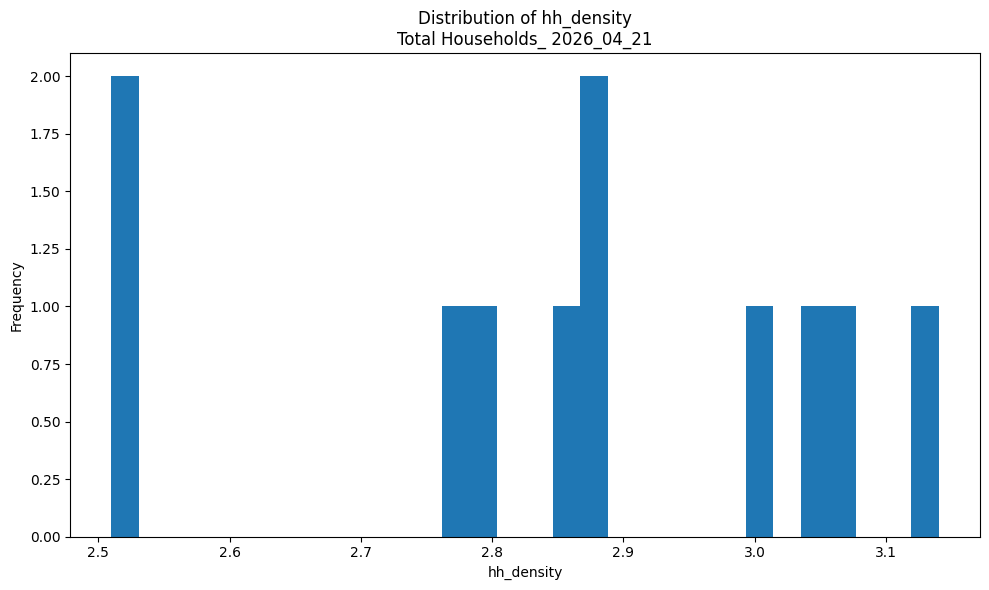

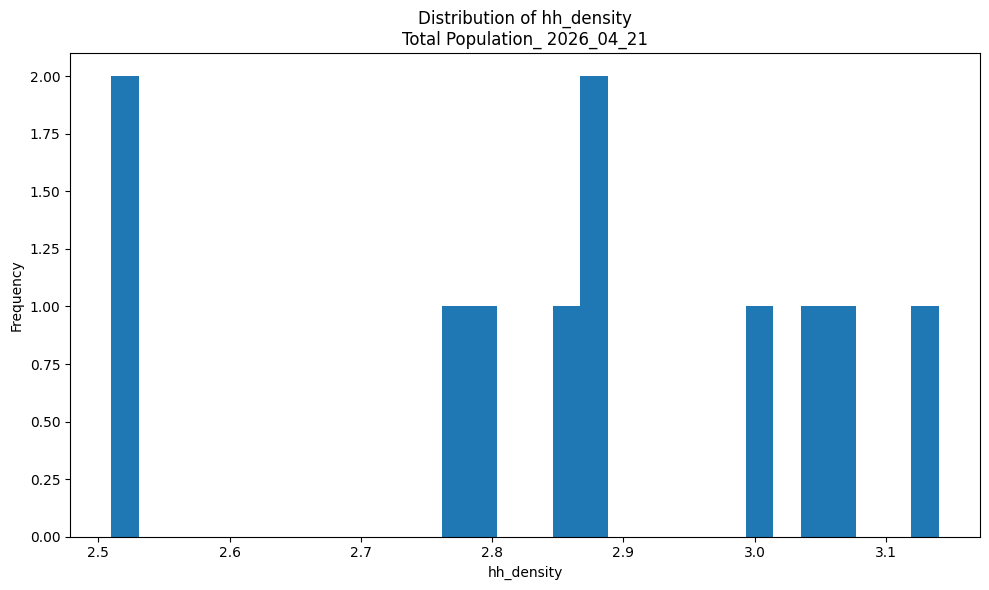

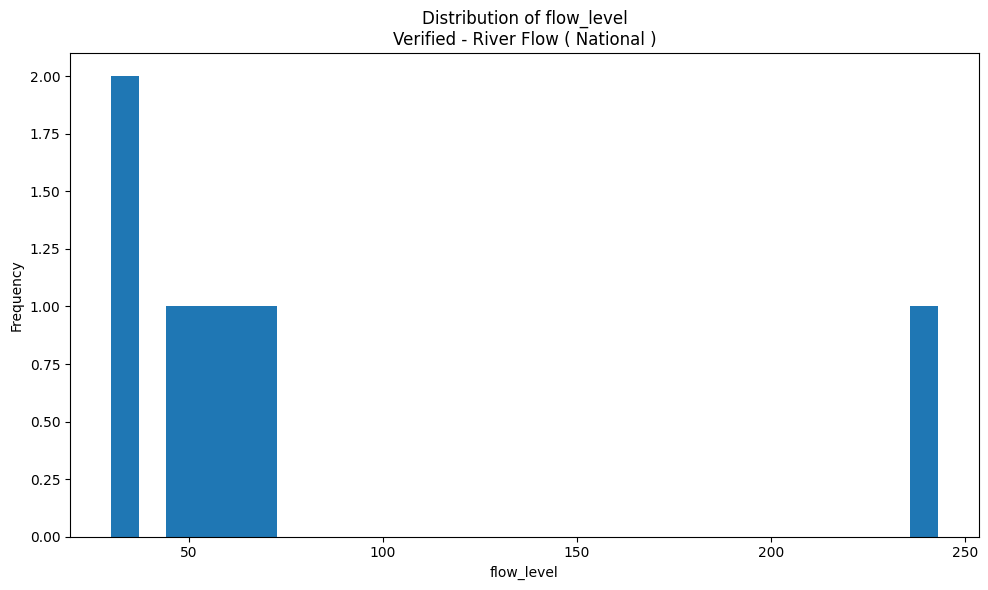

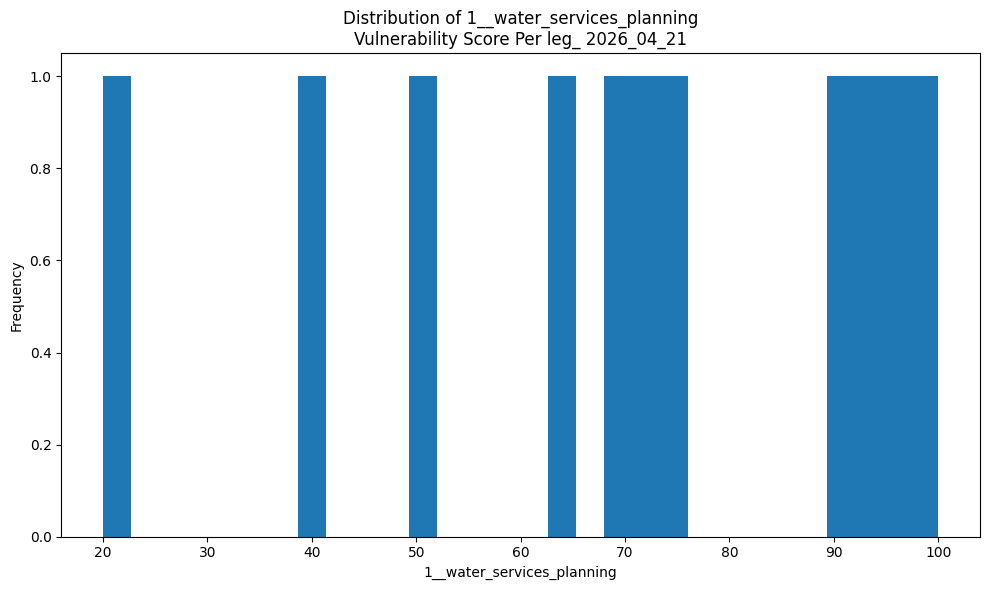

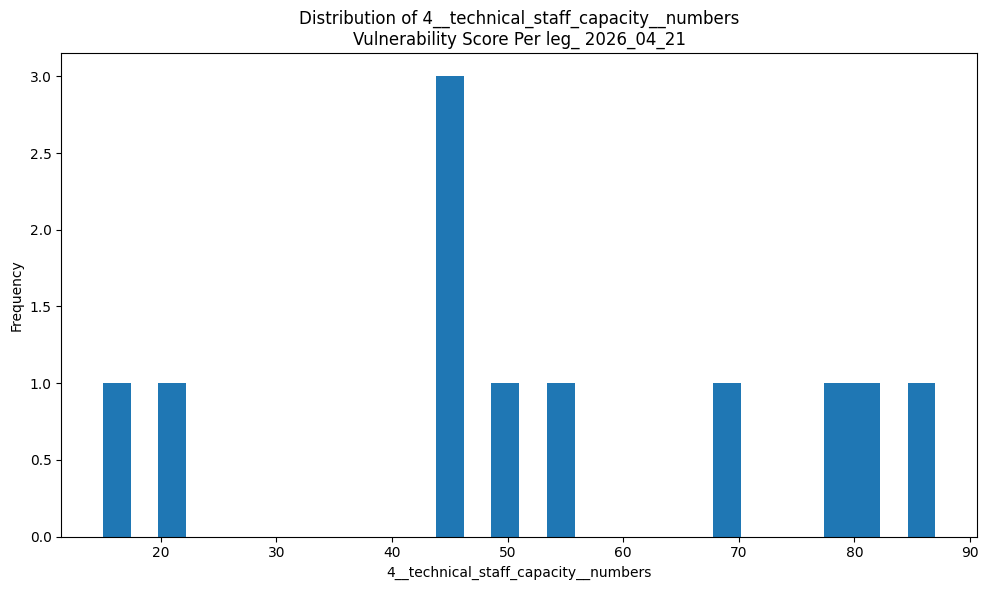

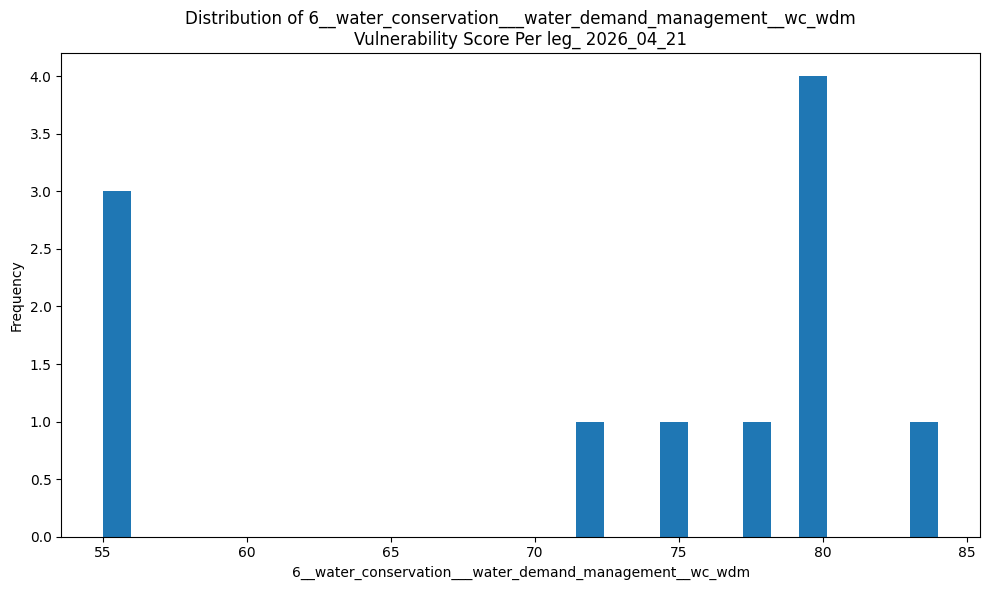

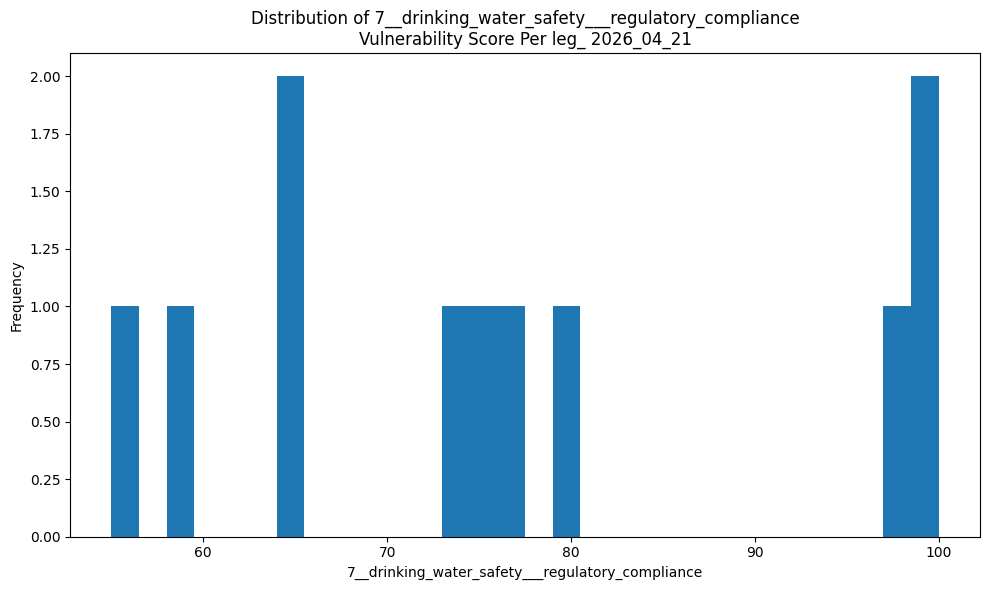

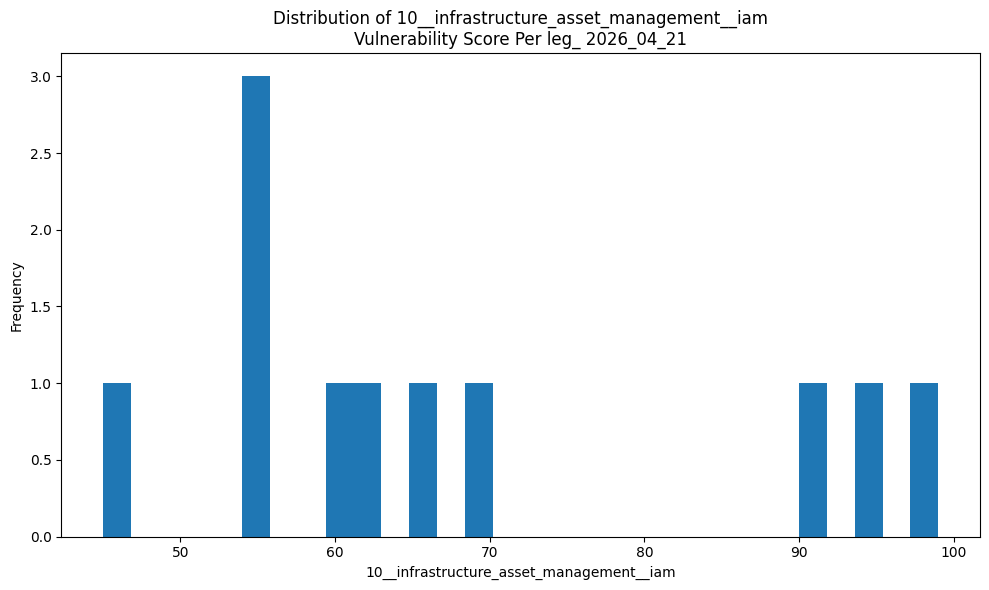

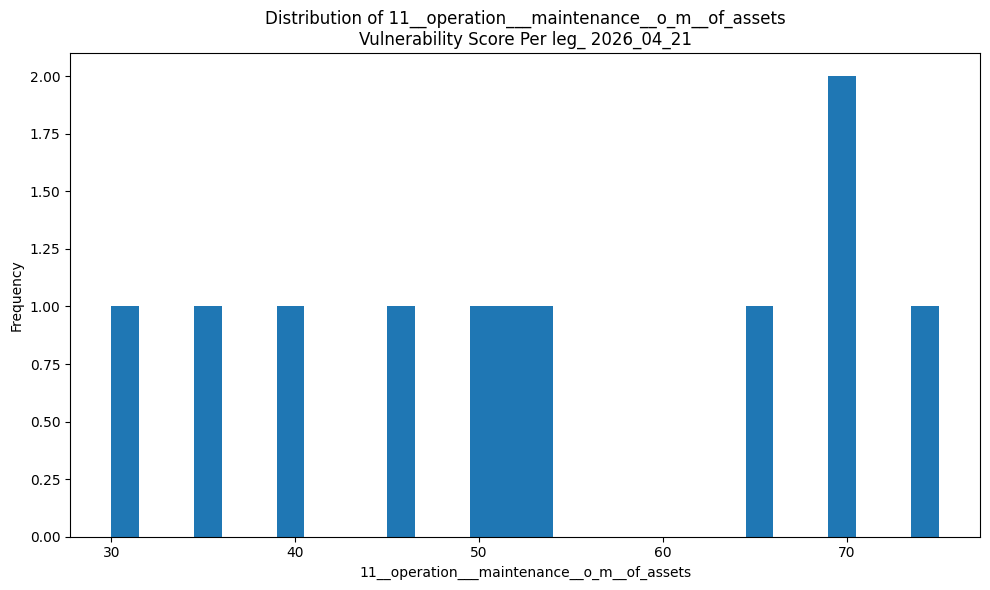

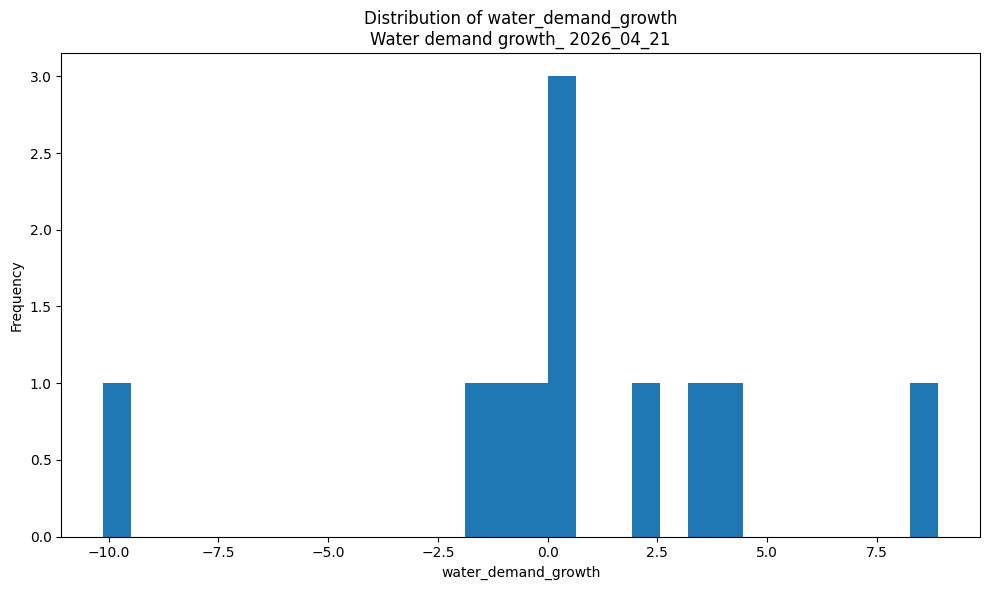

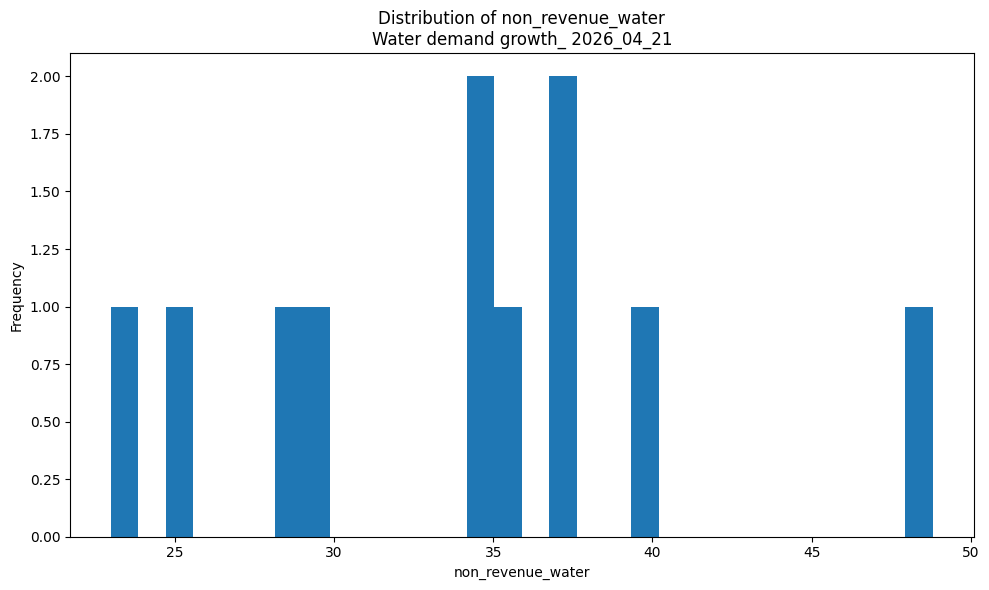

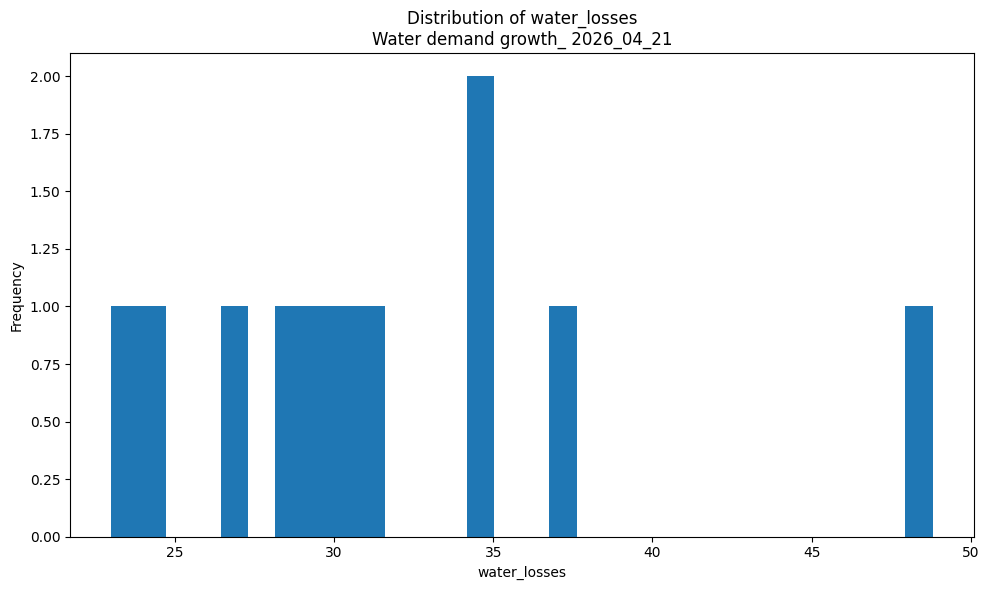

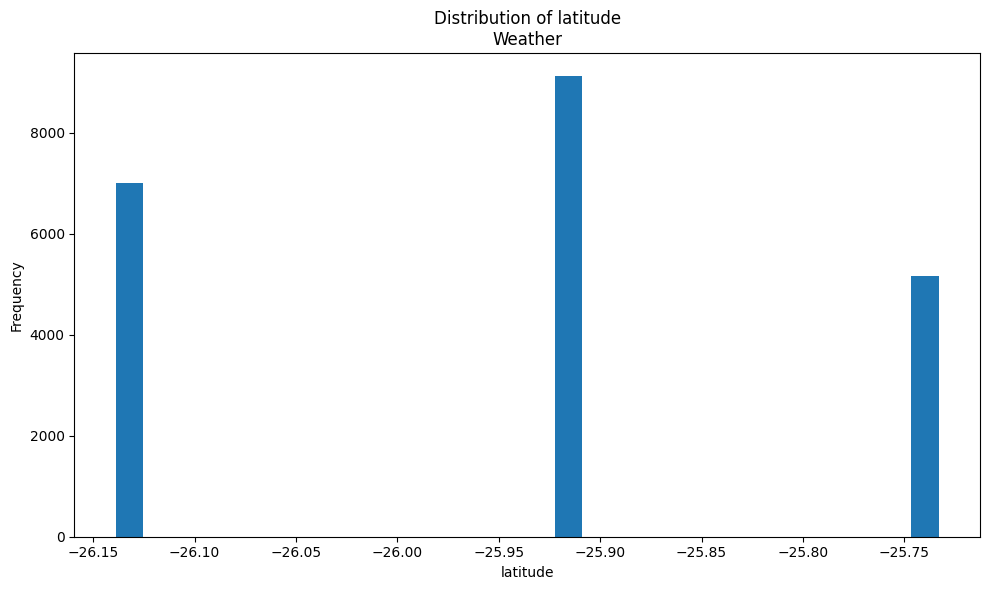

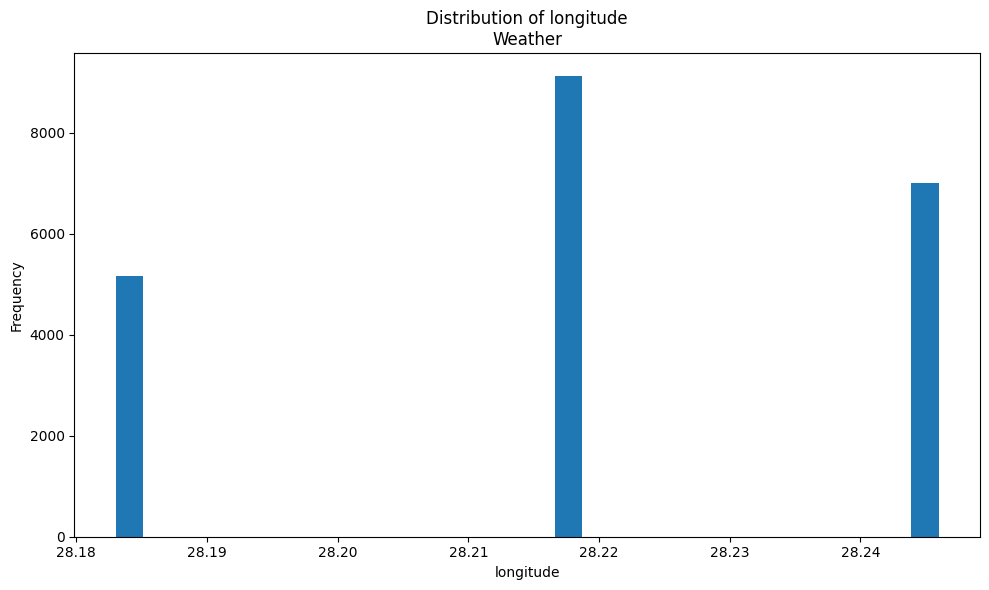

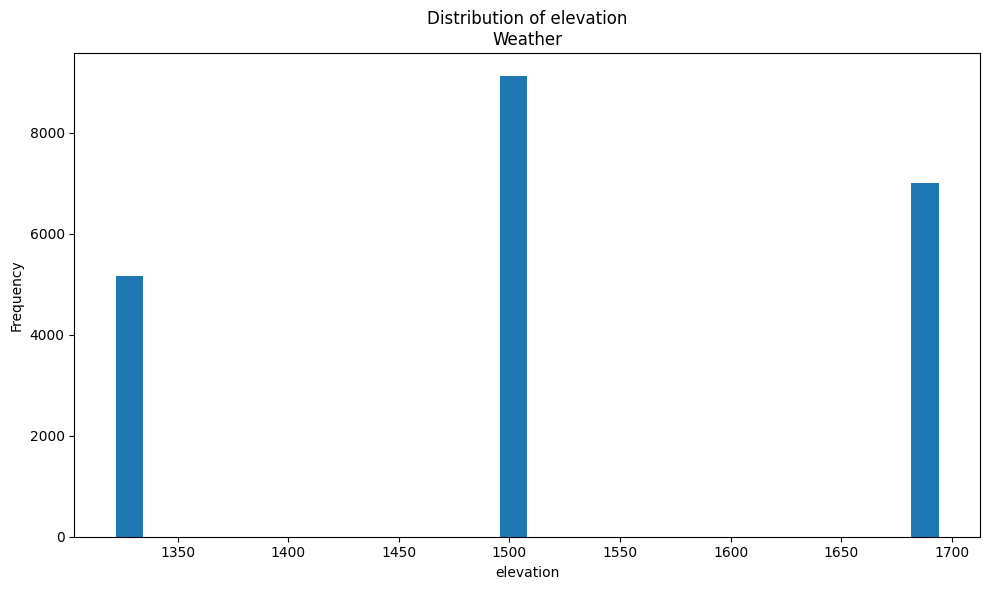

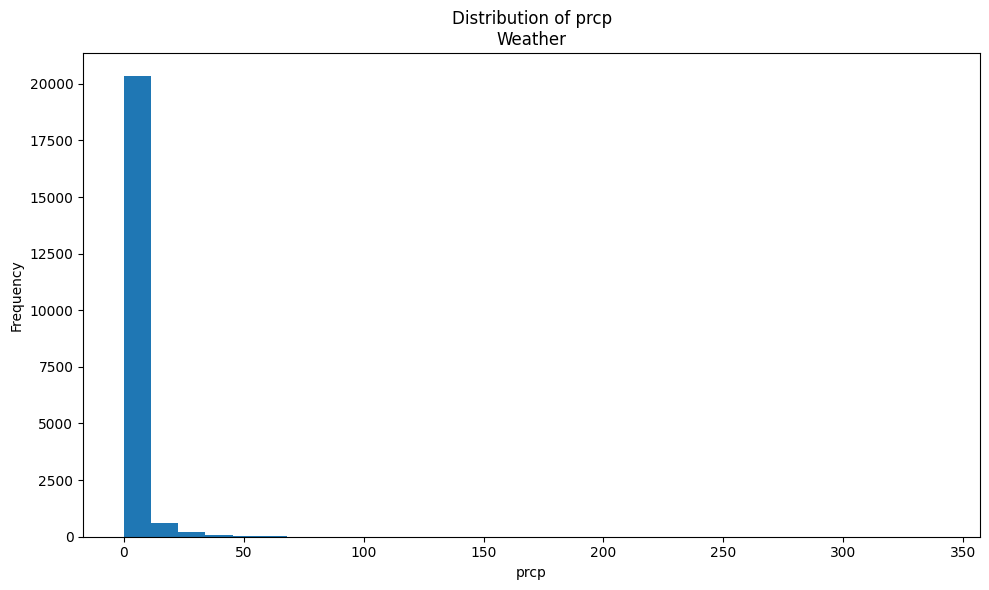

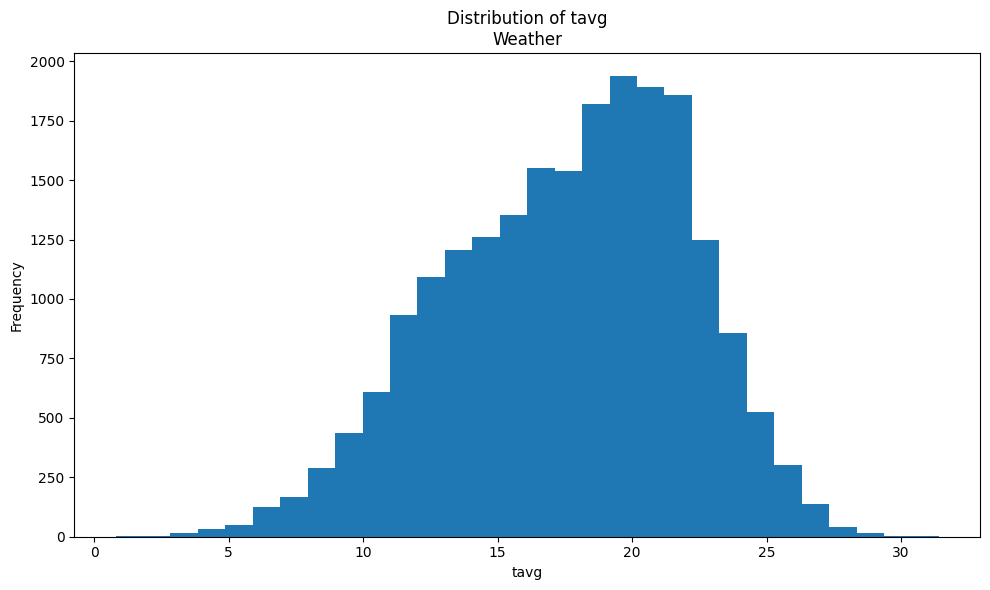

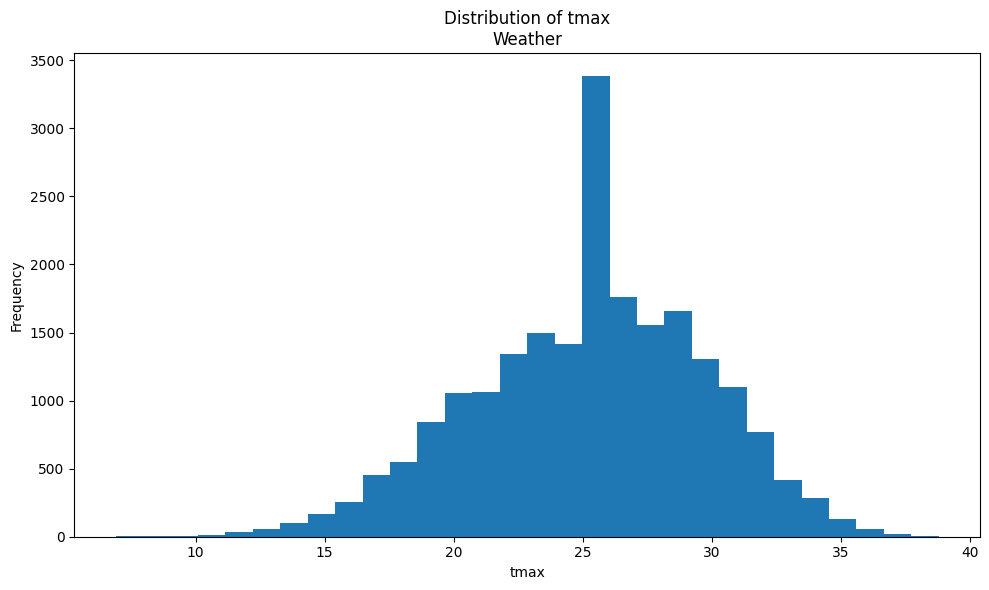

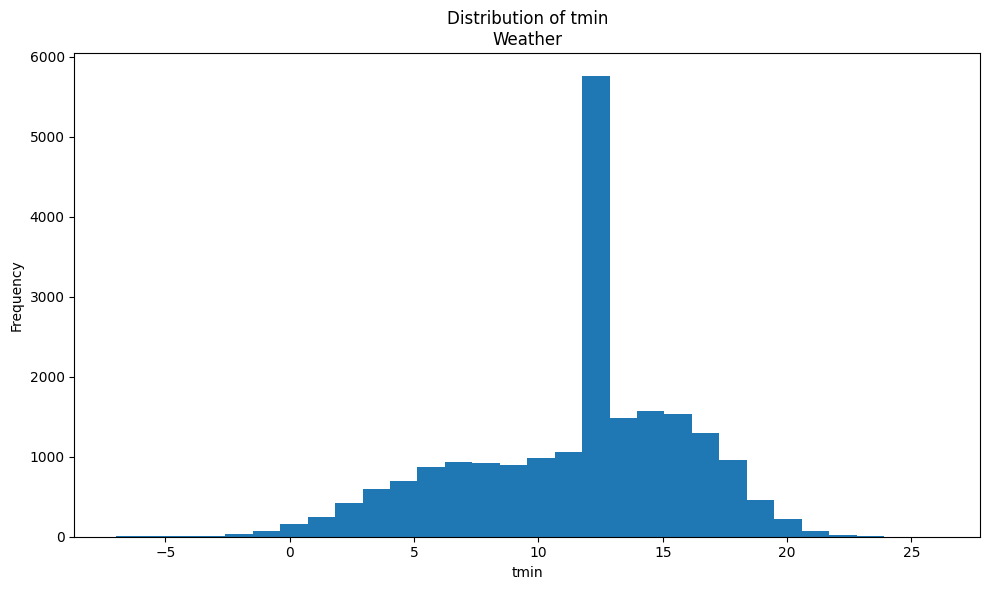

Distribution visualisations generated and saved.


In [11]:
# ============================================================
# NUMERICAL DISTRIBUTIONS
# ============================================================

for name, df in cleaned_datasets.items():

    numeric_columns = list(
        df.select_dtypes(include=np.number).columns
    )

    for column in numeric_columns:

        series = pd.to_numeric(
            df[column],
            errors="coerce"
        ).dropna()

        if series.empty:
            continue

        plt.figure(figsize=(10, 6))

        plt.hist(
            series,
            bins=30
        )

        plt.title(
            f"Distribution of {column}\n{name}"
        )
        plt.xlabel(column)
        plt.ylabel("Frequency")

        plt.tight_layout()

        safe_name = re.sub(
            r"[^A-Za-z0-9_.-]",
            "_",
            str(name)
        )

        safe_column = re.sub(
            r"[^A-Za-z0-9_.-]",
            "_",
            str(column)
        )

        output_path = os.path.join(
            EDA_VISUALISATION_DIR,
            f"{safe_name}_{safe_column}_distribution.png"
        )

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

print("Distribution visualisations generated and saved.")


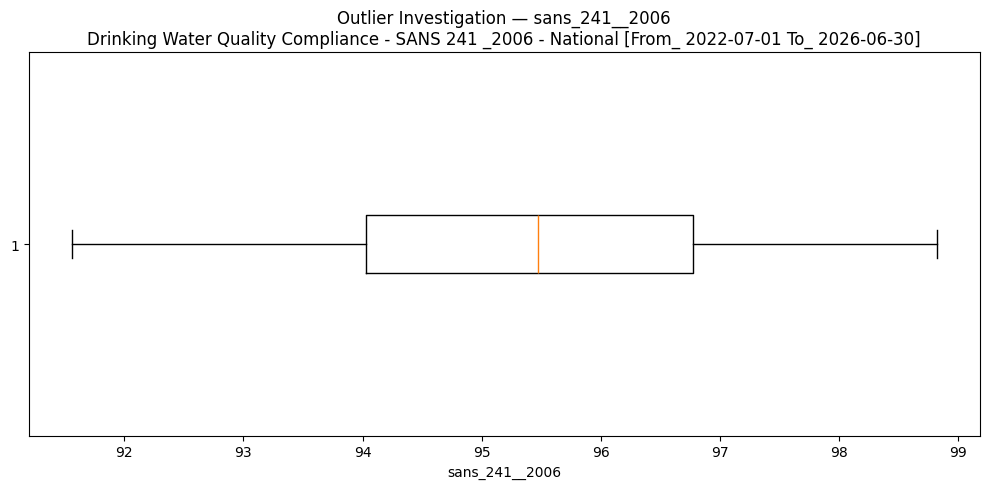

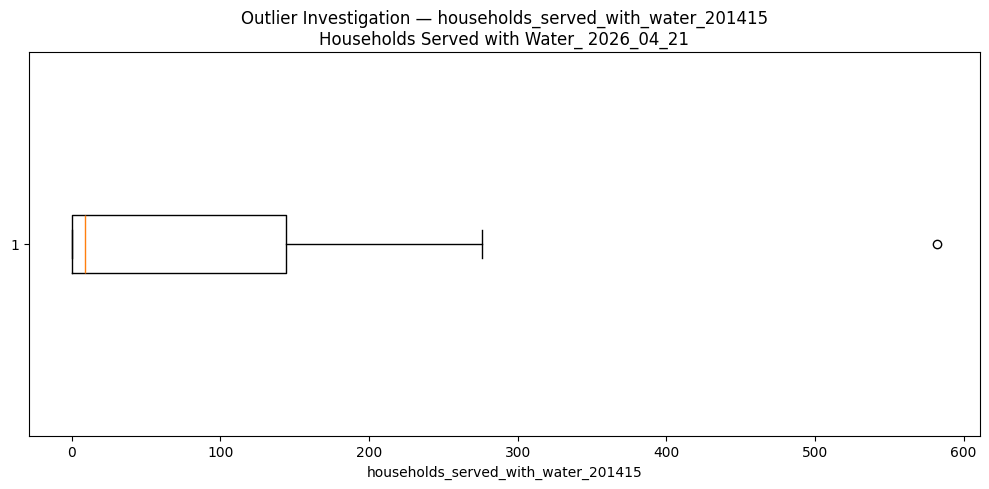

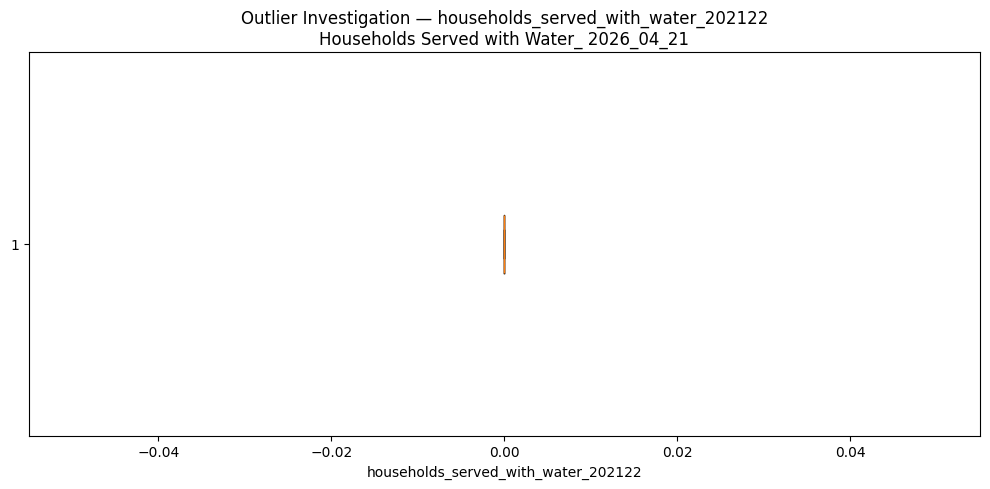

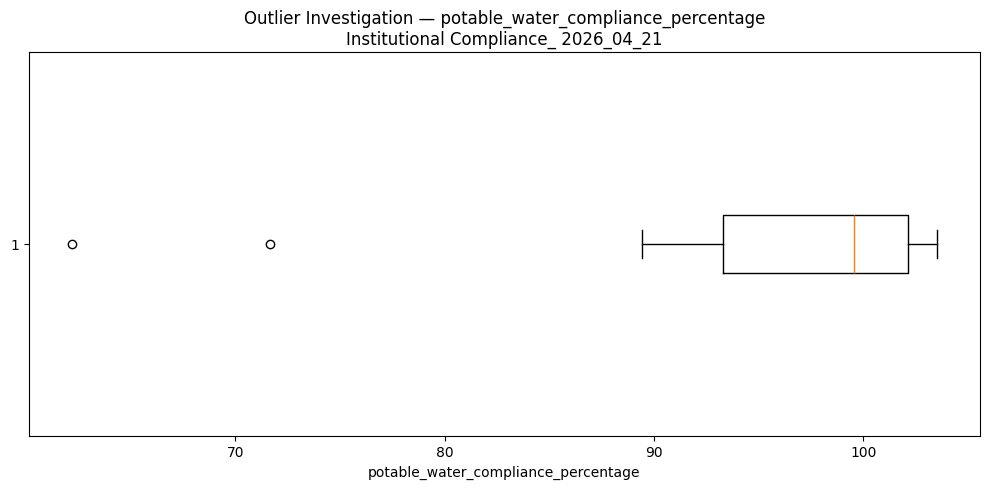

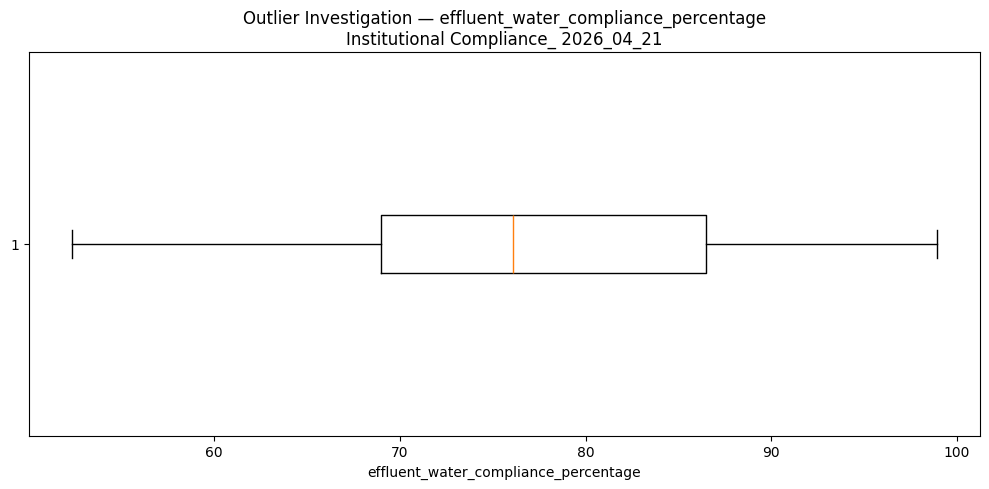

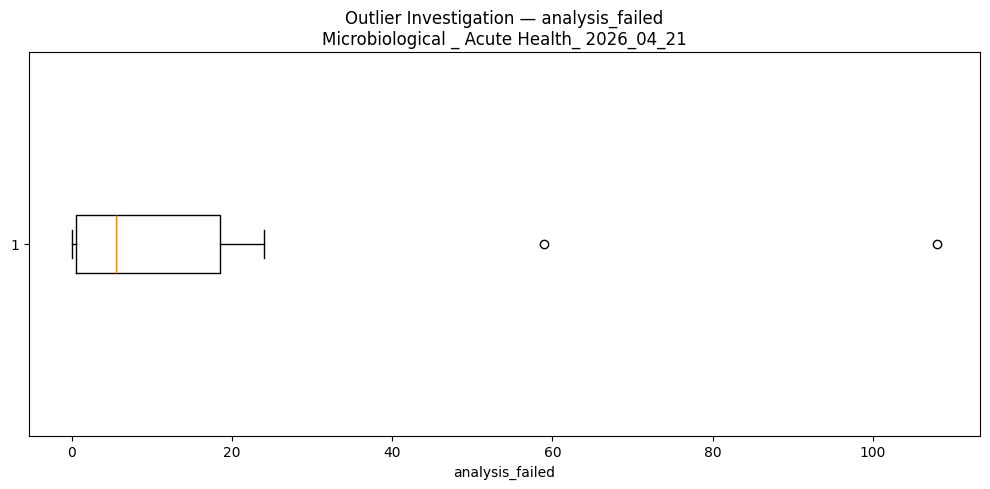

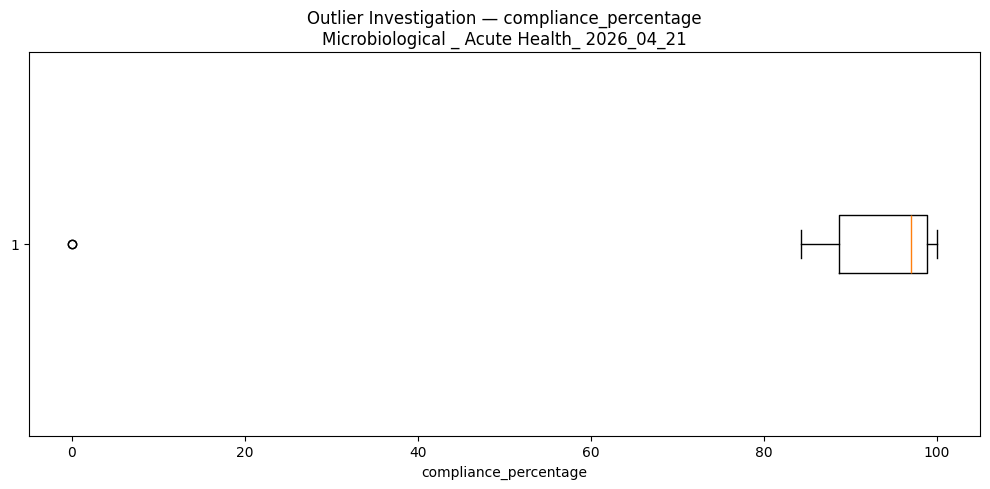

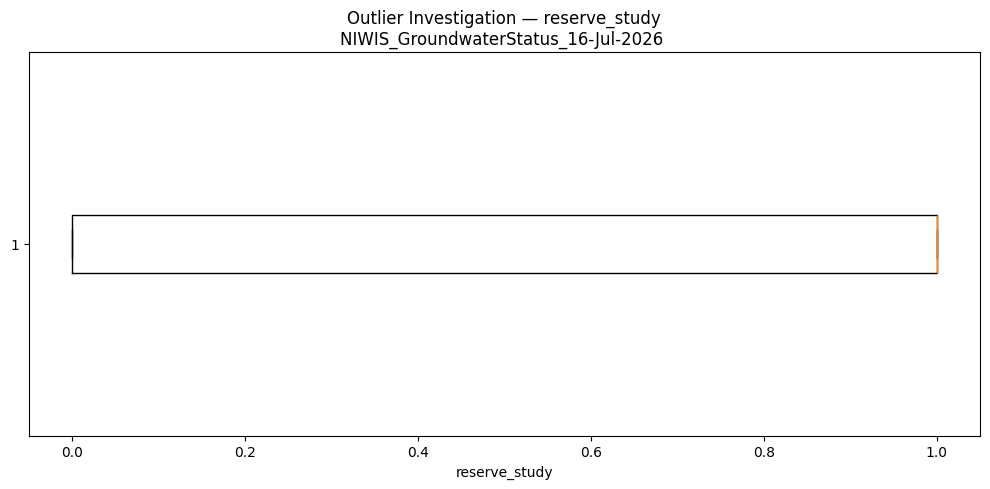

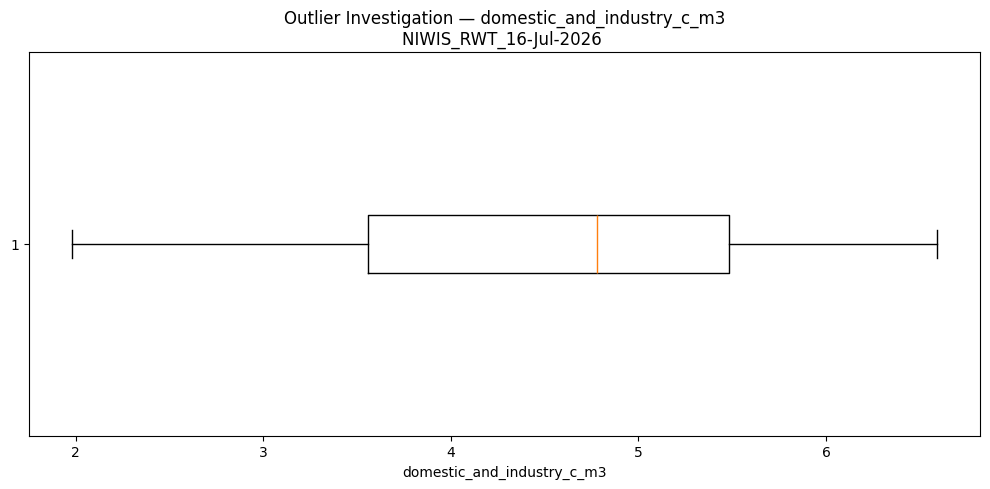

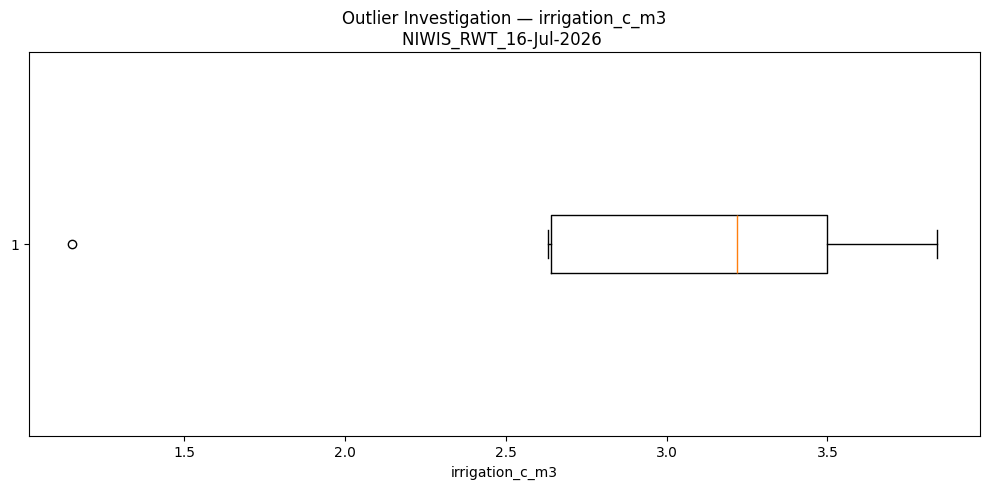

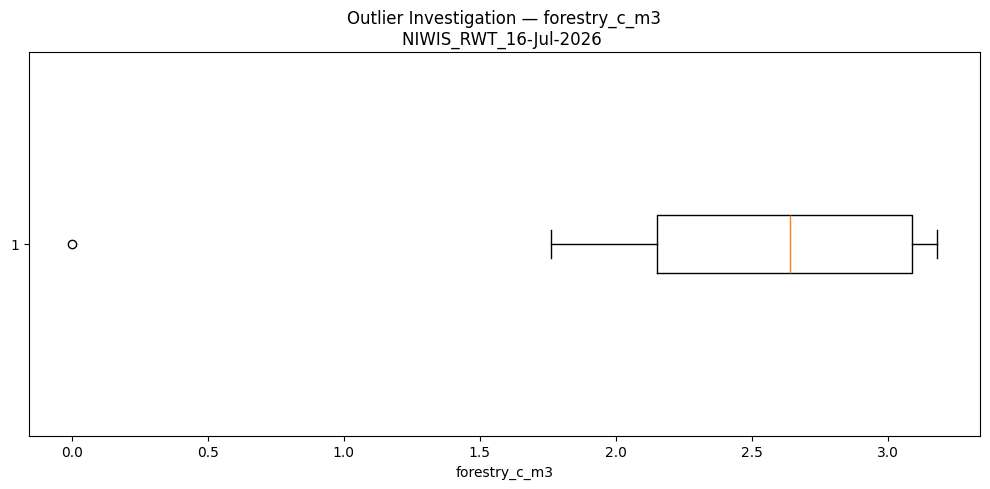

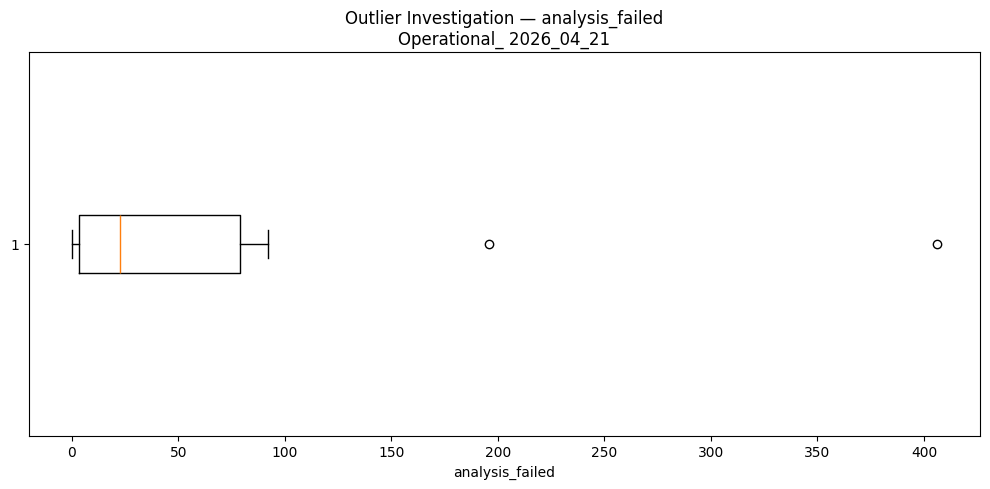

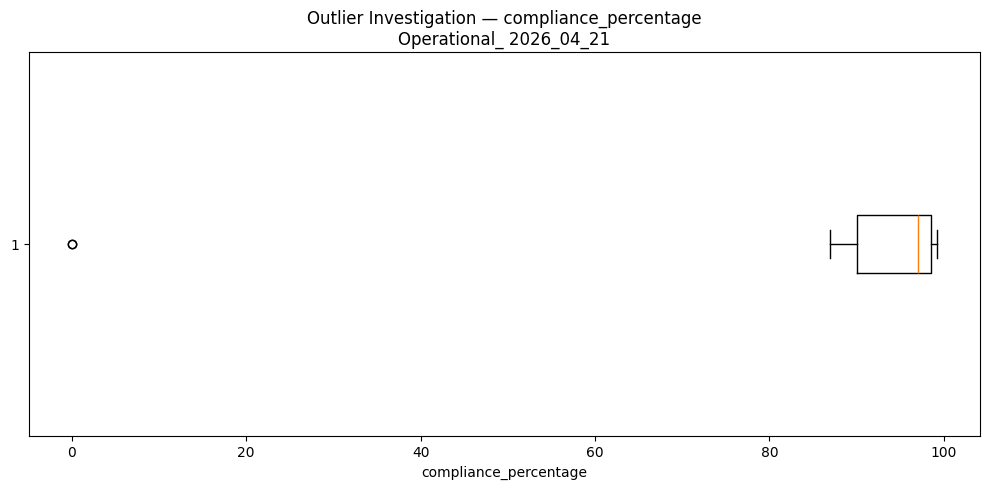

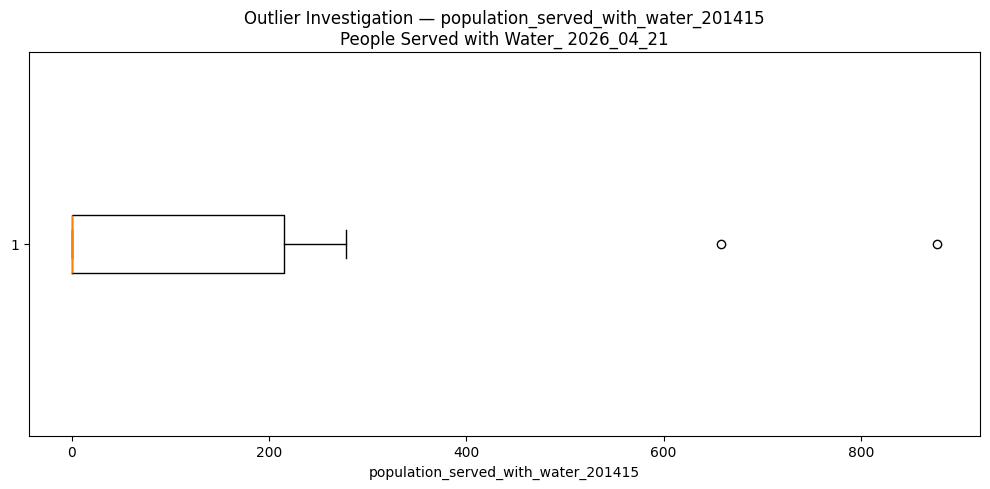

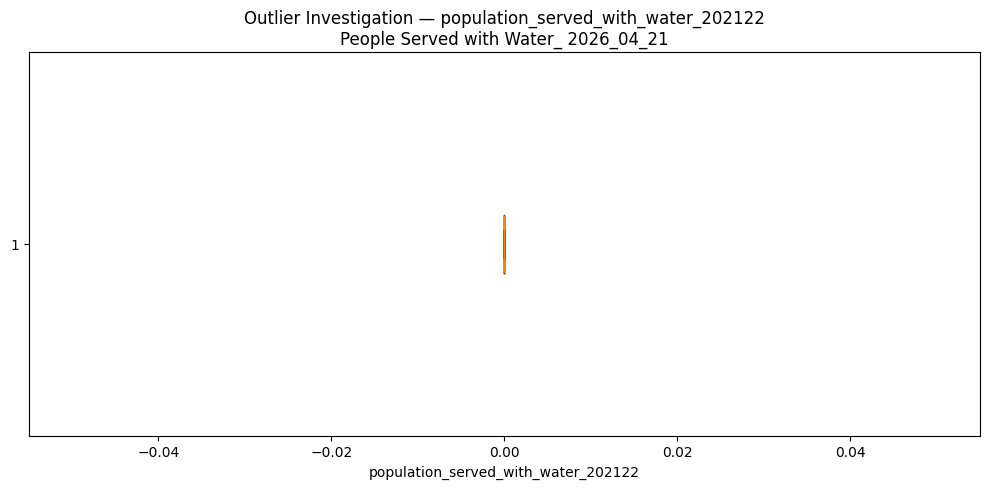

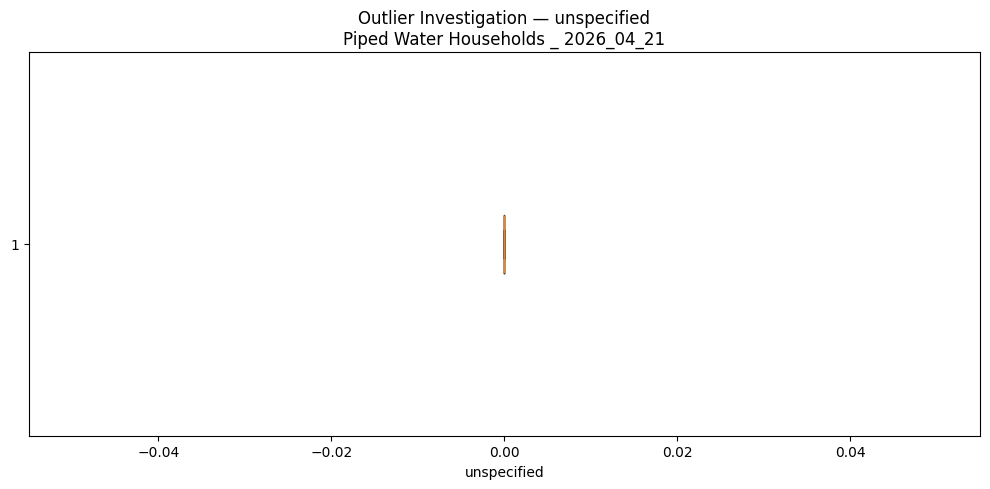

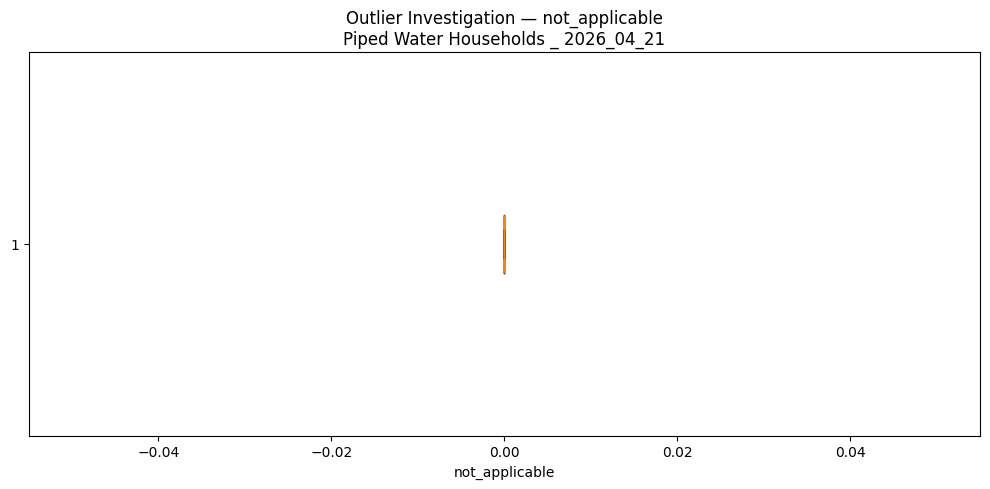

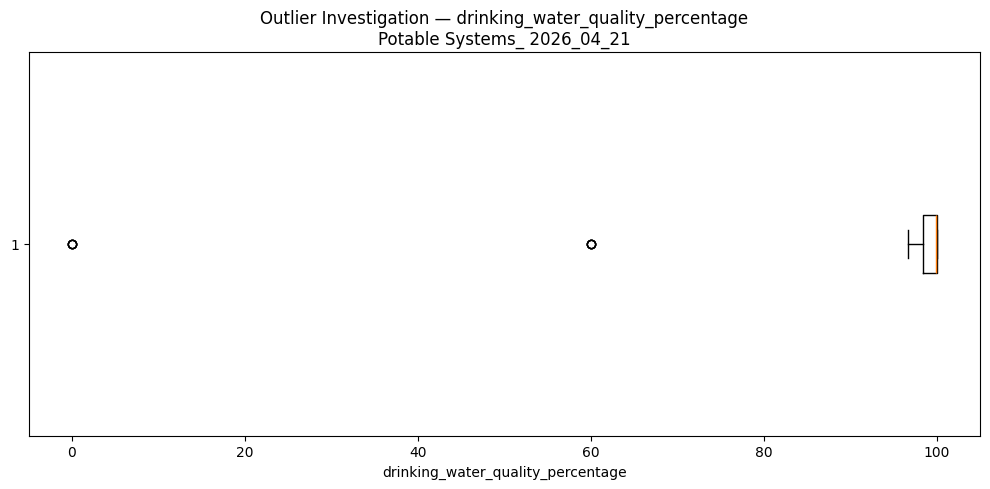

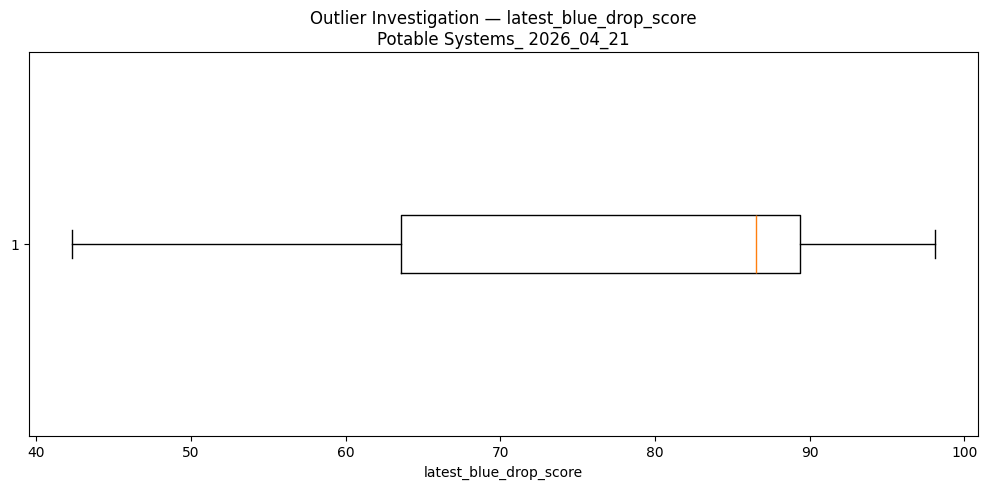

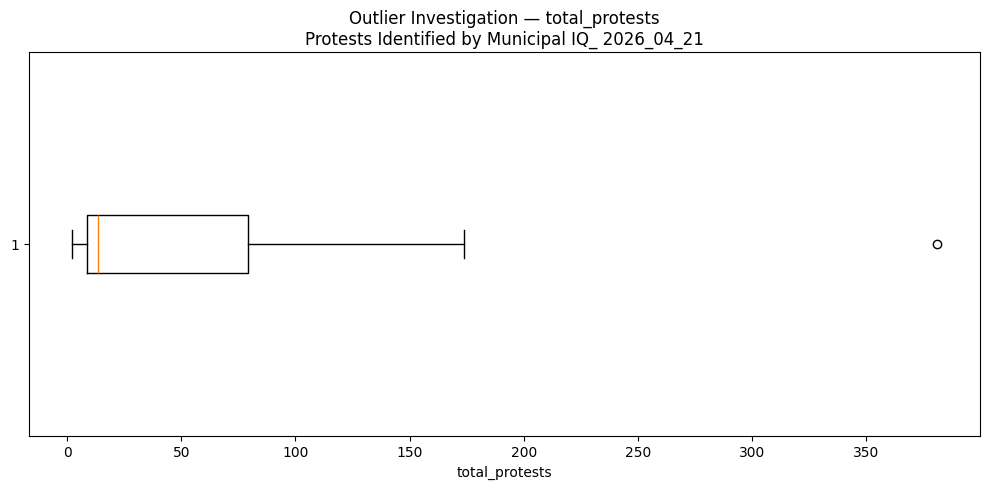

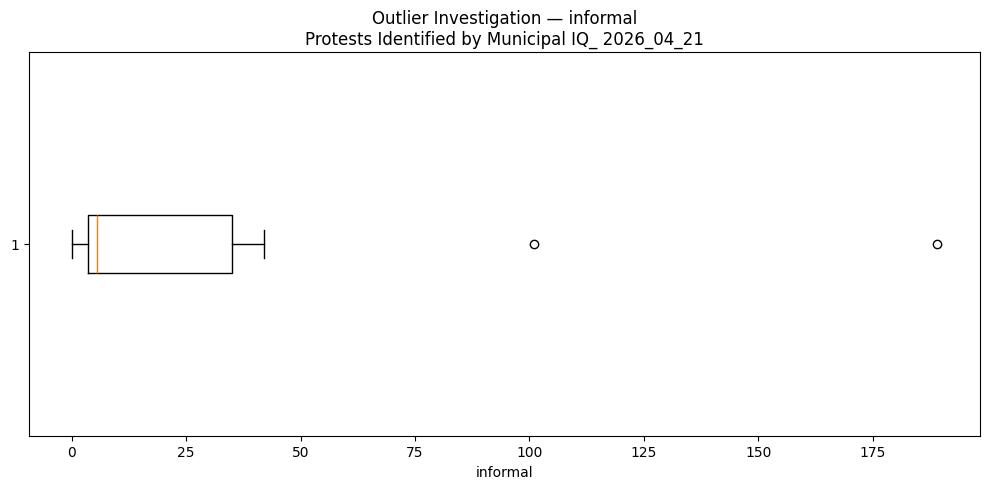

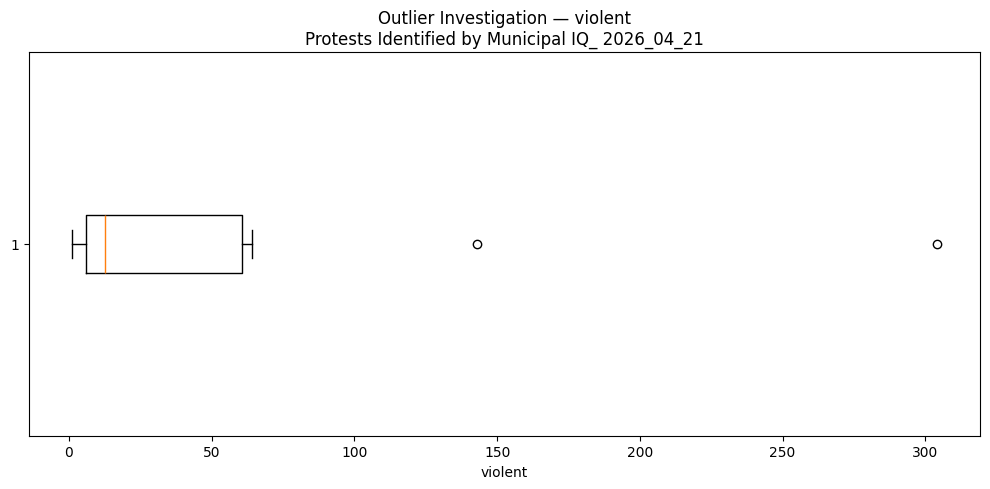

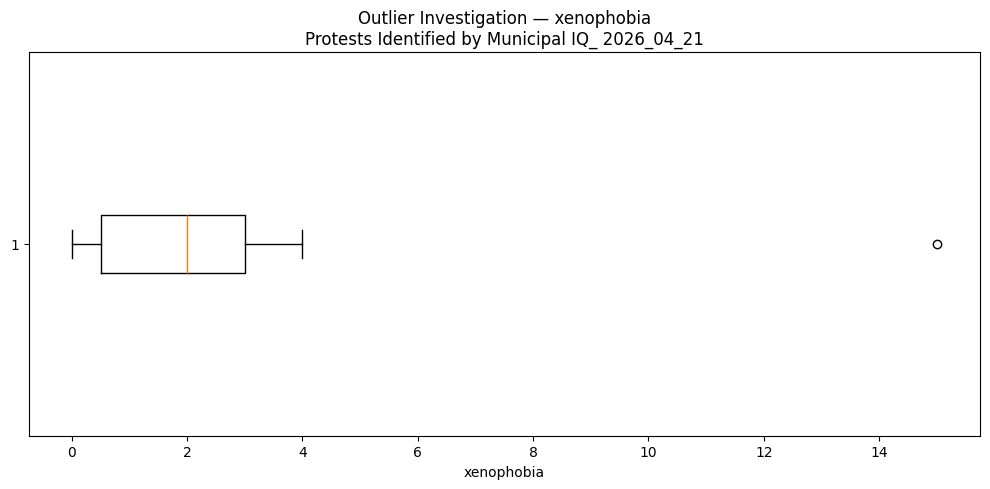

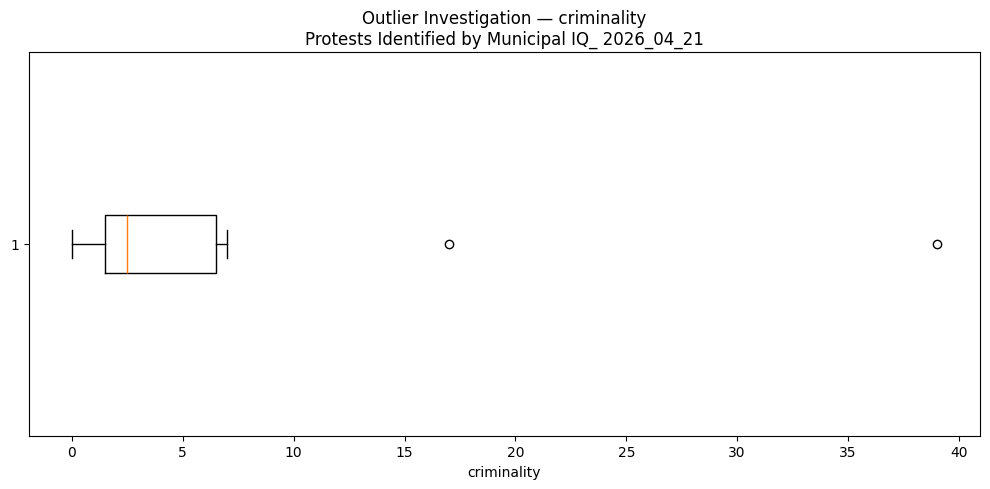

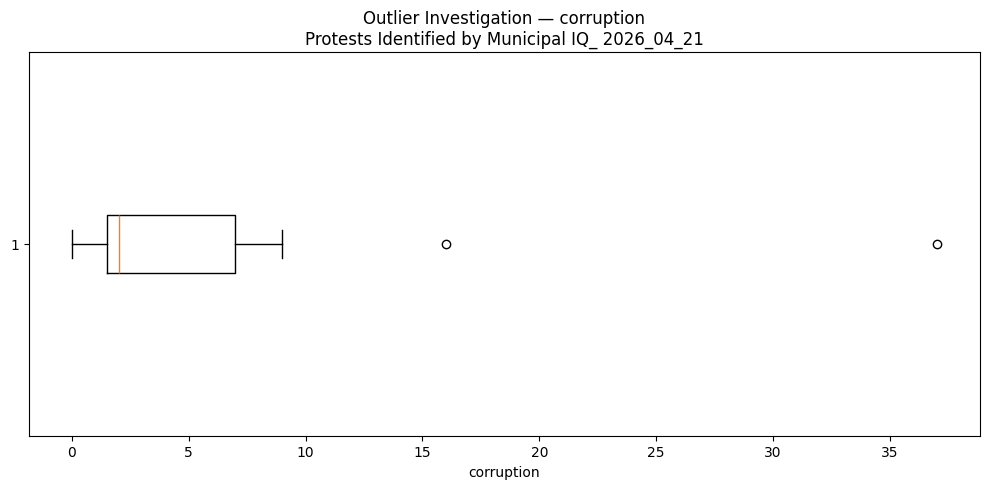

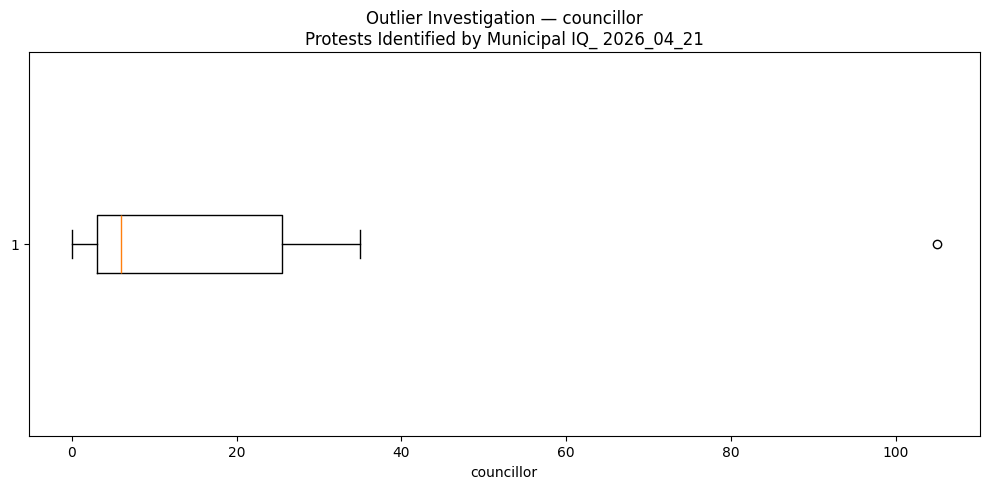

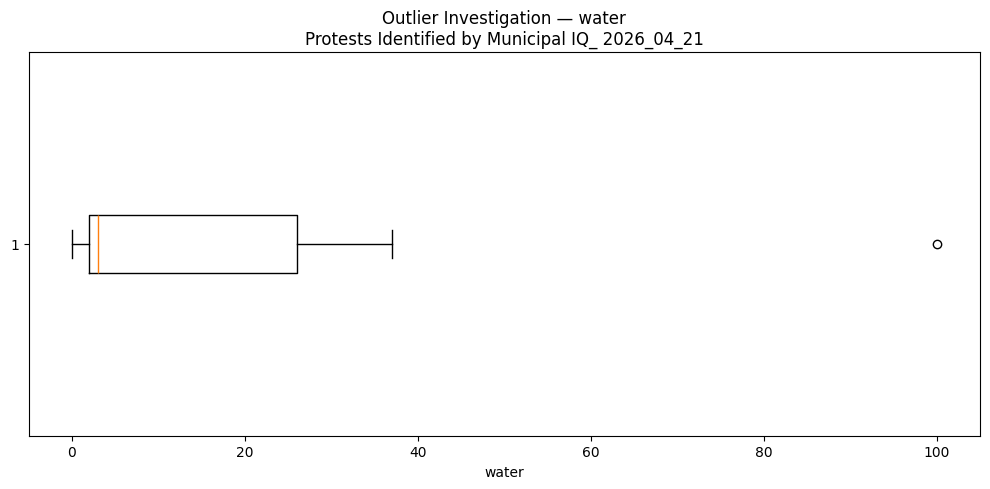

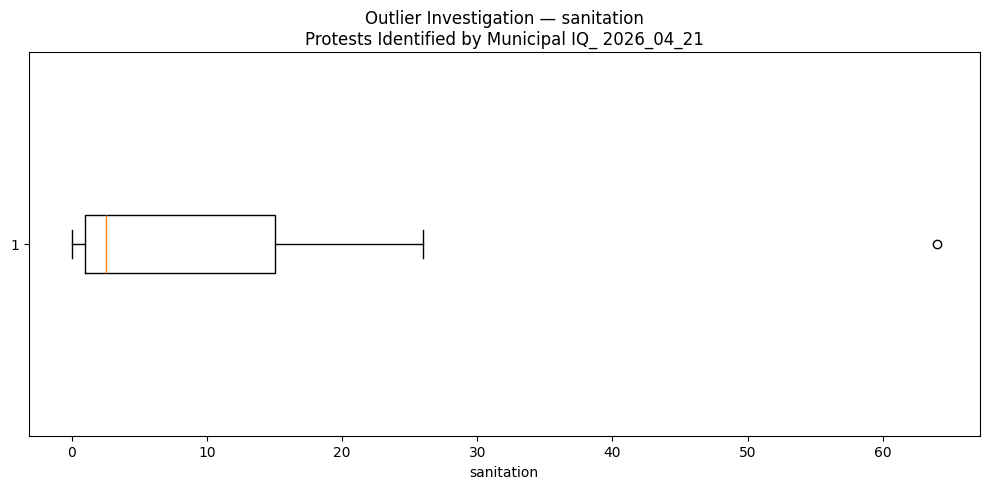

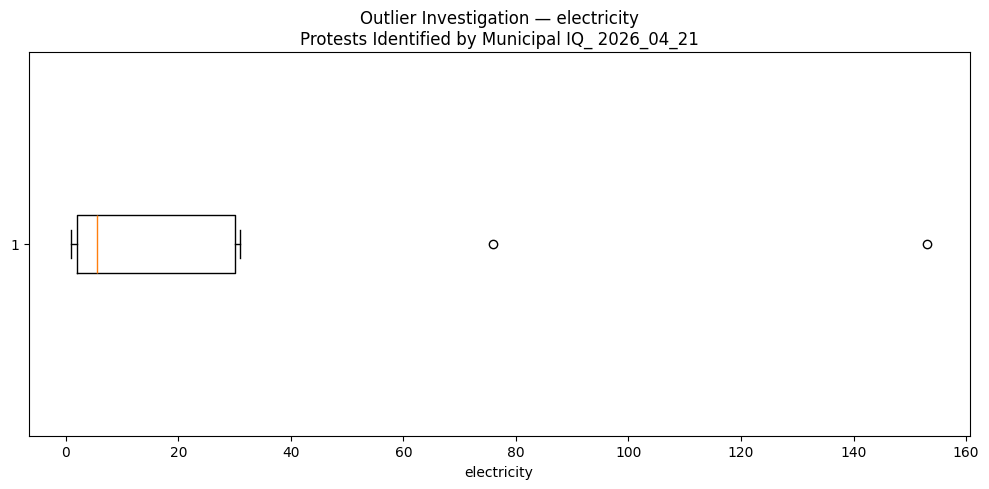

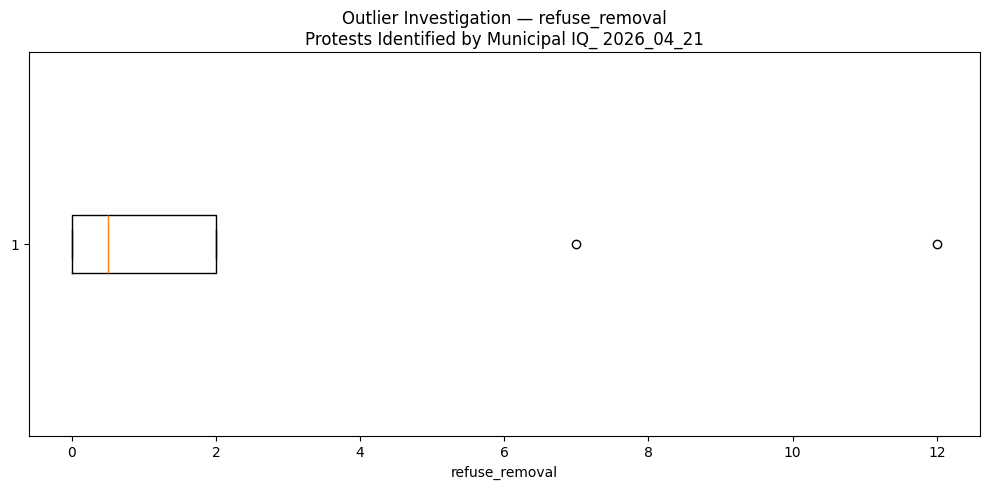

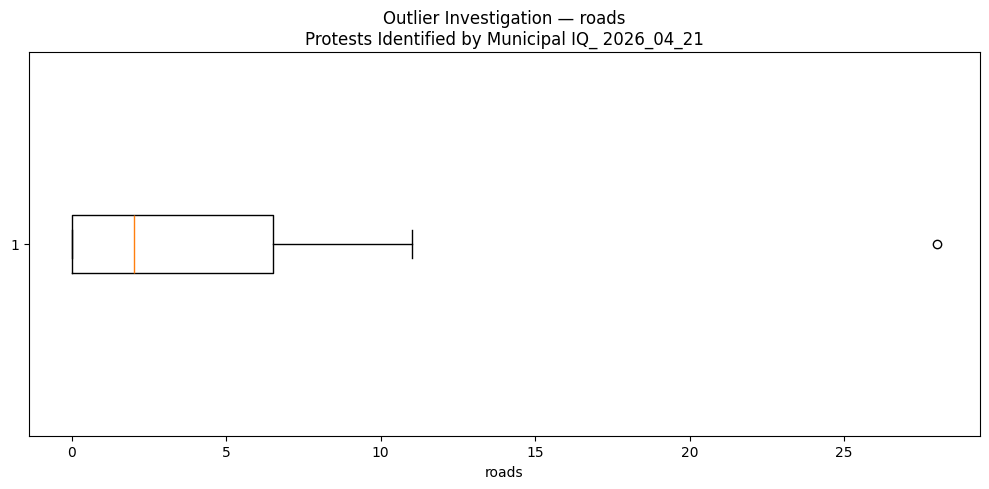

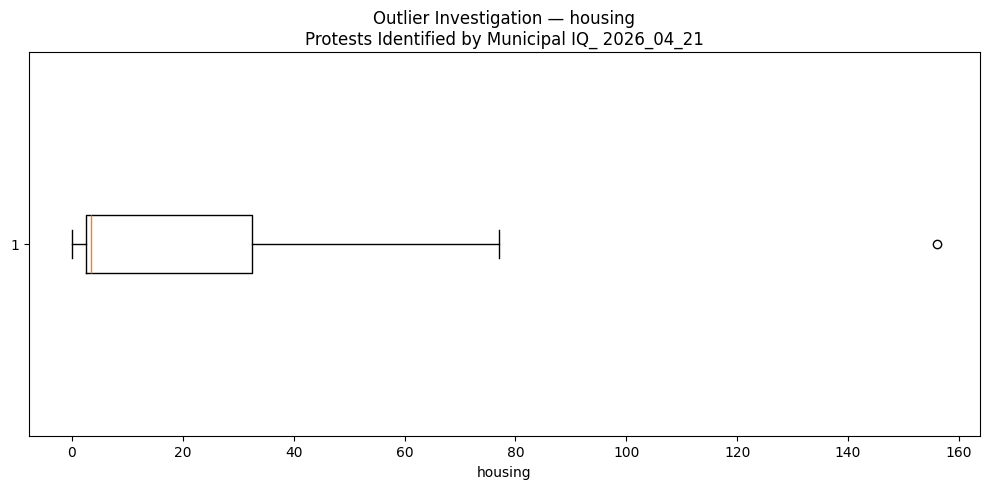

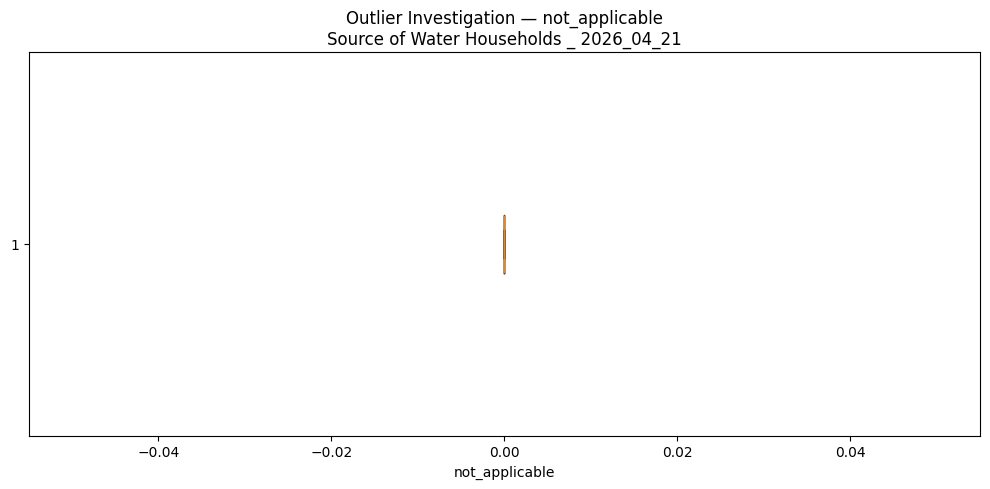

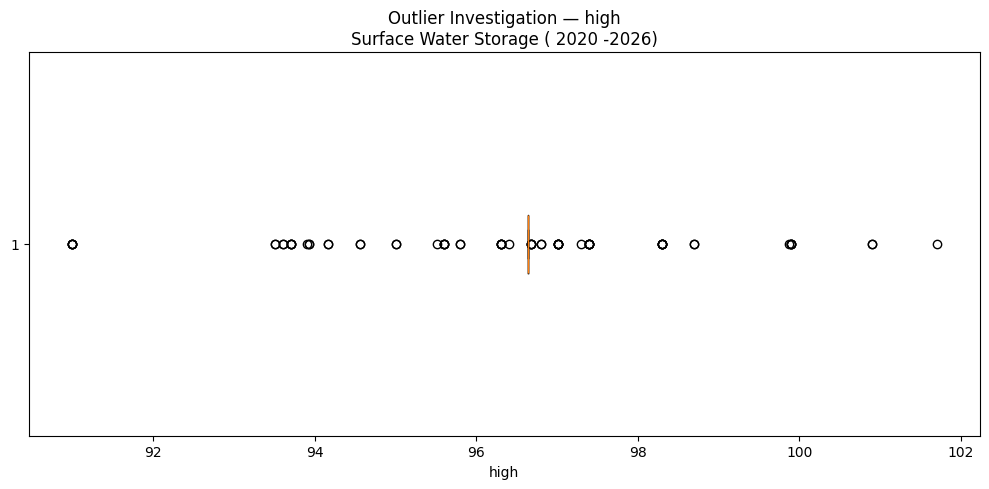

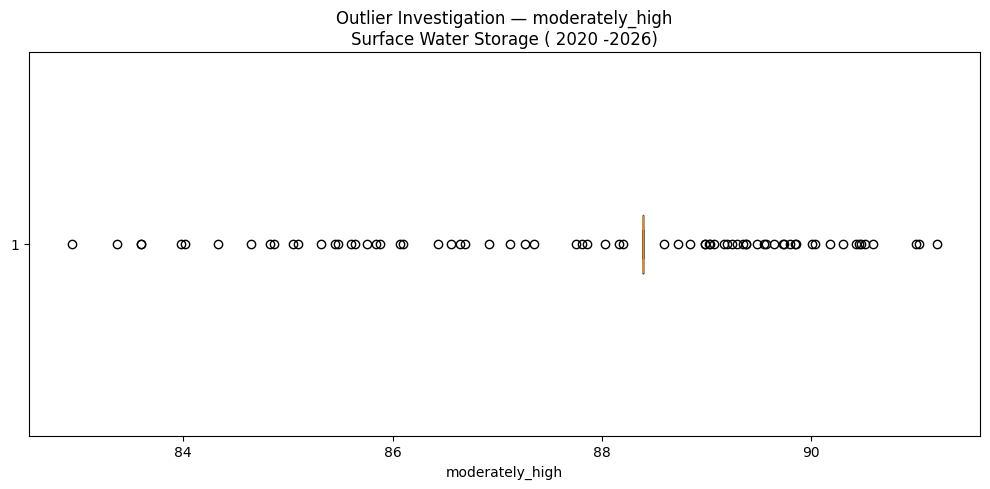

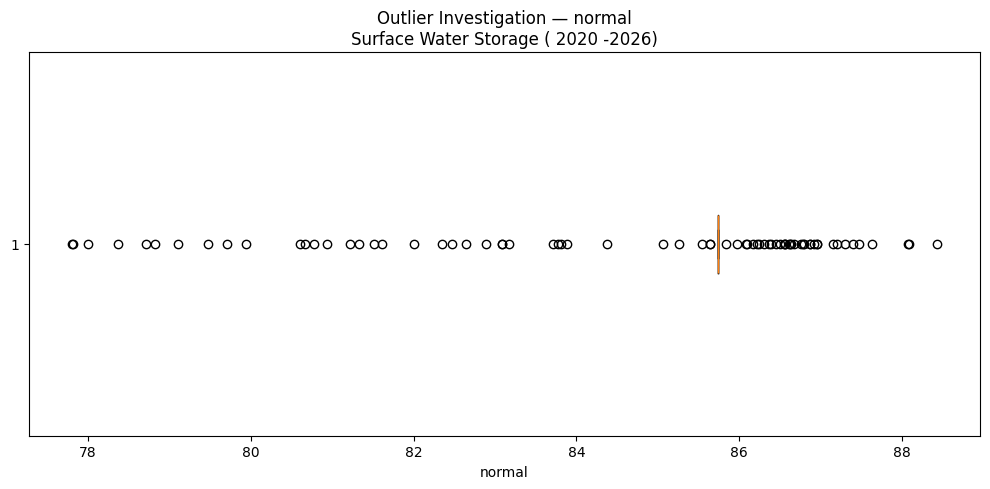

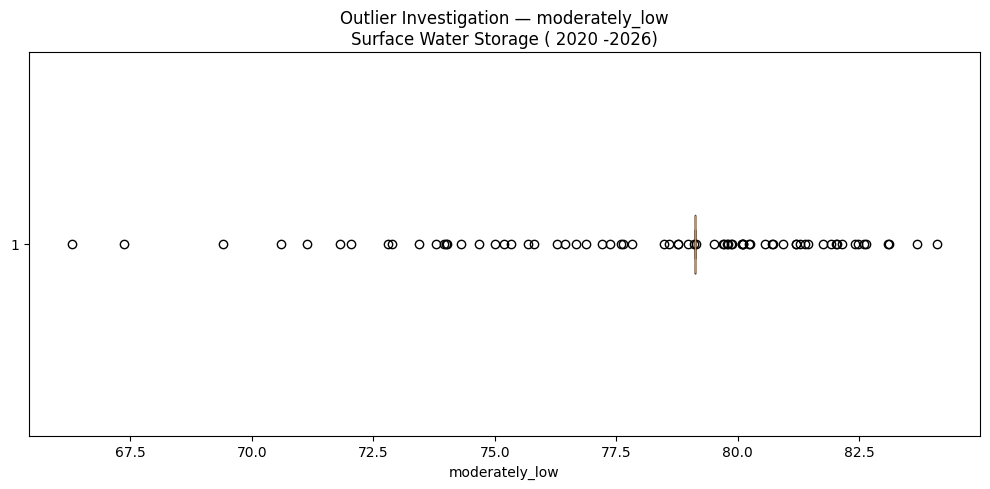

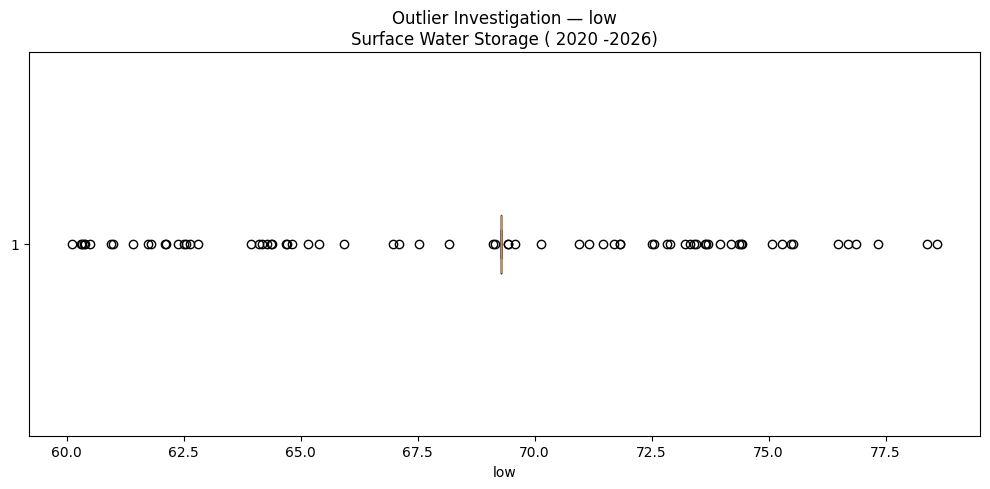

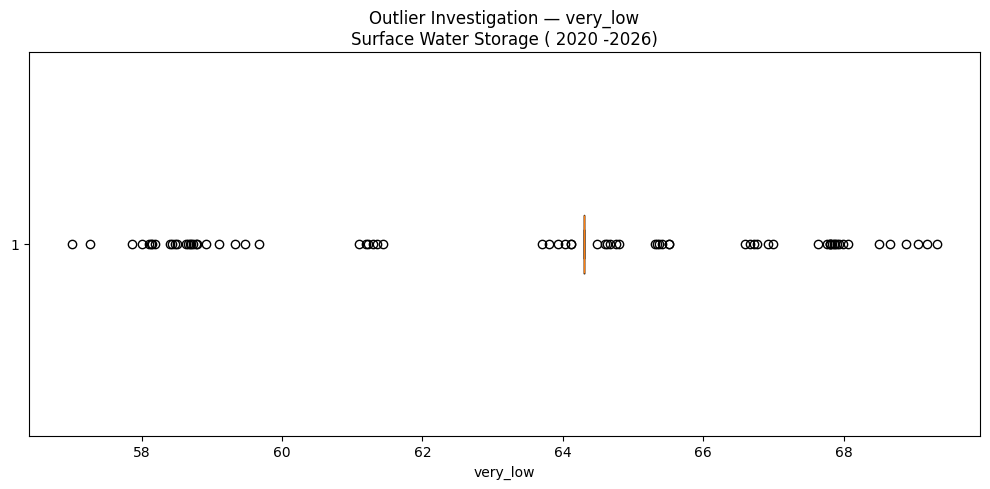

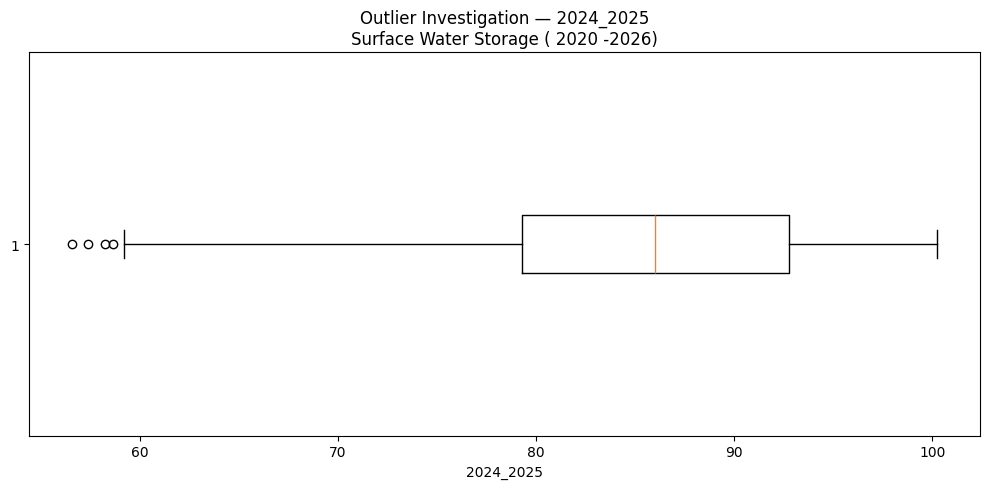

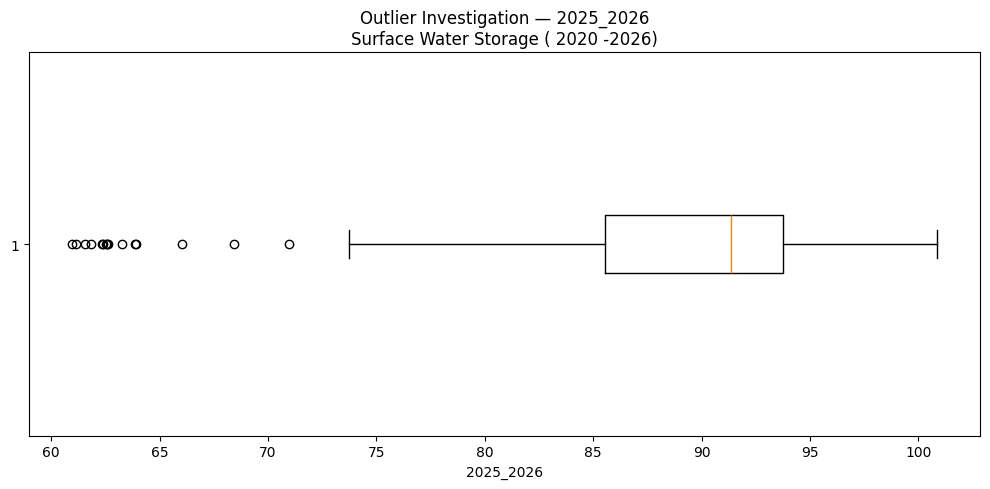

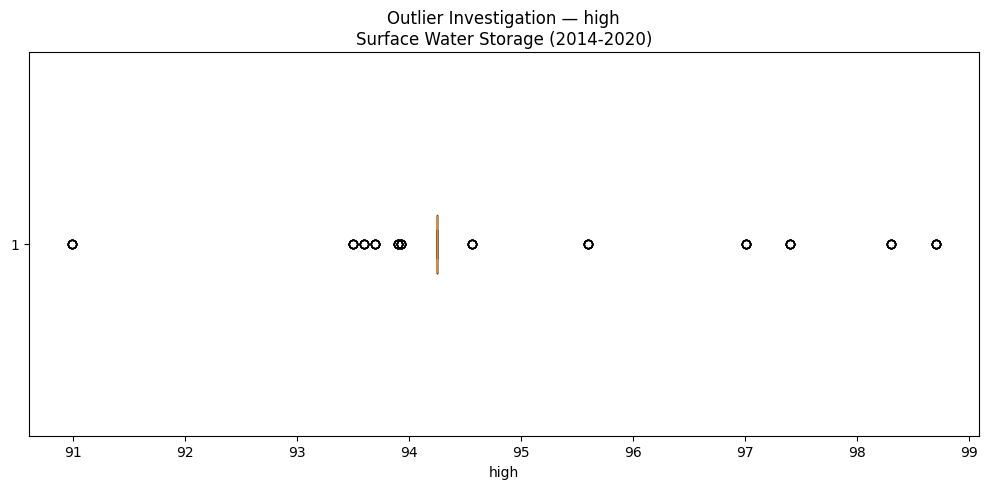

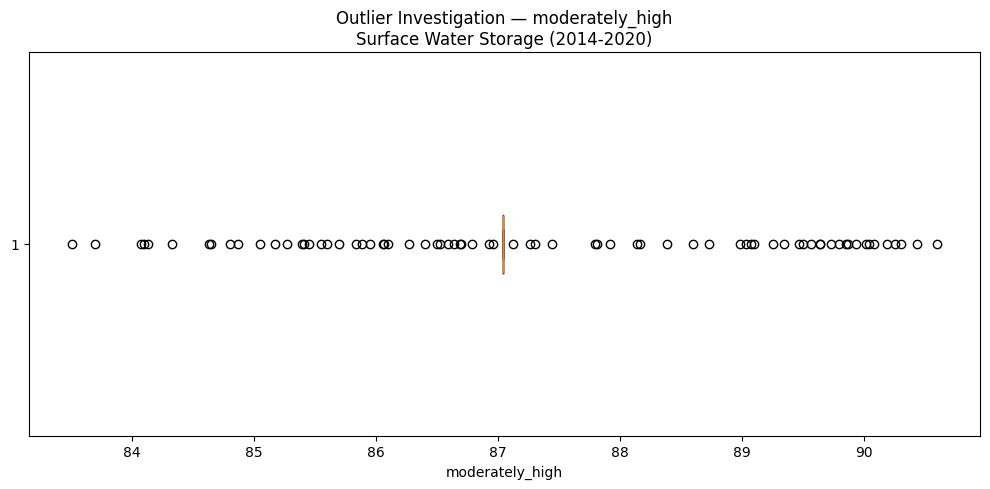

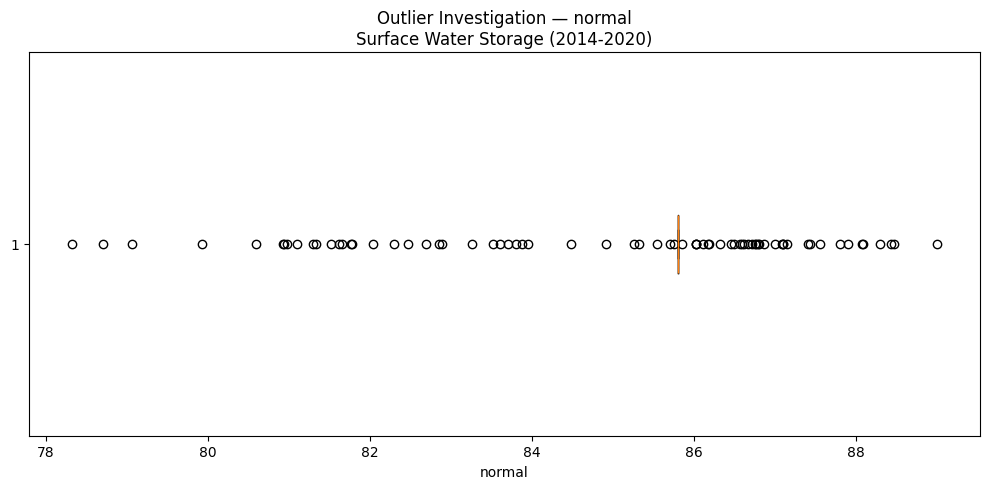

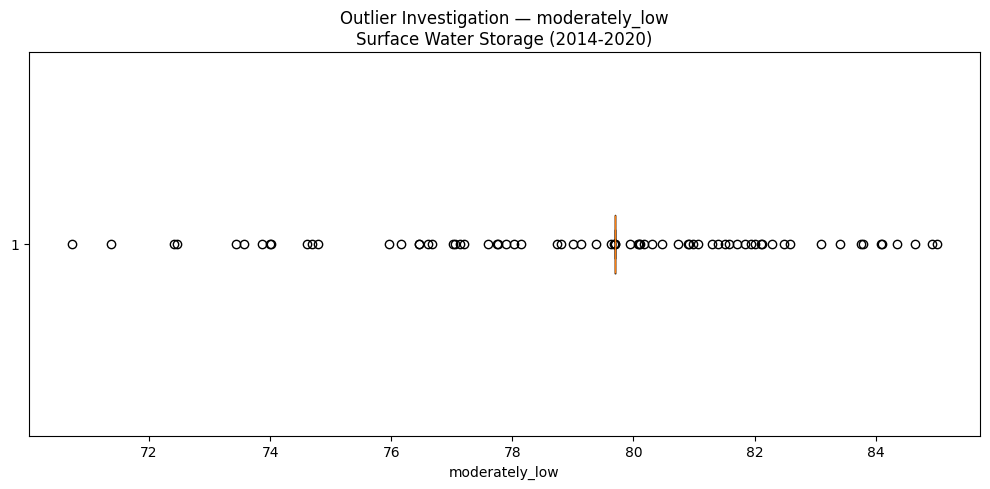

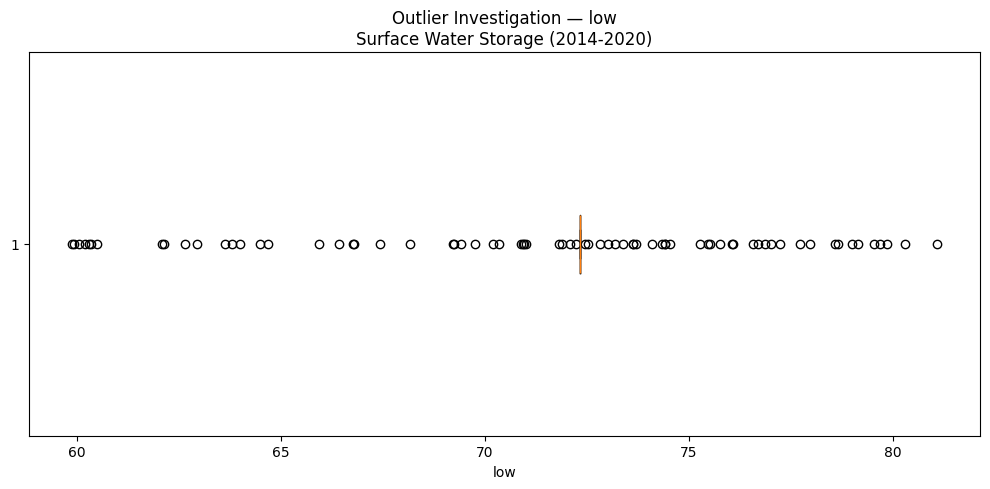

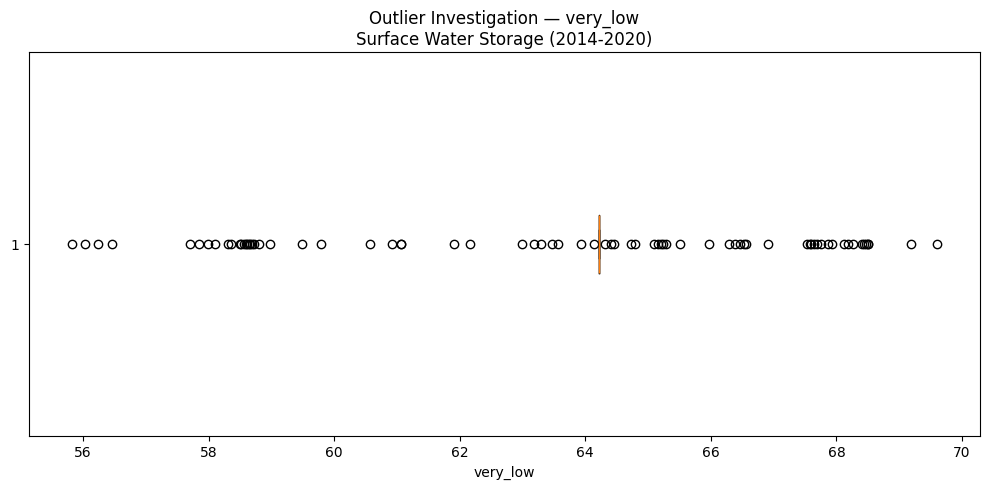

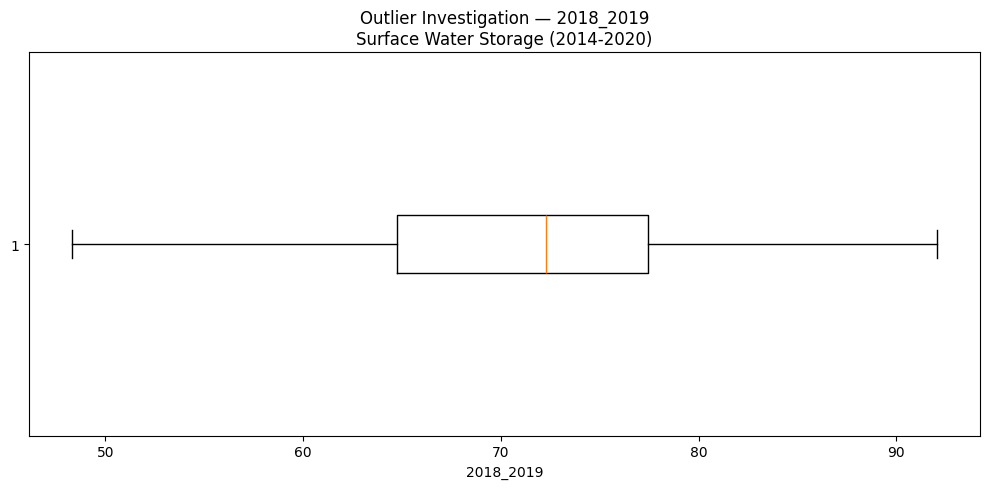

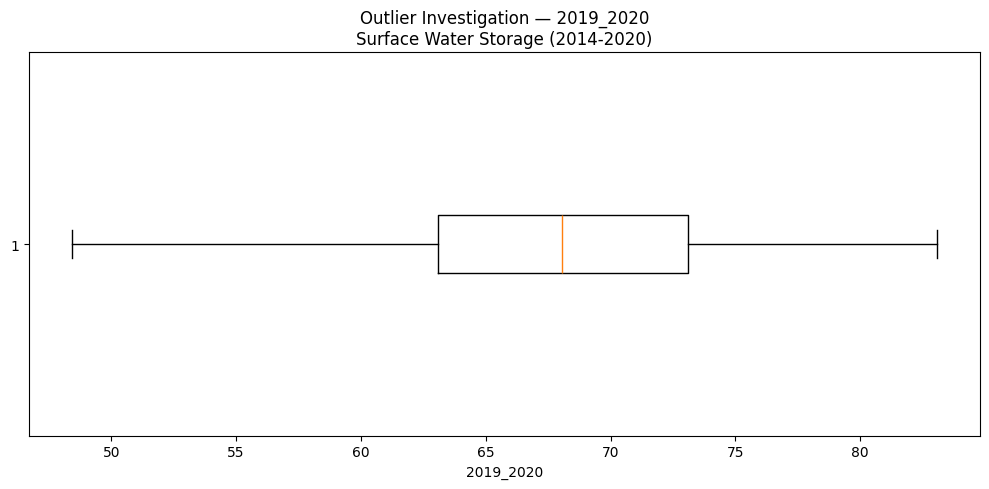

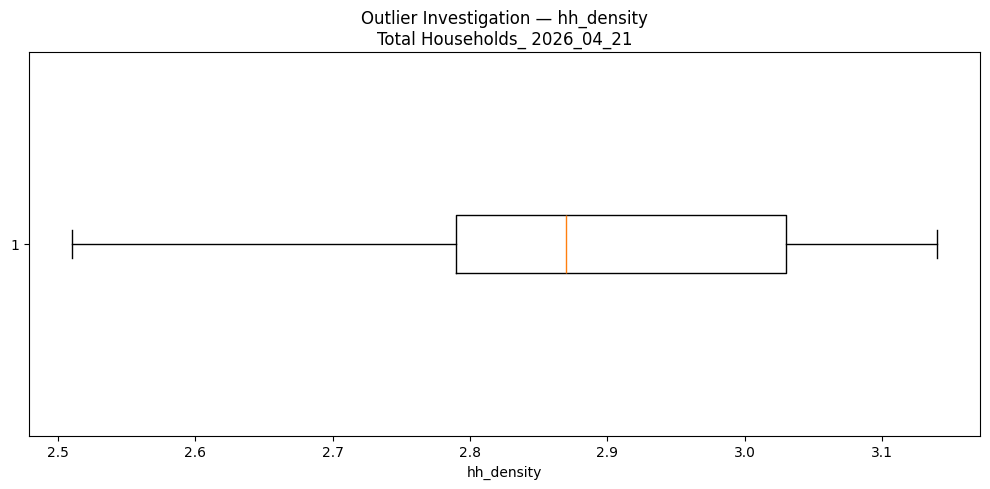

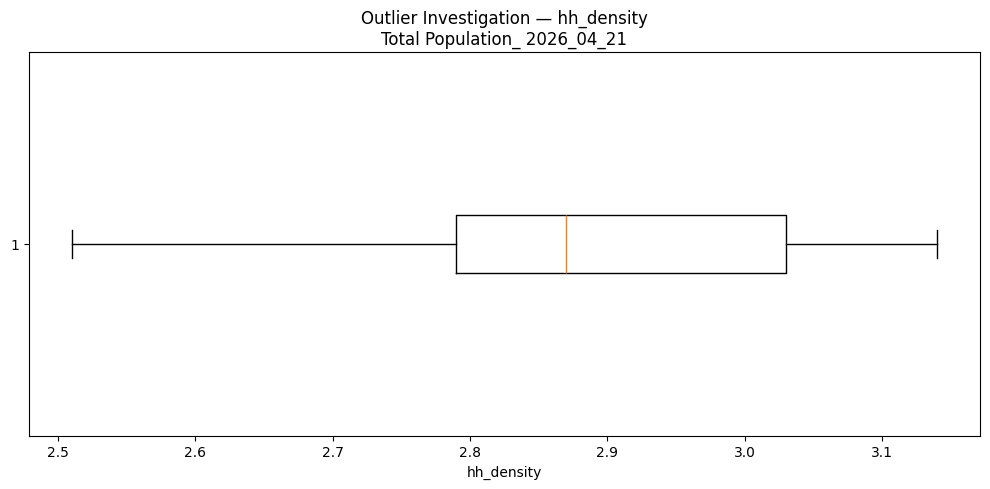

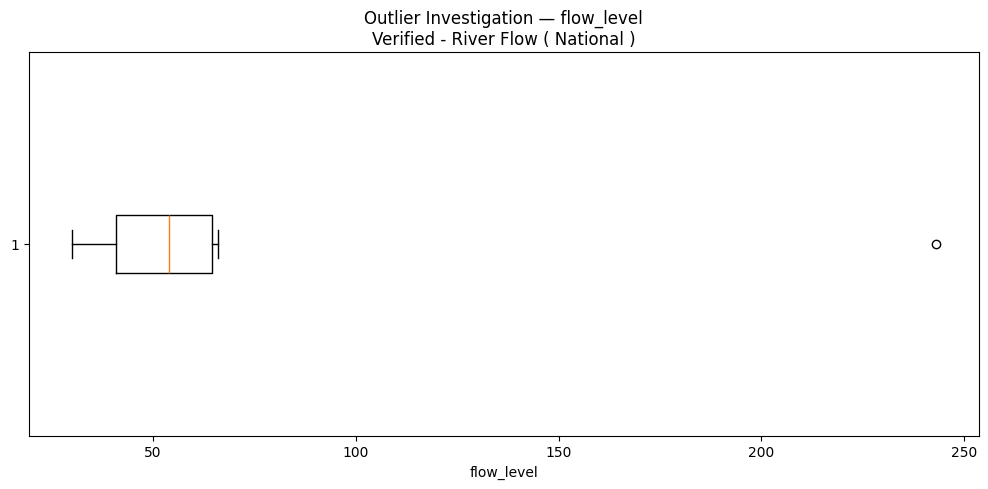

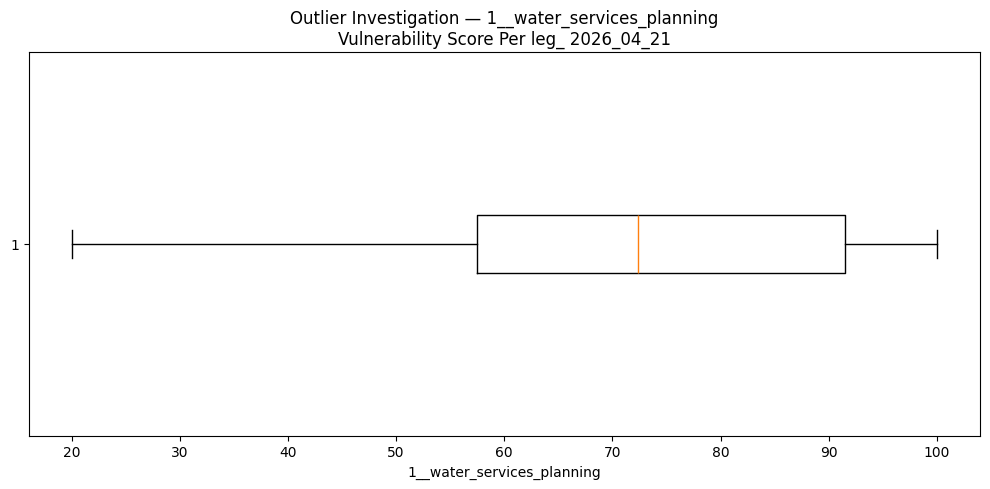

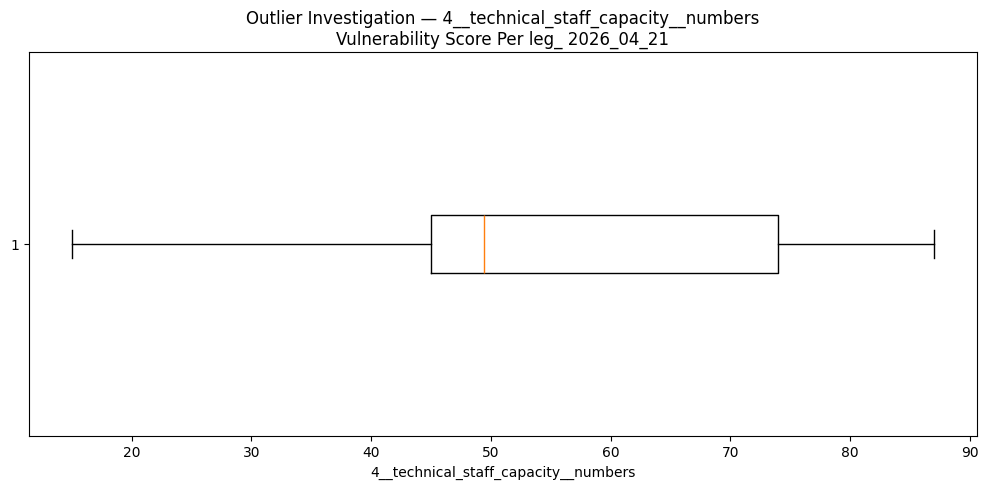

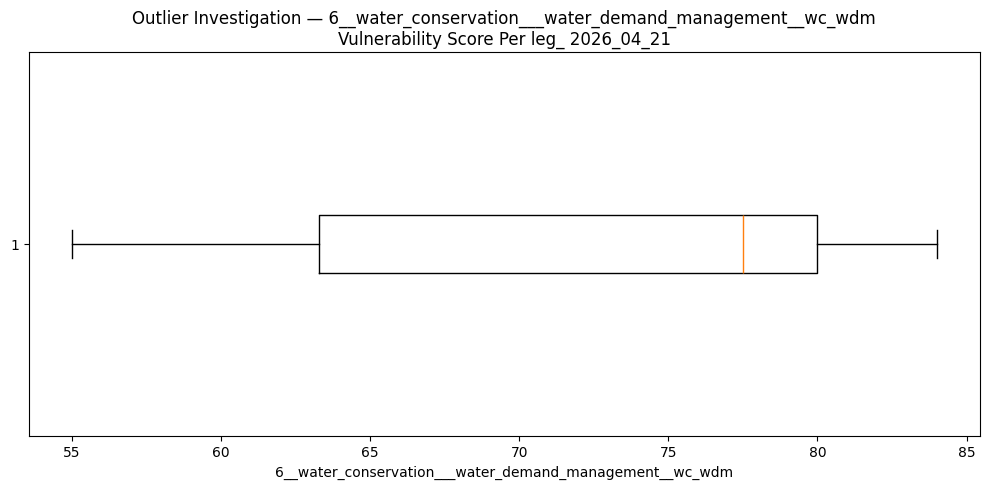

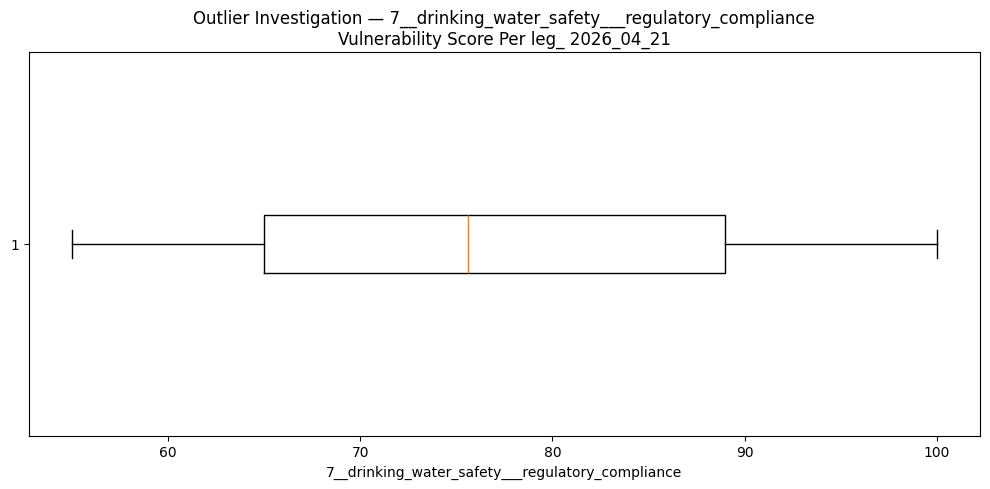

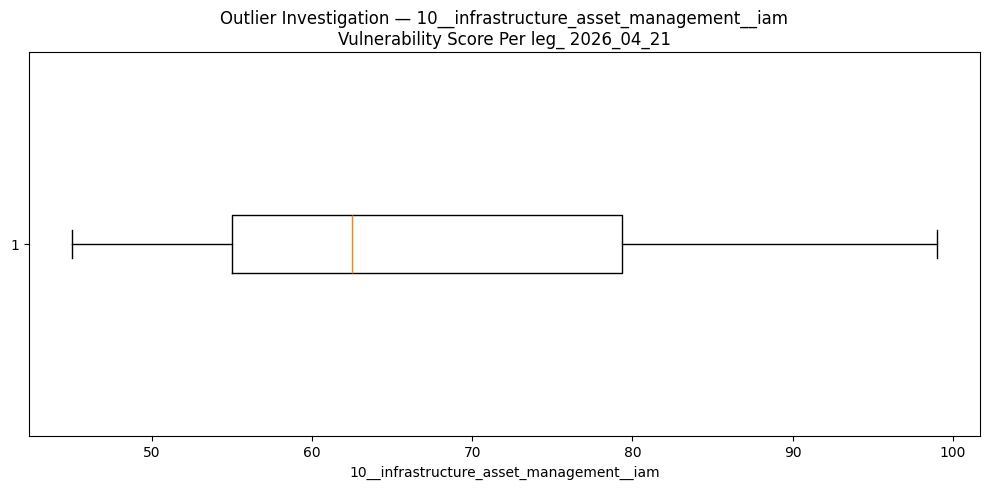

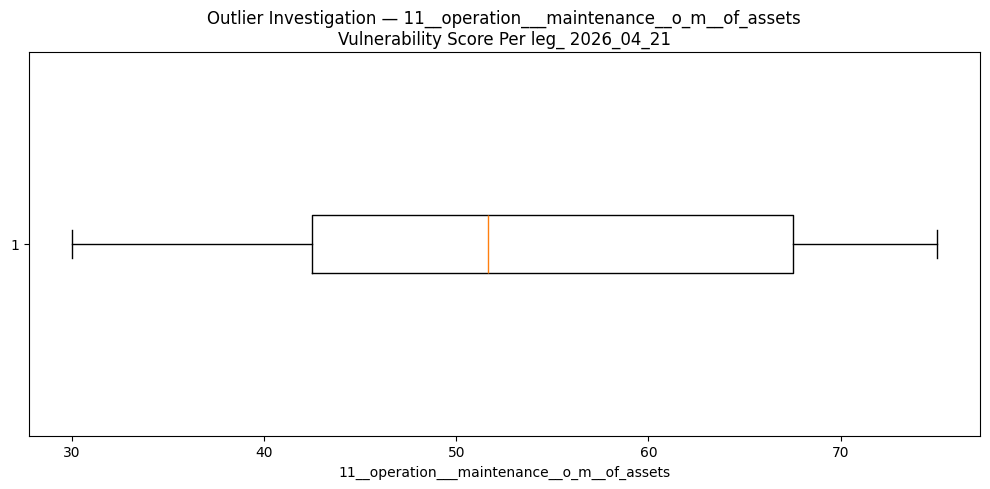

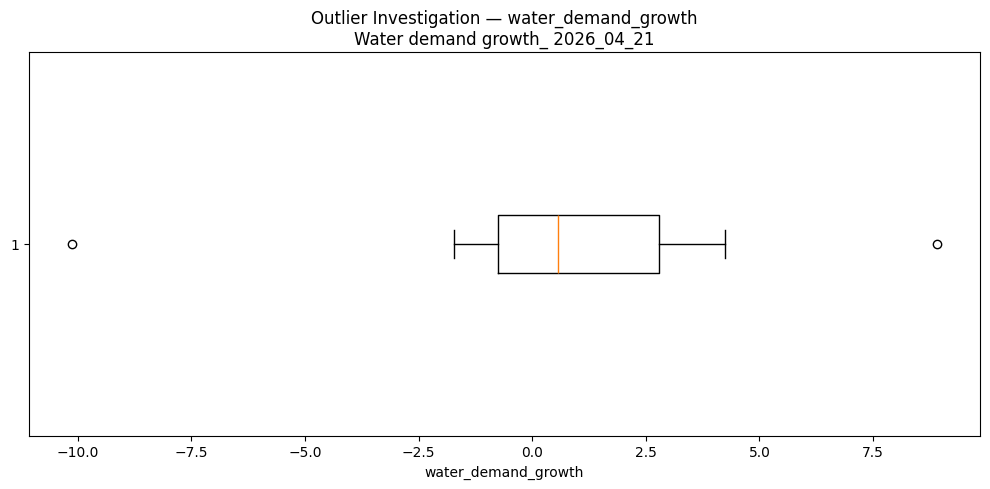

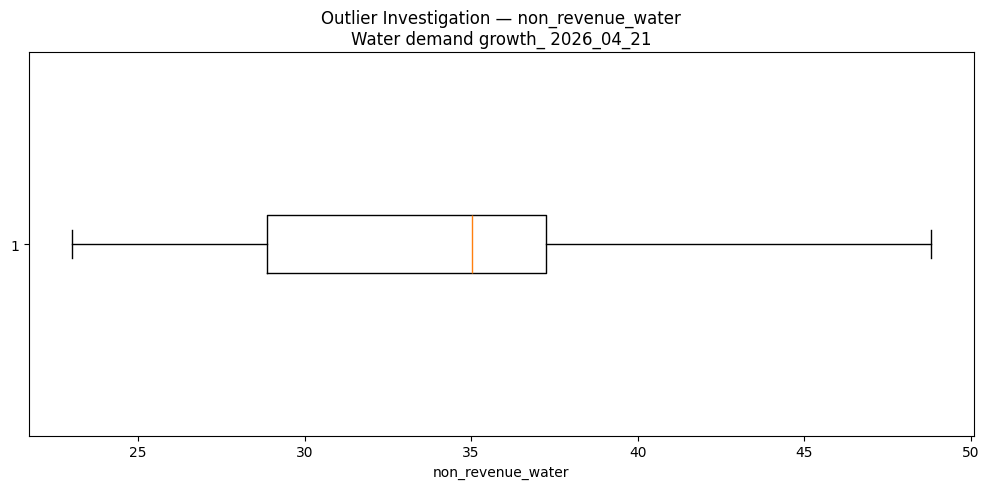

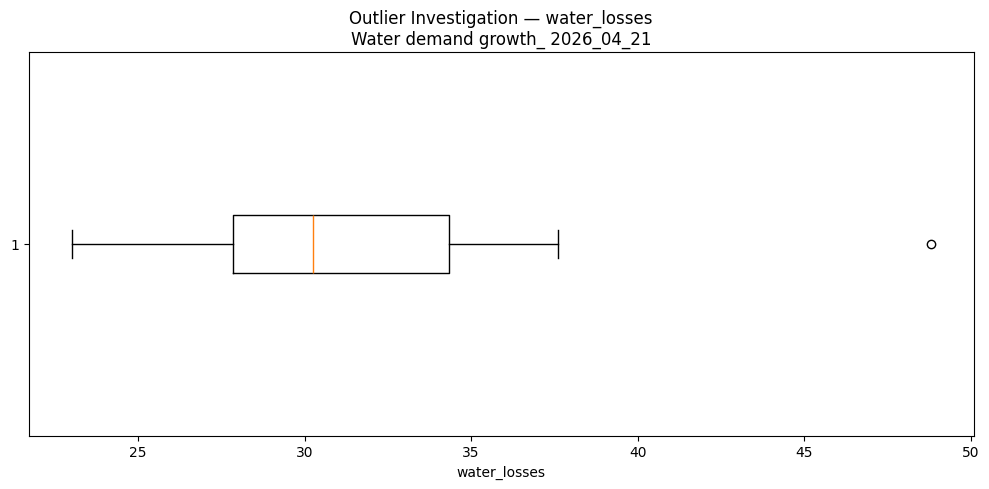

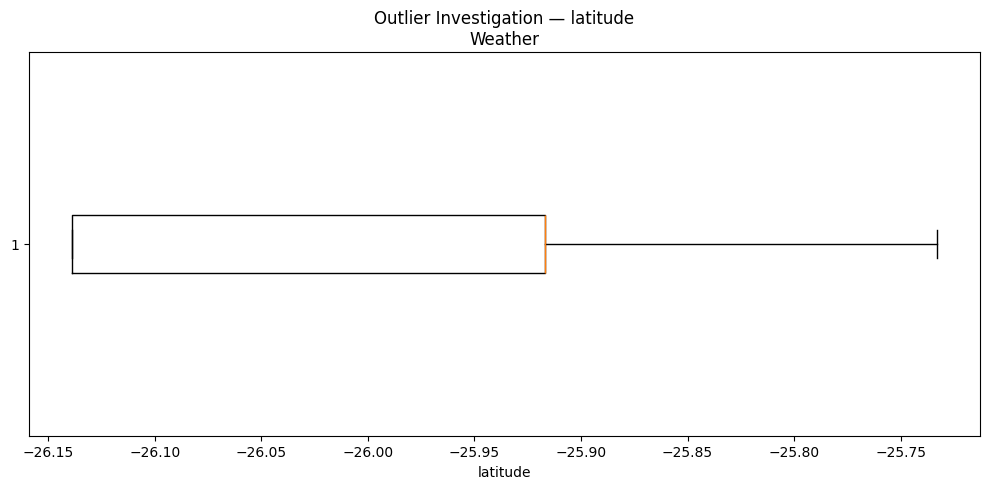

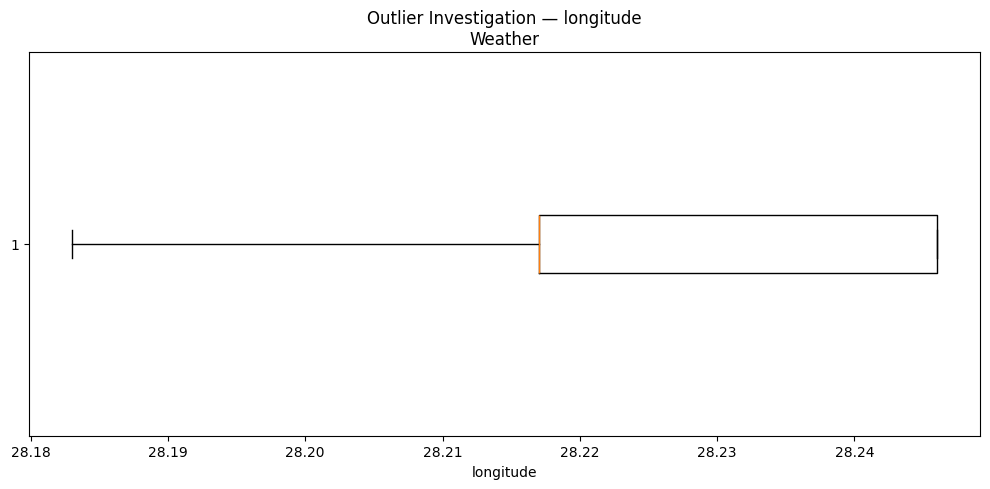

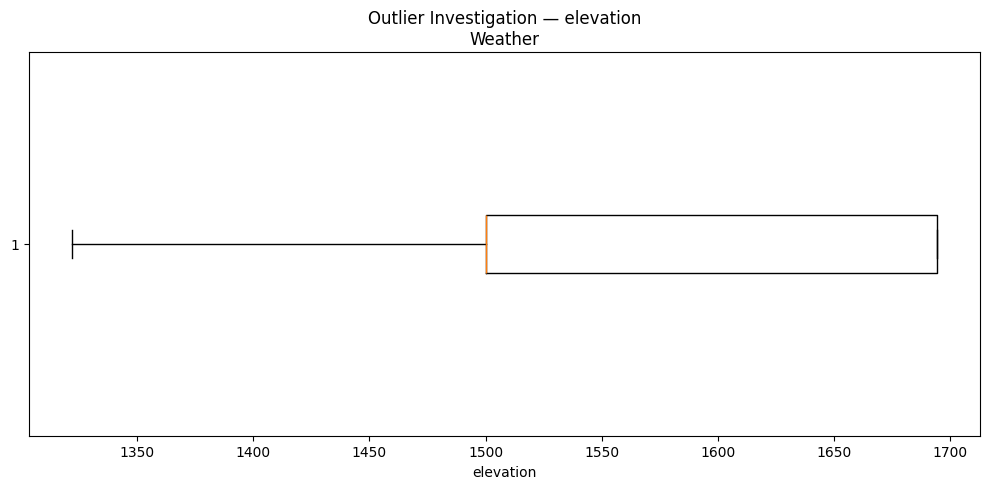

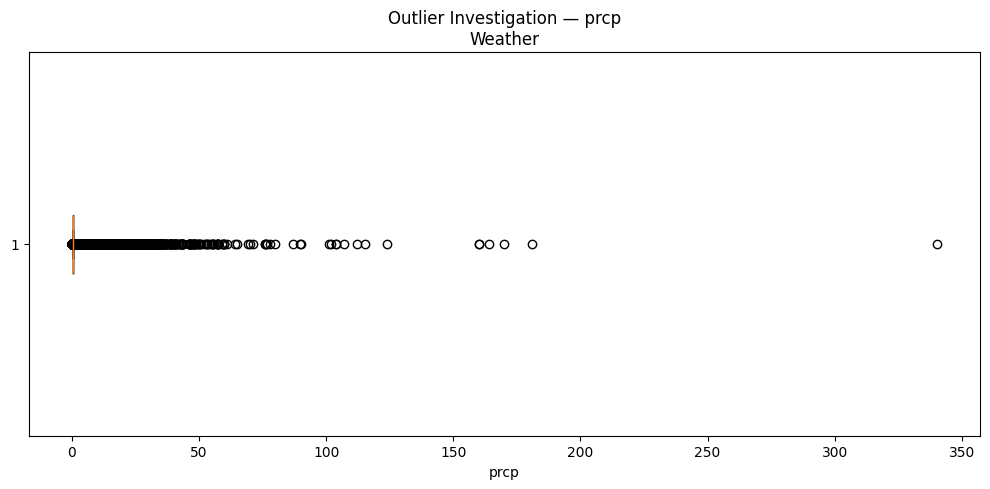

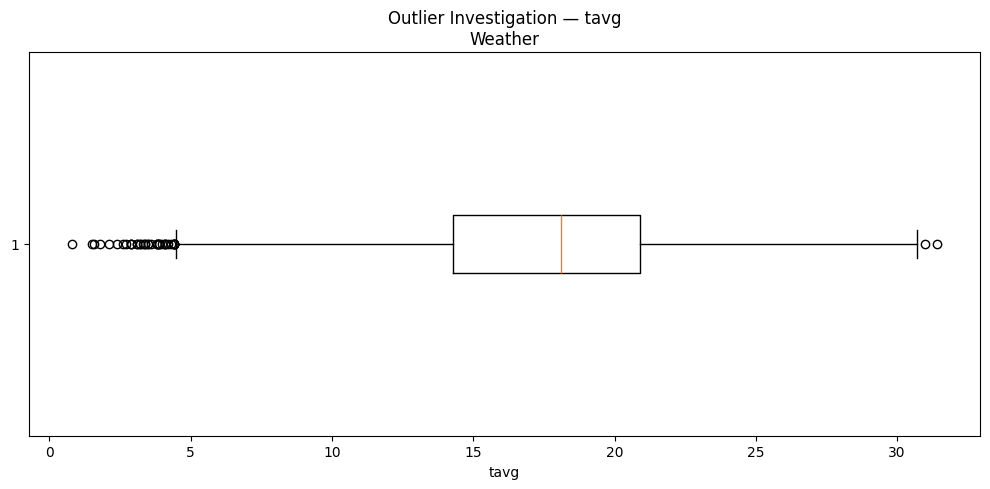

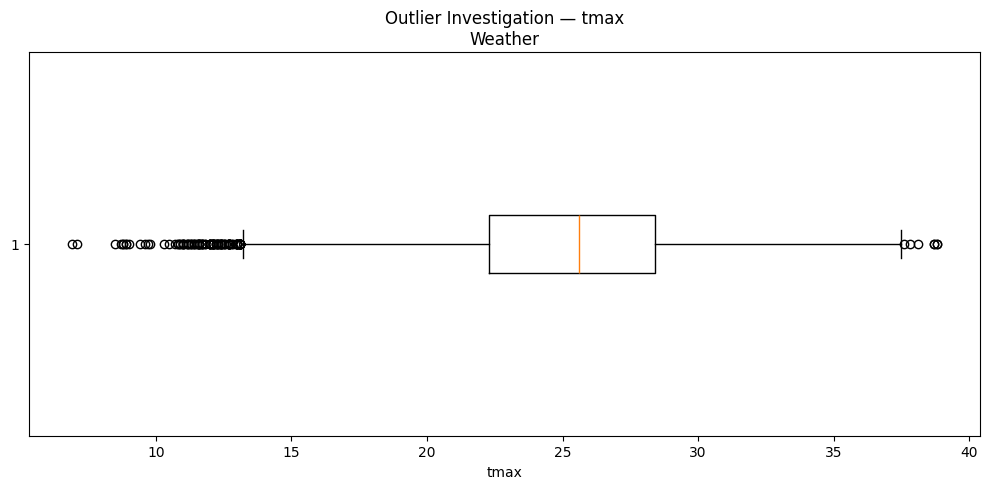

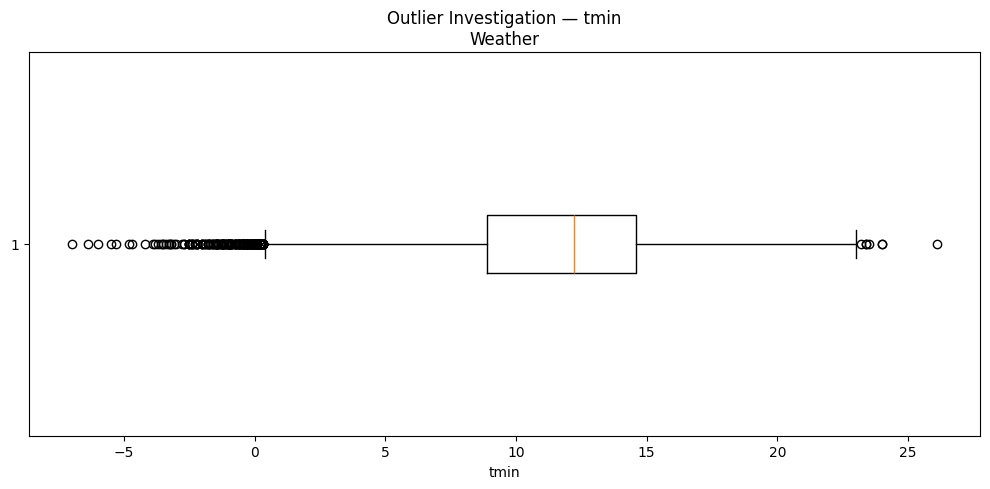

Outlier investigation visualisations generated and saved.


In [12]:
# ============================================================
# BOXPLOTS — OUTLIER INVESTIGATION
# ============================================================

for name, df in cleaned_datasets.items():

    numeric_columns = list(
        df.select_dtypes(include=np.number).columns
    )

    for column in numeric_columns:

        series = pd.to_numeric(
            df[column],
            errors="coerce"
        ).dropna()

        if len(series) < 2:
            continue

        plt.figure(figsize=(10, 5))

        plt.boxplot(
            series,
            vert=False
        )

        plt.title(
            f"Outlier Investigation — {column}\n{name}"
        )
        plt.xlabel(column)

        plt.tight_layout()

        safe_name = re.sub(
            r"[^A-Za-z0-9_.-]",
            "_",
            str(name)
        )

        safe_column = re.sub(
            r"[^A-Za-z0-9_.-]",
            "_",
            str(column)
        )

        output_path = os.path.join(
            EDA_VISUALISATION_DIR,
            f"{safe_name}_{safe_column}_boxplot.png"
        )

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

print("Outlier investigation visualisations generated and saved.")


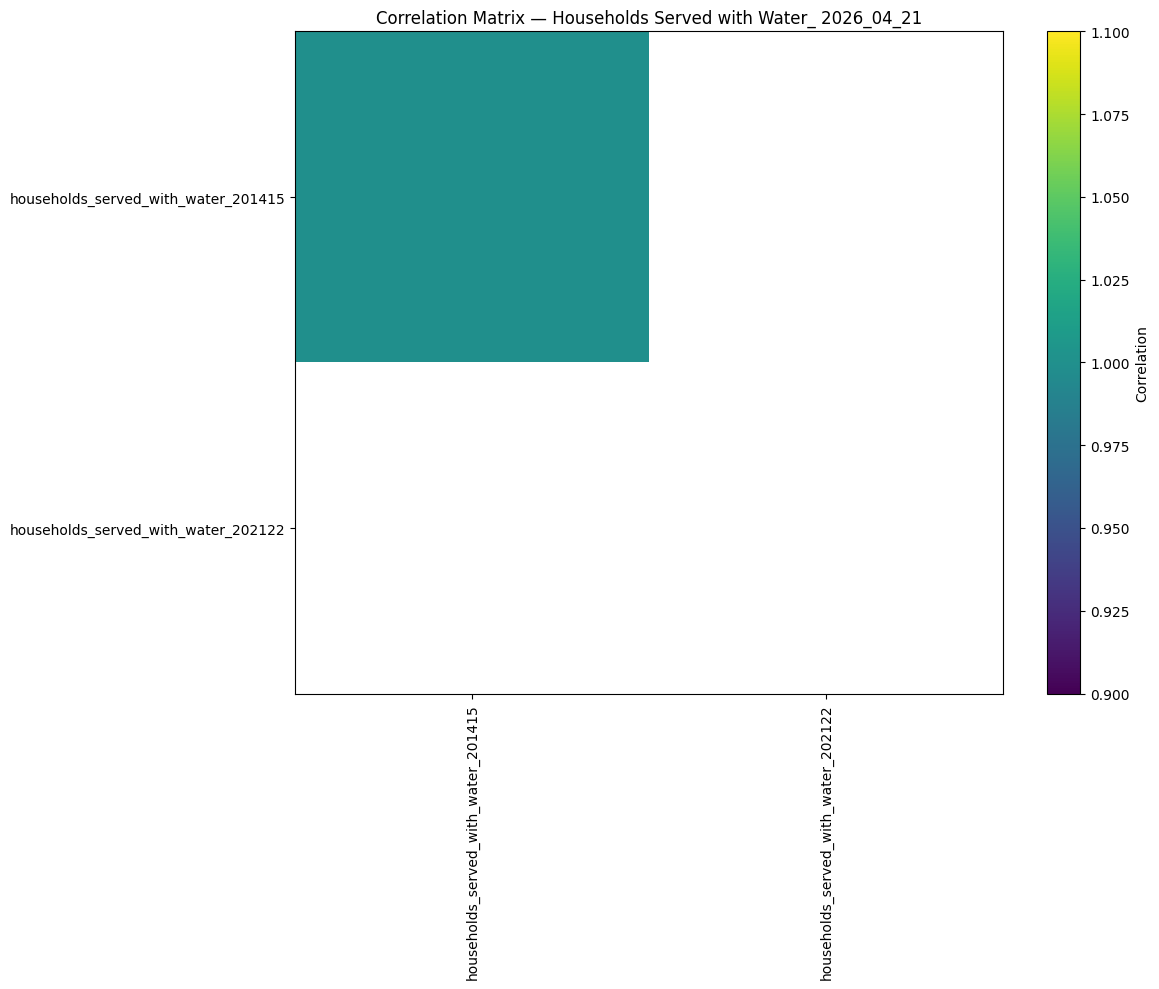

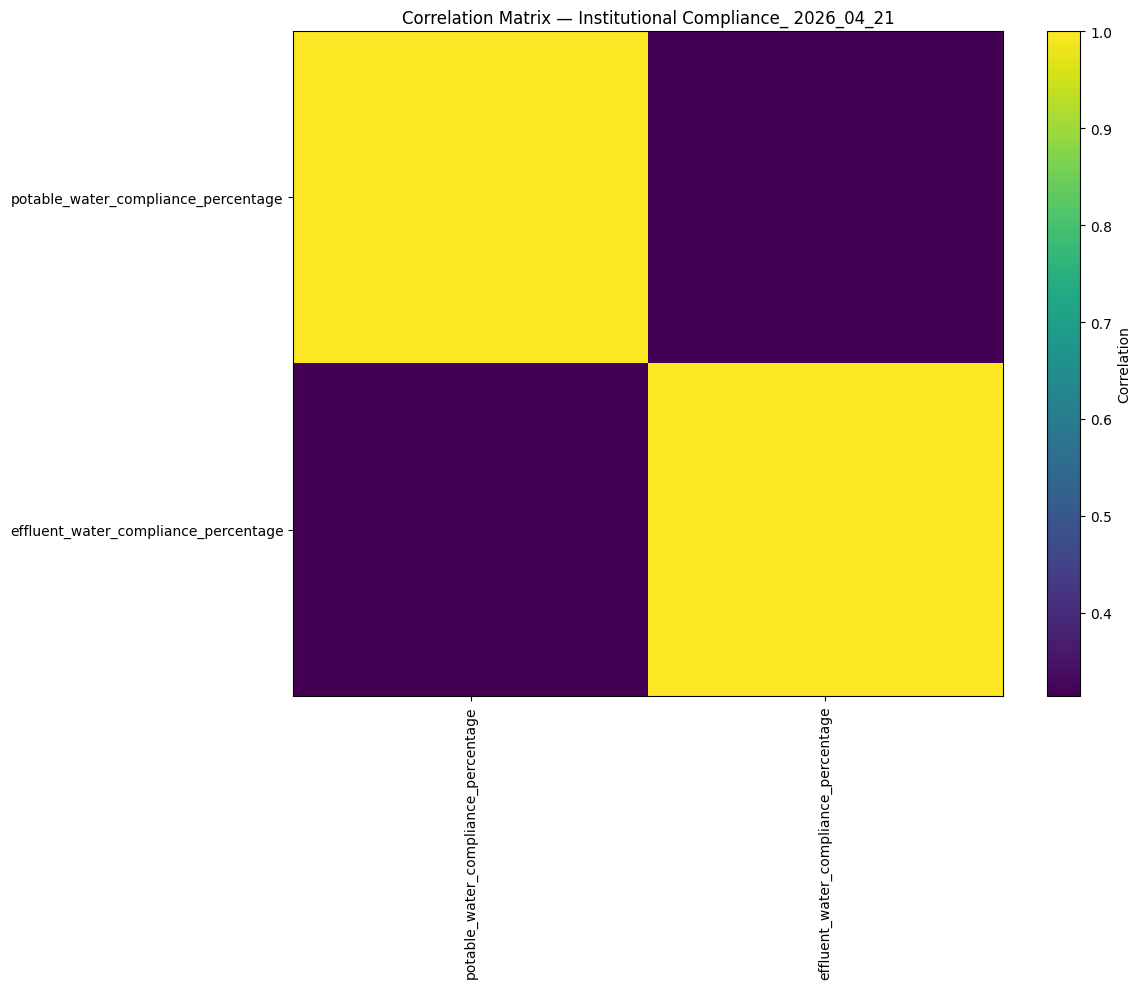

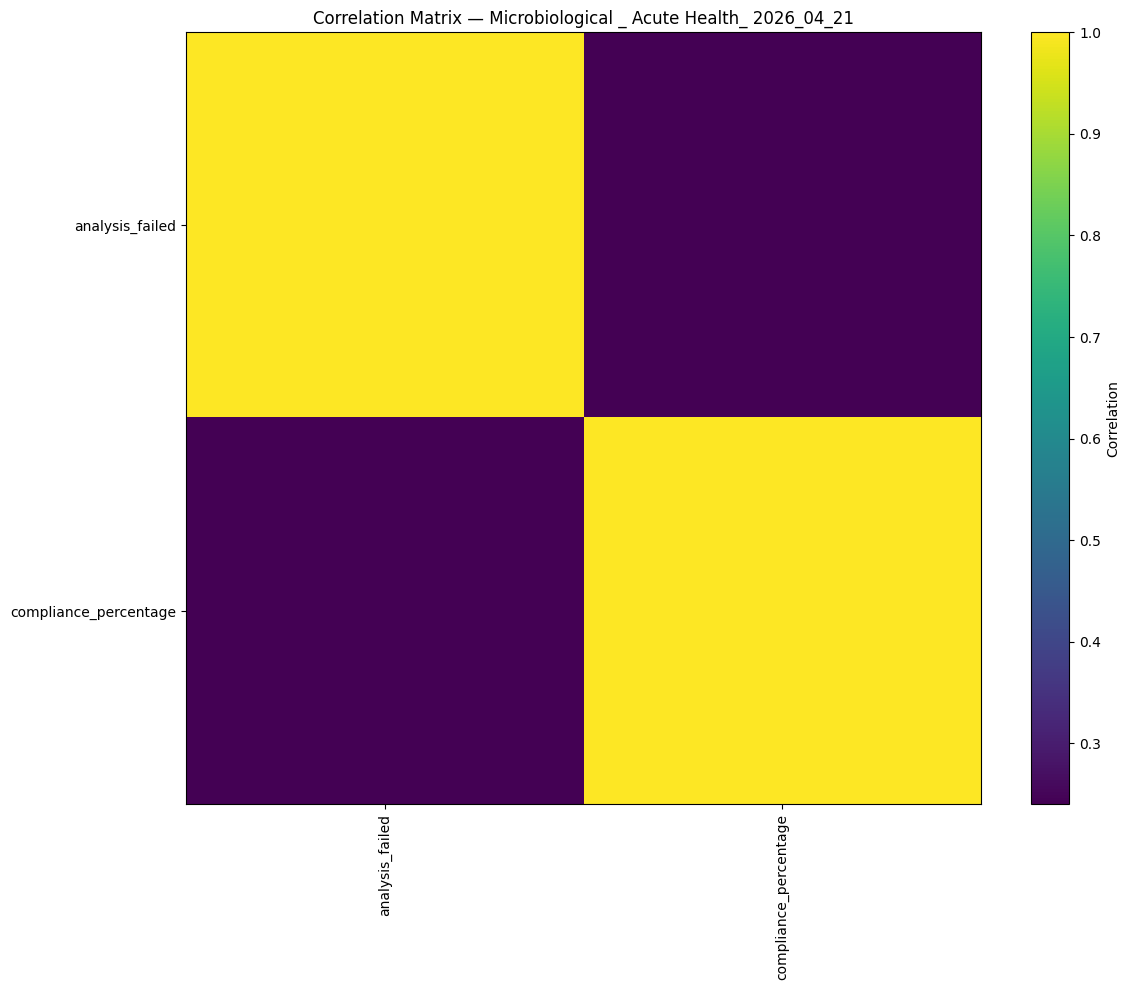

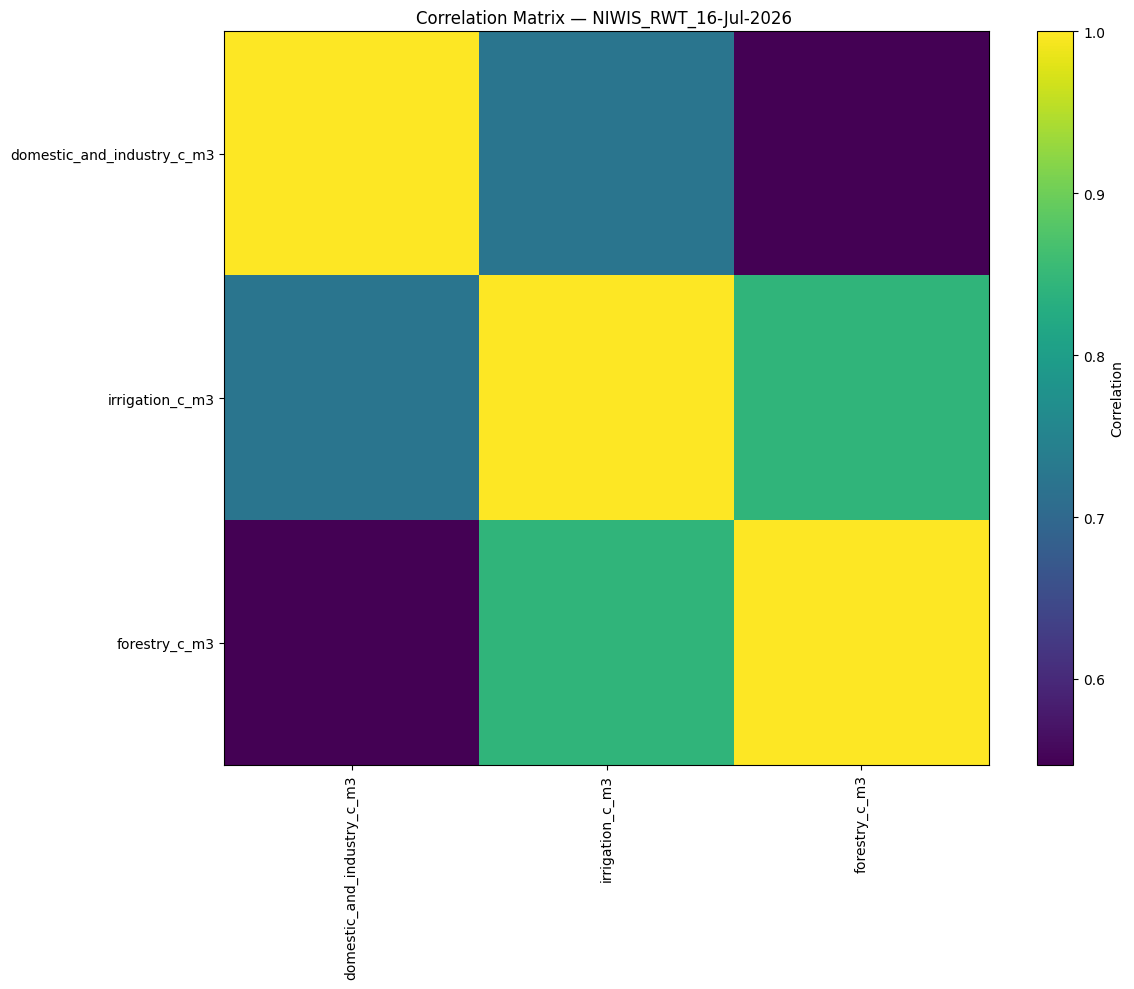

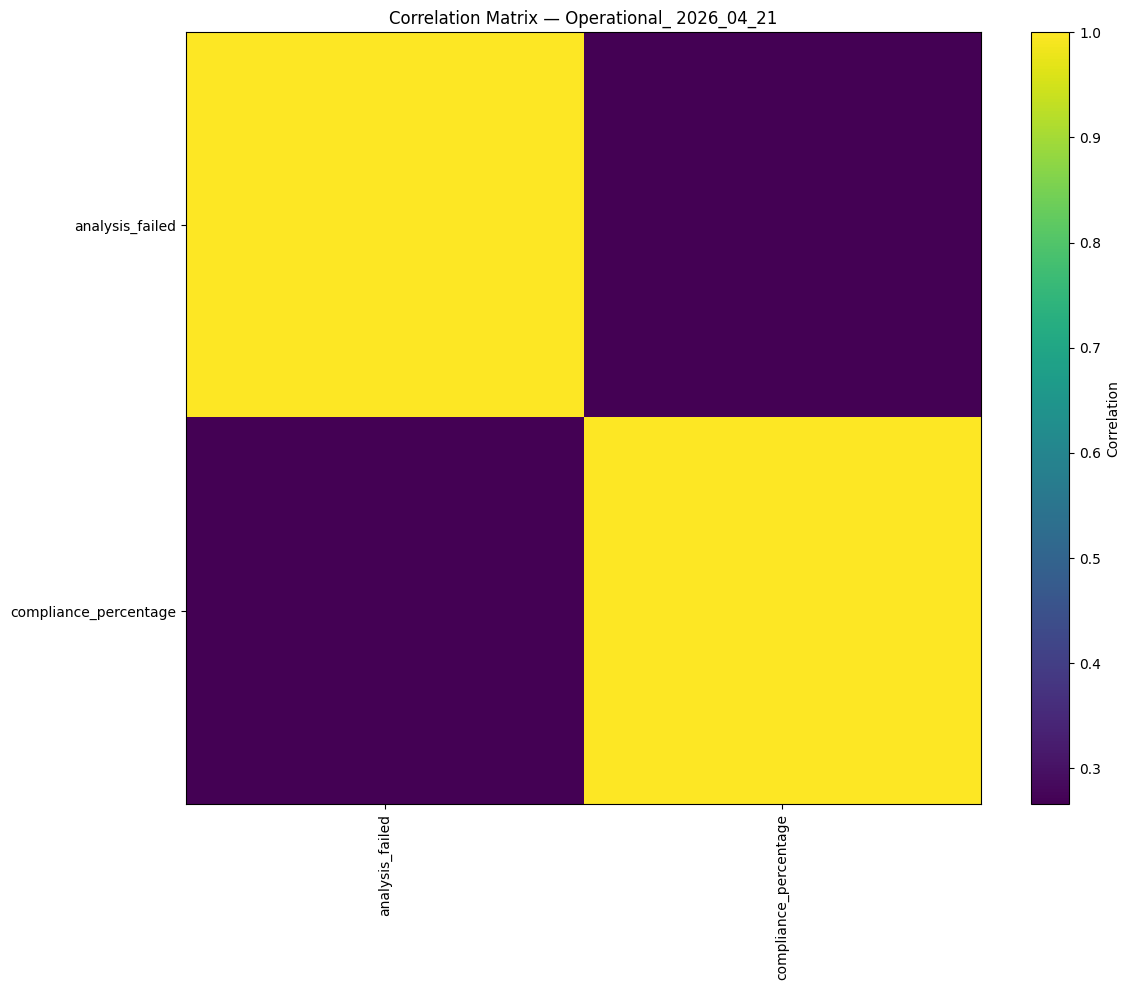

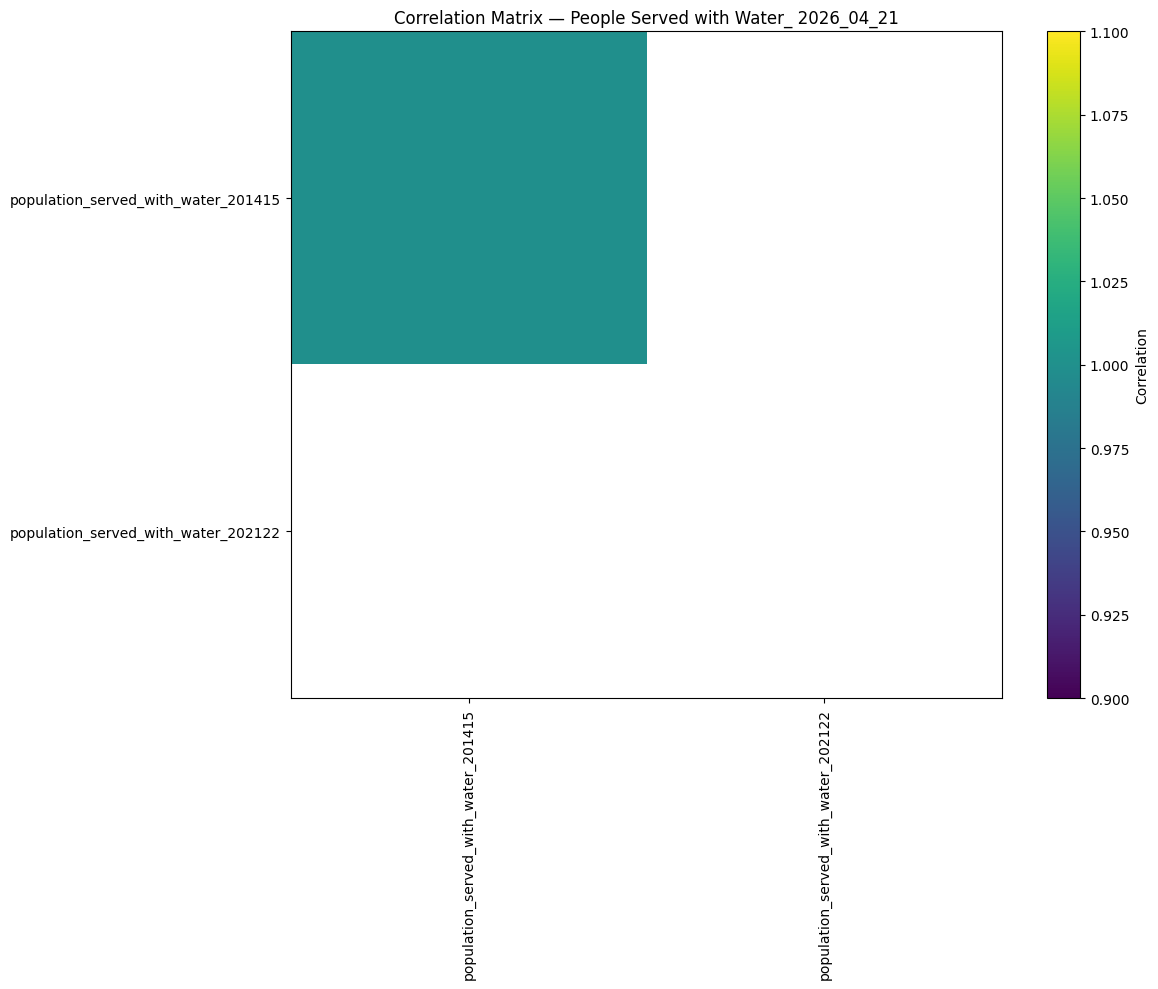

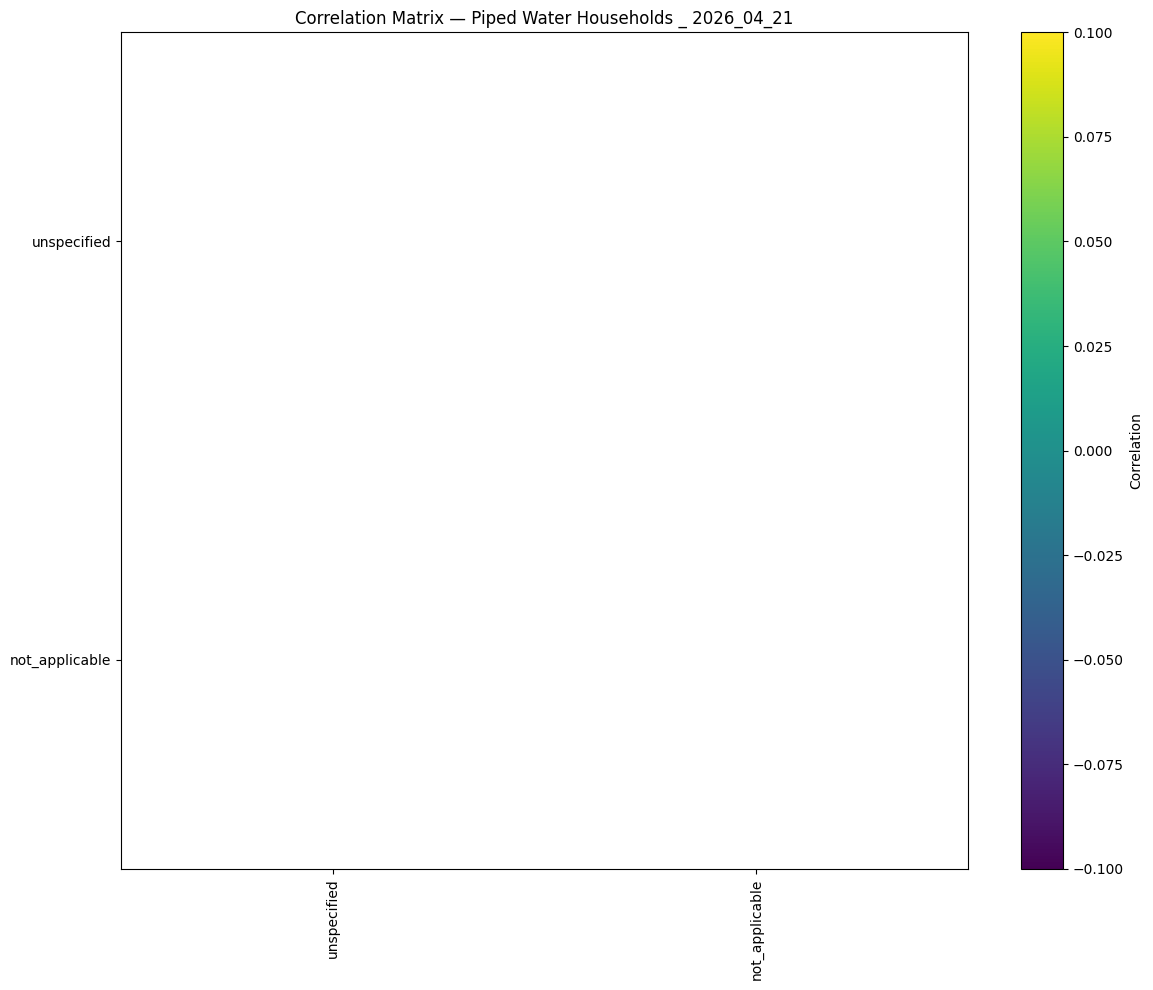

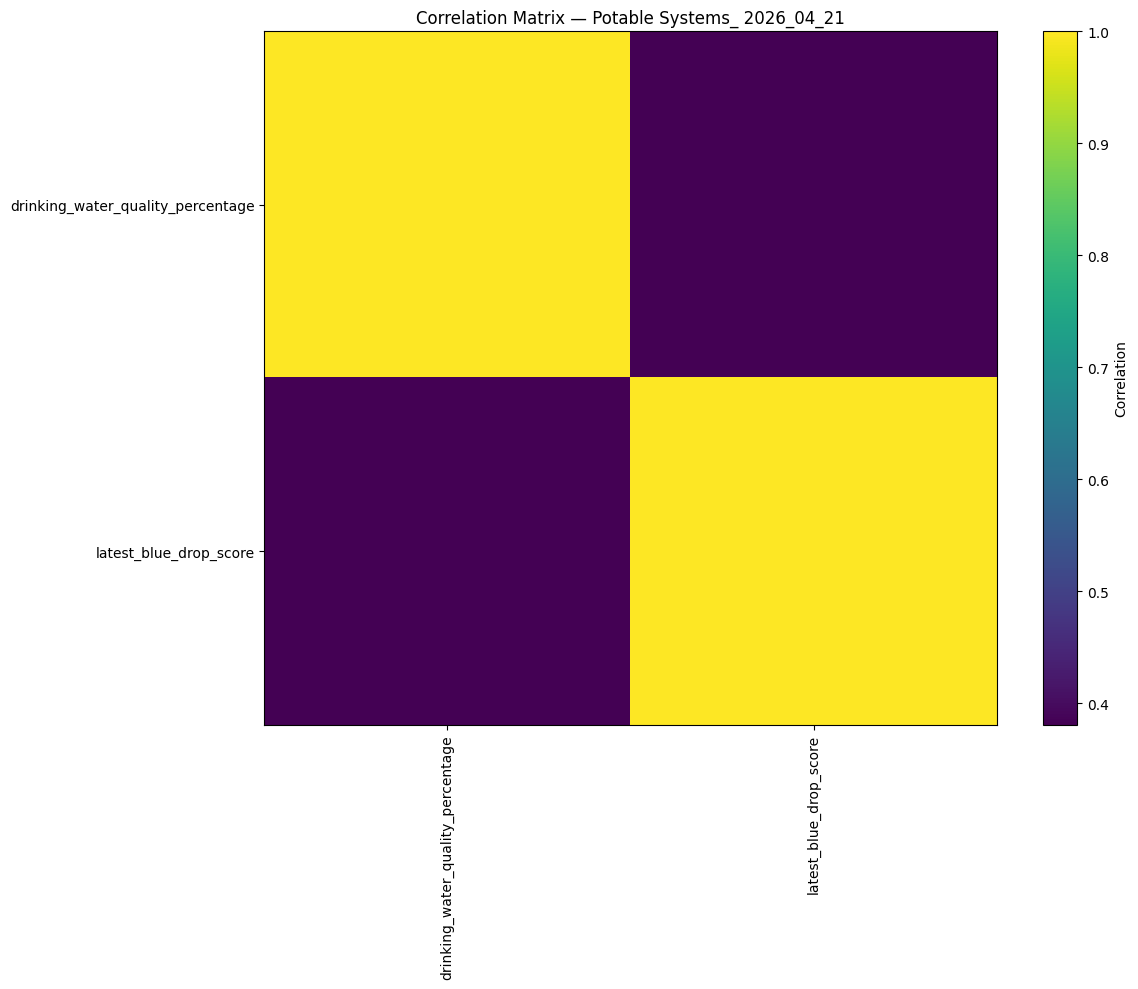

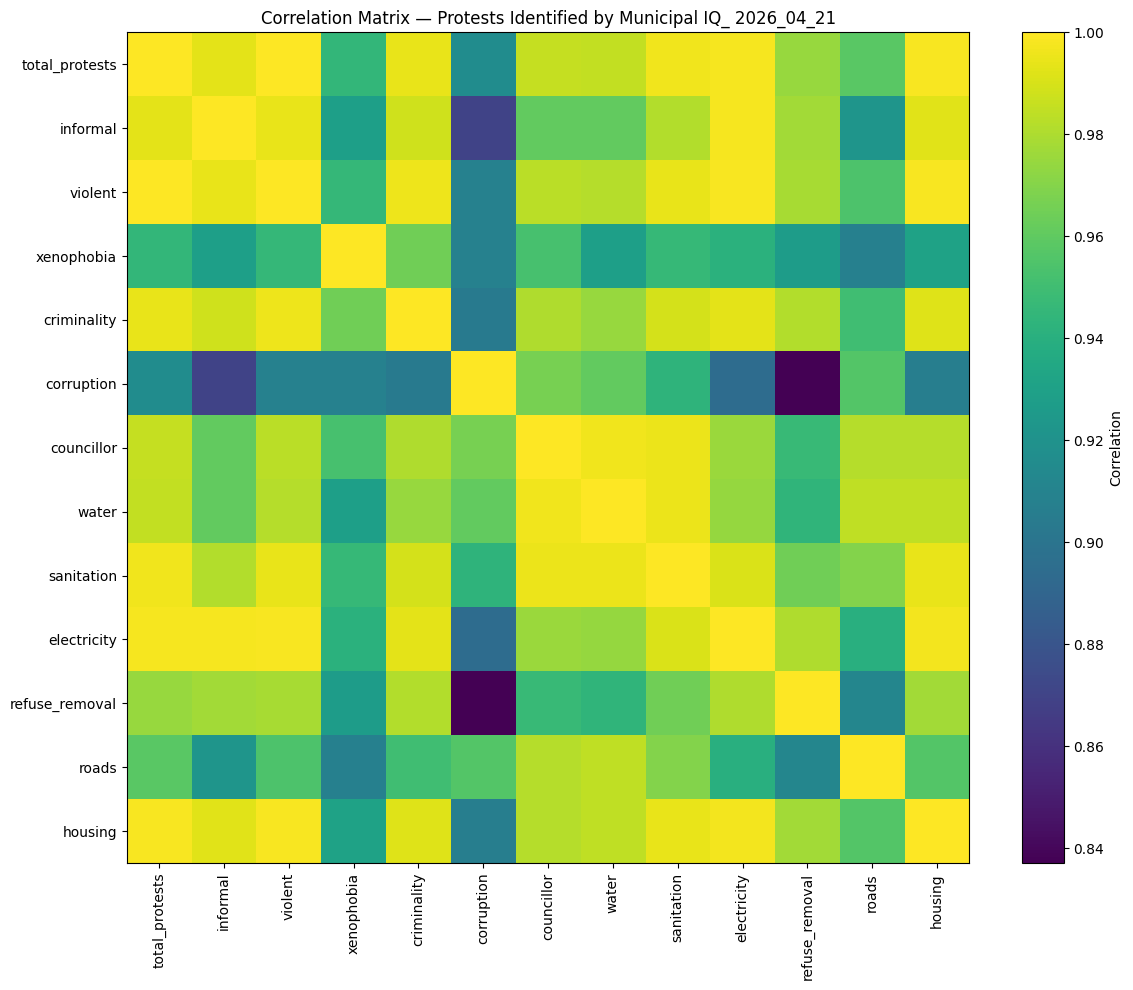

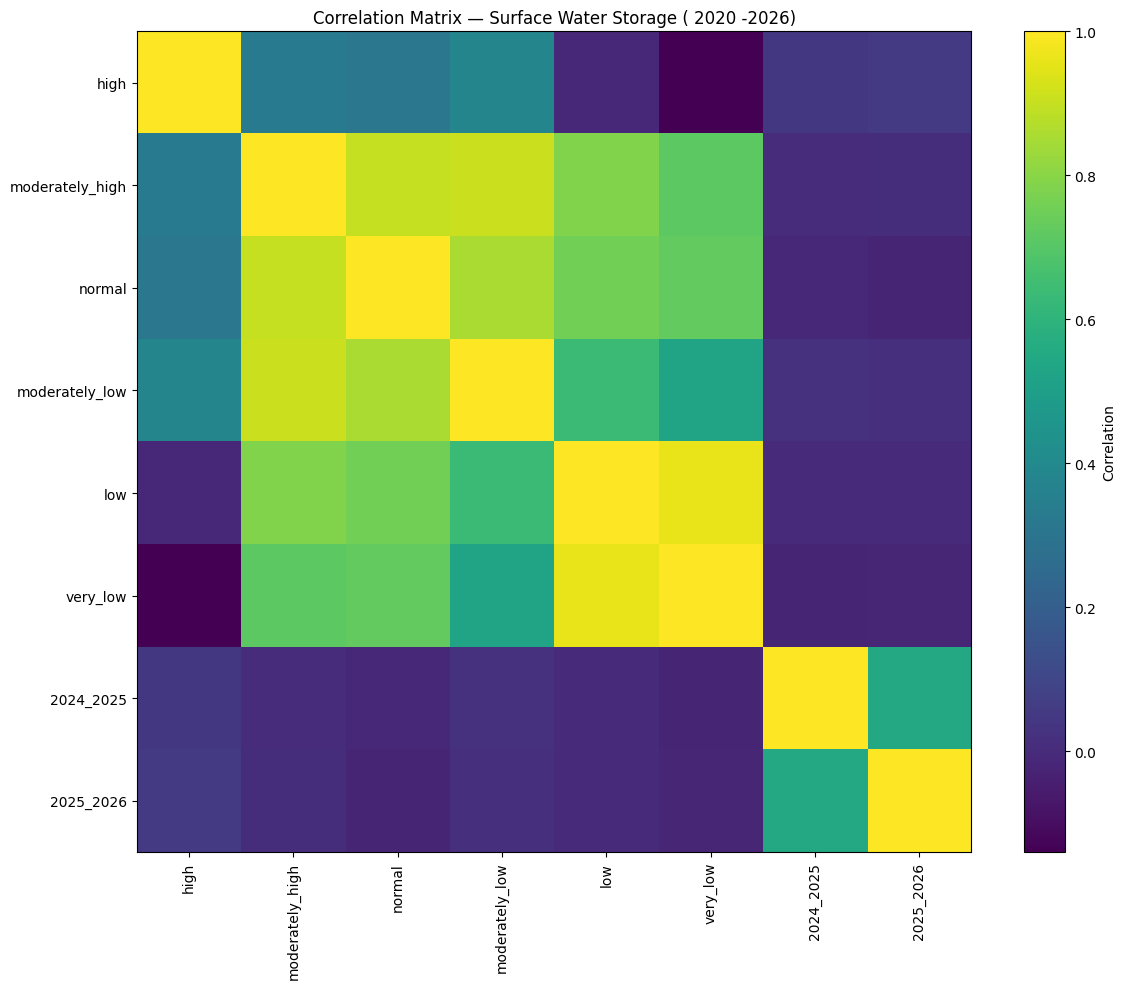

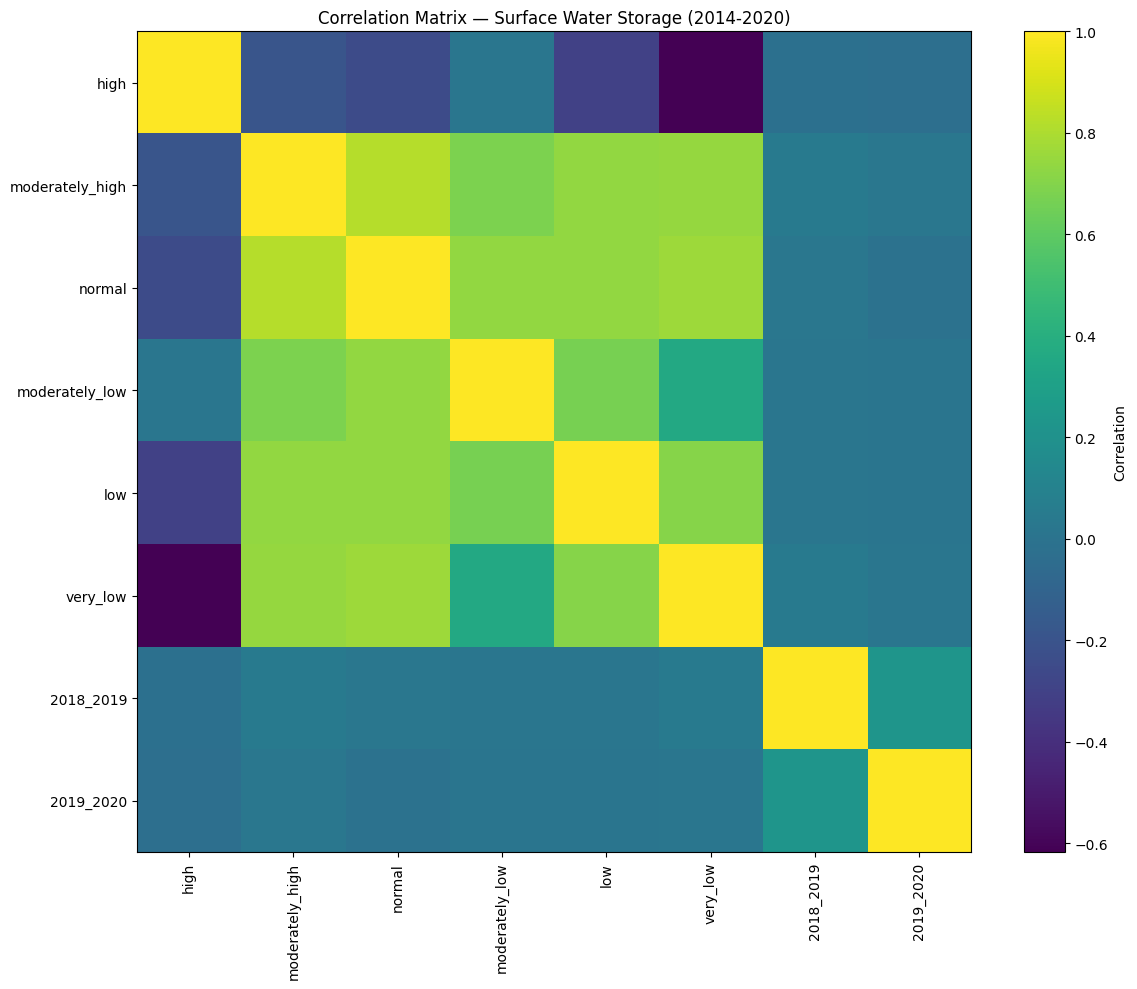

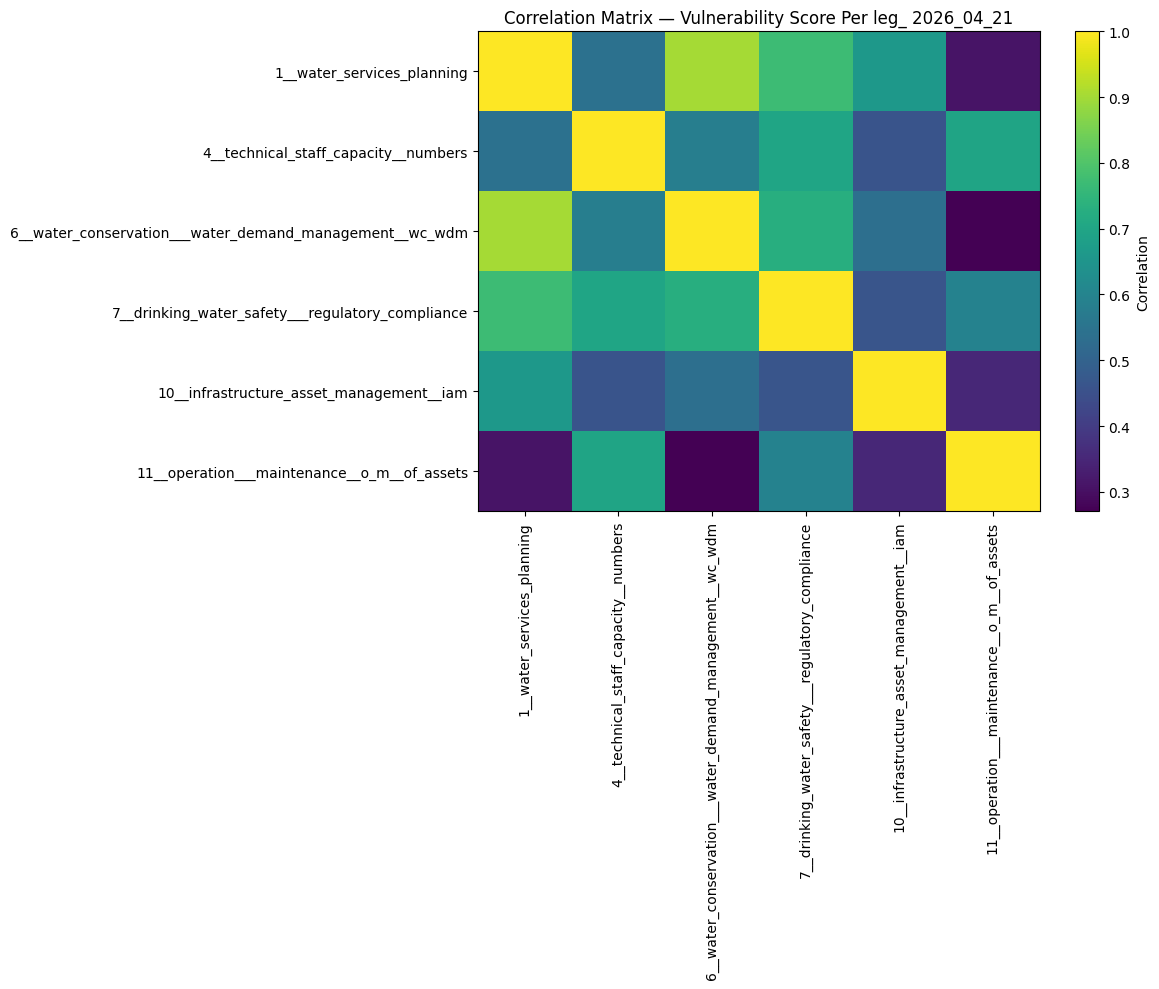

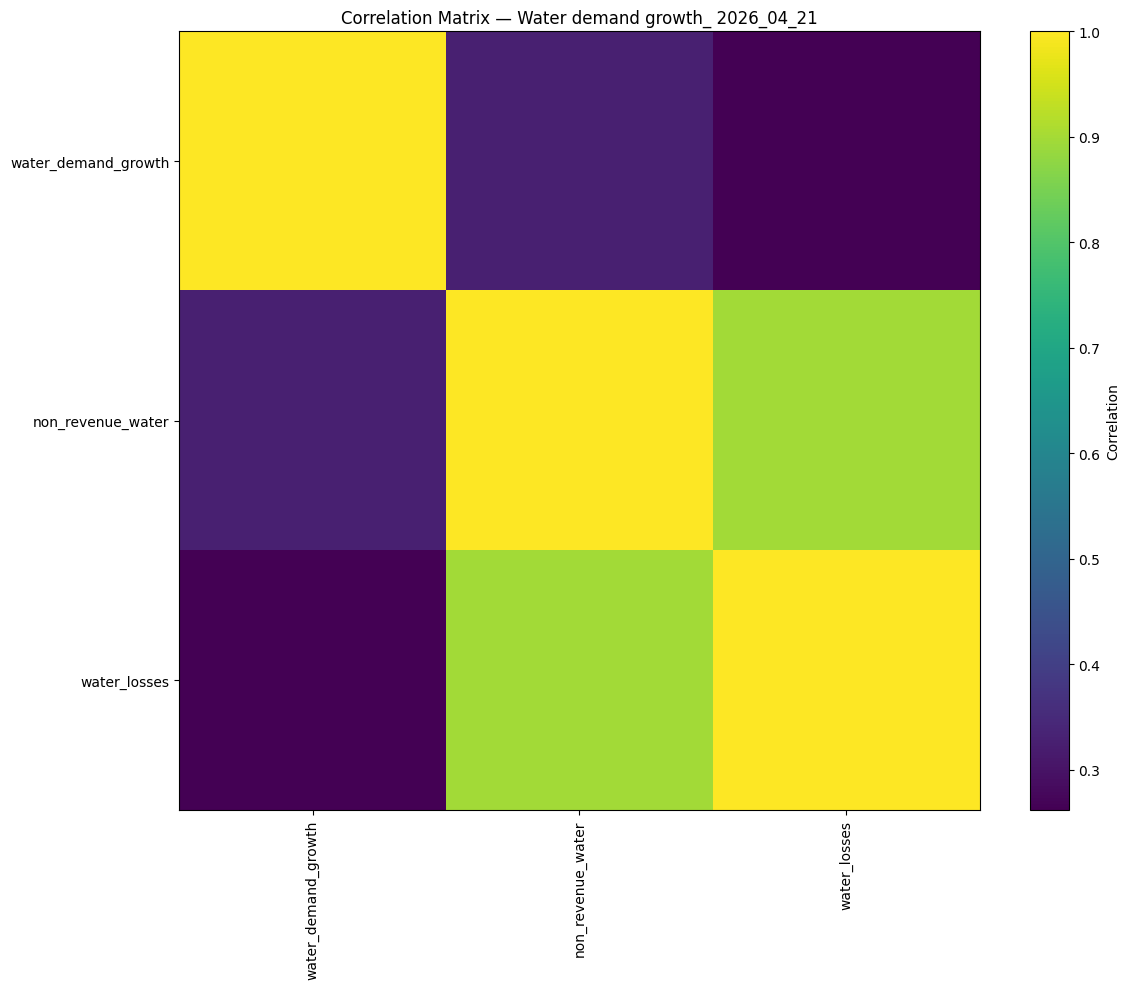

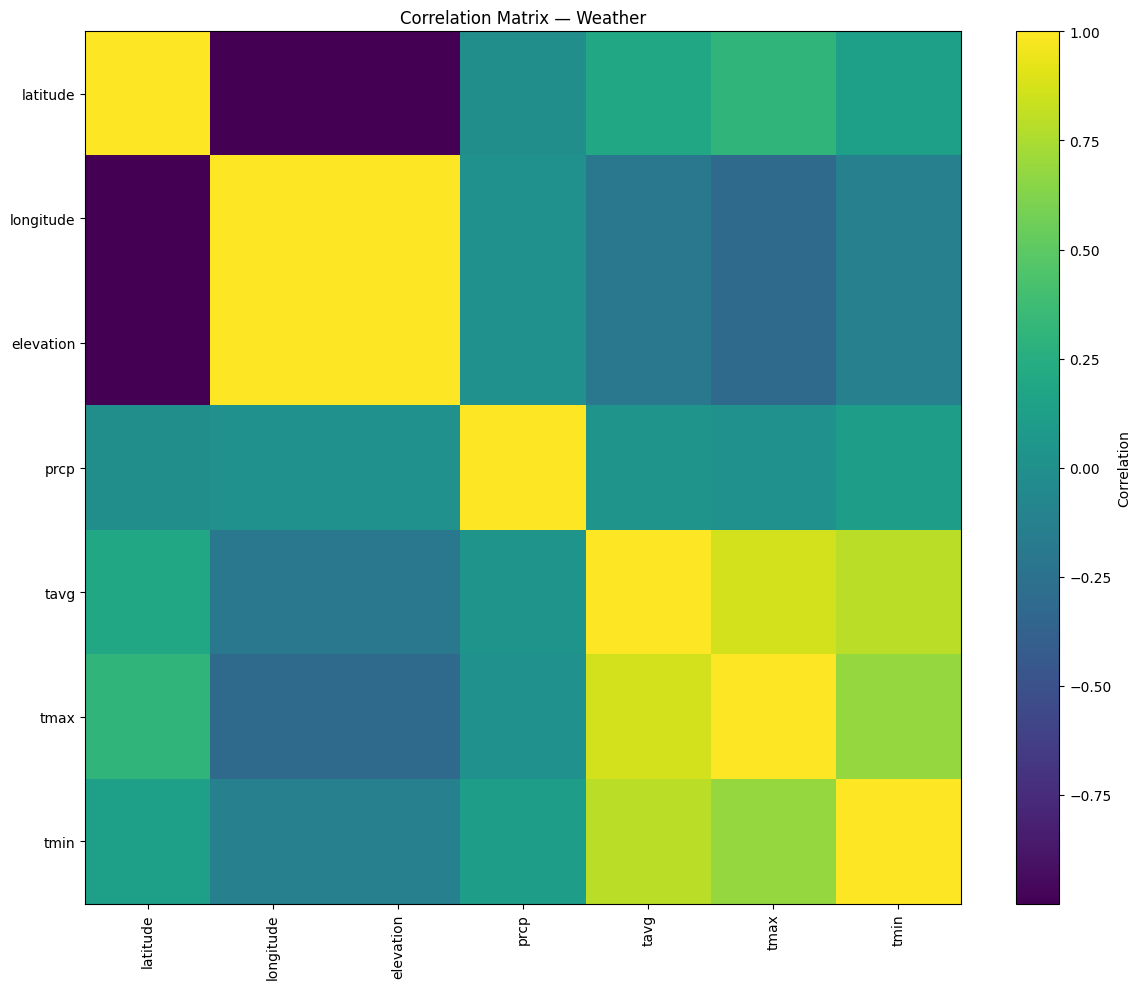

Top correlations:


,Dataset,Feature 1,Feature 2,Correlation,Absolute Correlation
38,Protests Identified by Municipal IQ_ 2026_04_21,violent,total_protests,0.999731,0.999731
15,Protests Identified by Municipal IQ_ 2026_04_21,total_protests,violent,0.999731,0.999731
319,Weather,latitude,elevation,-0.999468,0.999468
330,Weather,elevation,latitude,-0.999468,0.999468
25,Protests Identified by Municipal IQ_ 2026_04_21,total_protests,housing,0.998666,0.998666
158,Protests Identified by Municipal IQ_ 2026_04_21,housing,total_protests,0.998666,0.998666
124,Protests Identified by Municipal IQ_ 2026_04_21,electricity,violent,0.998590,0.998590
46,Protests Identified by Municipal IQ_ 2026_04_21,violent,electricity,0.998590,0.998590
49,Protests Identified by Municipal IQ_ 2026_04_21,violent,housing,0.998475,0.998475
160,Protests Identified by Municipal IQ_ 2026_04_21,housing,violent,0.998475,0.998475


Correlation analysis complete.


In [13]:
# ============================================================
# CORRELATION MATRICES
# ============================================================

correlation_records = []

for name, df in cleaned_datasets.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    if numeric_df.shape[1] < 2:
        continue

    correlation = numeric_df.corr(
        method="pearson"
    )

    safe_name = re.sub(
        r"[^A-Za-z0-9_.-]",
        "_",
        str(name)
    )

    correlation.to_csv(
        os.path.join(
            EDA_DIR,
            f"{safe_name}_correlation_matrix.csv"
        )
    )

    # Save a long-form correlation table for later feature selection.
    for feature_1 in correlation.columns:
        for feature_2 in correlation.columns:

            if feature_1 == feature_2:
                continue

            value = correlation.loc[
                feature_1,
                feature_2
            ]

            if pd.notna(value):

                correlation_records.append({
                    "Dataset": name,
                    "Feature 1": feature_1,
                    "Feature 2": feature_2,
                    "Correlation": float(value),
                    "Absolute Correlation": abs(float(value)),
                })

    plt.figure(figsize=(12, 10))

    plt.imshow(
        correlation,
        aspect="auto"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(len(correlation.columns)),
        correlation.columns,
        rotation=90
    )

    plt.yticks(
        range(len(correlation.columns)),
        correlation.columns
    )

    plt.title(
        f"Correlation Matrix — {name}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            EDA_VISUALISATION_DIR,
            f"{safe_name}_correlation_matrix.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

feature_correlations_df = pd.DataFrame(
    correlation_records
)

if not feature_correlations_df.empty:

    feature_correlations_df = (
        feature_correlations_df
        .sort_values(
            "Absolute Correlation",
            ascending=False
        )
    )

    feature_correlations_df.to_csv(
        os.path.join(
            EDA_DIR,
            "feature_correlations.csv"
        ),
        index=False
    )

    print("Top correlations:")
    display(
        feature_correlations_df.head(50)
    )

print("Correlation analysis complete.")


In [14]:
# ============================================================
# DATE / TIME DISCOVERY
# ============================================================

datetime_records = []

for name, df in cleaned_datasets.items():

    # Include actual datetime columns.
    for column in df.select_dtypes(
        include=["datetime"]
    ).columns:

        datetime_records.append({
            "Dataset": name,
            "Column": column,
            "Minimum": df[column].min(),
            "Maximum": df[column].max(),
            "Observations": int(
                df[column].notna().sum()
            ),
        })

    # Also inspect object/string columns that look like dates.
    for column in df.select_dtypes(
        include=["object"]
    ).columns:

        sample = df[column].dropna().head(100)

        if sample.empty:
            continue

        parsed = pd.to_datetime(
            sample,
            errors="coerce"
        )

        valid_ratio = parsed.notna().mean()

        if valid_ratio >= 0.80:

            full_parsed = pd.to_datetime(
                df[column],
                errors="coerce"
            )

            datetime_records.append({
                "Dataset": name,
                "Column": column,
                "Minimum": full_parsed.min(),
                "Maximum": full_parsed.max(),
                "Observations": int(
                    full_parsed.notna().sum()
                ),
            })

datetime_inventory_df = pd.DataFrame(
    datetime_records
)

display(datetime_inventory_df)

datetime_inventory_df.to_csv(
    os.path.join(
        EDA_DIR,
        "datetime_inventory.csv"
    ),
    index=False
)

print("Date/time inventory saved.")


,Dataset,Column,Minimum,Maximum,Observations
0,Households Served with Water_ 2026_04_21,time_frame,2026-04-01 00:00:00.000000000,2026-04-01 00:00:00.000000000,10
1,Institutional Compliance_ 2026_04_21,time_frame,2022-04-01 00:00:00.000000000,2022-04-01 00:00:00.000000000,10
2,NIWIS_RWT_16-Jul-2026,date,1970-01-01 00:00:00.000002025,1970-01-01 00:00:00.000002025,9
3,People Served with Water_ 2026_04_21,time_frame,2026-04-01 00:00:00.000000000,2026-04-01 00:00:00.000000000,10
4,Piped Water Households _ 2026_04_21,time_frame,2011-10-01 00:00:00.000000000,2011-10-01 00:00:00.000000000,9
5,Potable Systems_ 2026_04_21,time_frame,2022-04-01 00:00:00.000000000,2022-04-01 00:00:00.000000000,60
6,Source of Water Households _ 2026_04_21,time_frame,2011-10-01 00:00:00.000000000,2011-10-01 00:00:00.000000000,9
7,Surface Water Storage ( 2020 -2026),datetime,2020-10-01 00:00:00.000000000,2026-09-24 00:00:00.000000000,375
8,Surface Water Storage (2014-2020),datetime,2014-10-01 00:00:00.000000000,2020-09-30 00:00:00.000000000,374
9,TimeSeries Population_ 2026_04_21,time_frame,2026-04-01 00:00:00.000000000,2026-04-01 00:00:00.000000000,10


Date/time inventory saved.


In [15]:
# ============================================================
# WEATHER DATASET — PROJECT-SPECIFIC EDA
# ============================================================

weather_name = next(
    (
        name
        for name in cleaned_datasets
        if str(name).lower() == "weather"
    ),
    None
)

if weather_name is None:

    print("Weather dataset not found in CleanData.")

else:

    weather_df = cleaned_datasets[
        weather_name
    ].copy()

    print("=" * 90)
    print("WEATHER DATASET")
    print("=" * 90)

    print("Shape:", weather_df.shape)
    print()

    display(
        weather_df.head()
    )

    display(
        weather_df.describe(
            include="all"
        ).T
    )


WEATHER DATASET
Shape: (21301, 14)



,station,name,latitude,longitude,elevation,date,prcp,prcp_attributes,tavg,tavg_attributes,tmax,tmax_attributes,tmin,tmin_attributes
0,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-01,15.5,",,S",17.2,"H,,S",26.8,",,S",13.7,",,S"
1,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-02,0.5,",,S",18.3,"H,,S",24.4,",,S",12.2,Unknown
2,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-03,5.6,",,S",16.0,"H,,S",24.4,",,S",13.4,",,S"
3,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-04,1.5,",,S",16.7,"H,,S",21.7,",,S",12.3,",,S"
4,SFM00068368,"JOHANNESBURG INTERNATIONAL, SF",-26.139,28.246,1694.1,2000-01-05,7.4,",,S",17.2,"H,,S",21.7,",,S",14.3,",,S"


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
station,21301,3,SFM00068263,9126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,21301,3,"PRETORIA IRENE, SF",9126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,21301.0,NaN,NaN,NaN,-25.945538,0.153683,-26.139,-26.139,-25.917,-25.917,-25.733
longitude,21301.0,NaN,NaN,NaN,28.218314,0.023565,28.183,28.217,28.217,28.246,28.246
elevation,21301.0,NaN,NaN,NaN,1520.803319,140.180907,1322.0,1500.0,1500.0,1694.1,1694.1
date,21301,9241,2018-04-25,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prcp,21301.0,NaN,NaN,NaN,1.962011,6.763627,0.0,0.5,0.5,0.5,340.1
prcp_attributes,21301,5,Unknown,13284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tavg,21301.0,NaN,NaN,NaN,17.58986,4.466002,0.8,14.3,18.1,20.9,31.4
tavg_attributes,21301,1,"H,,S",21301,NaN,NaN,NaN,NaN,NaN,NaN,NaN


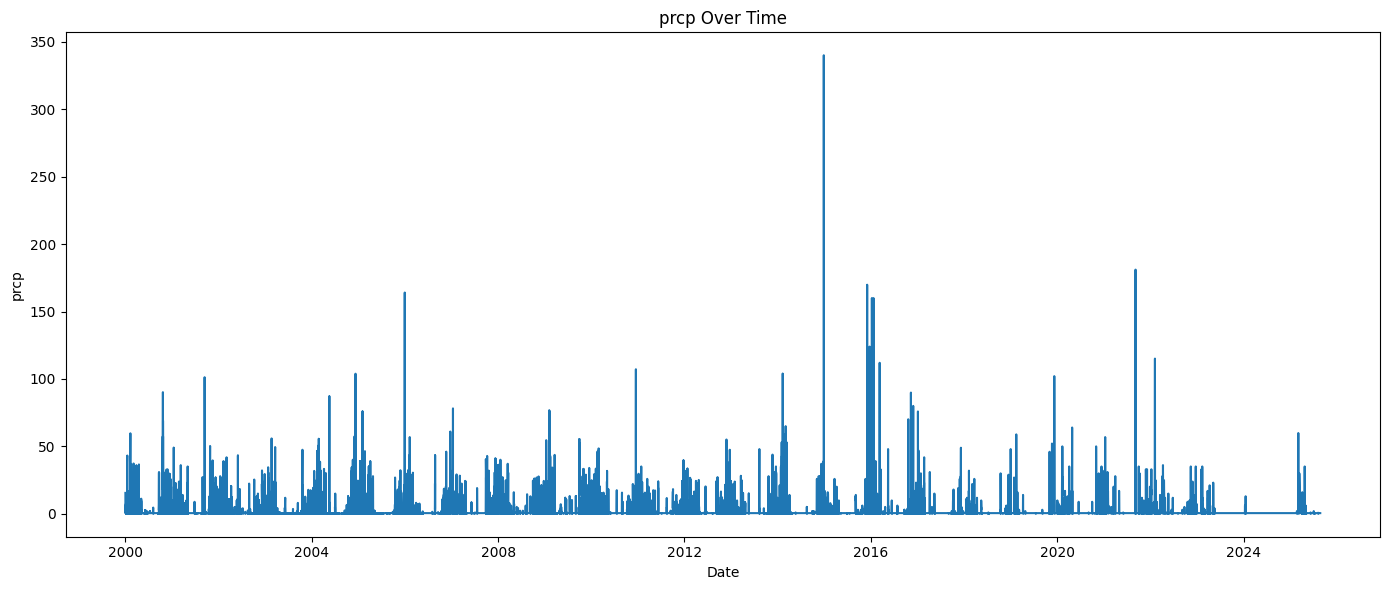

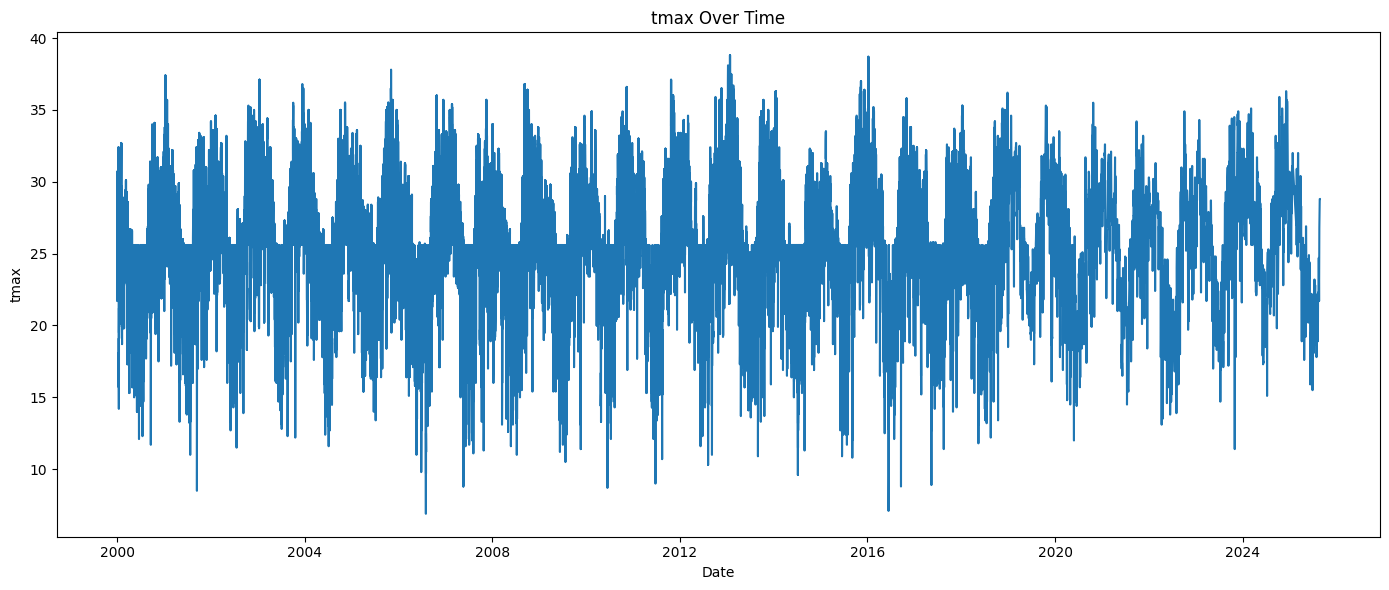

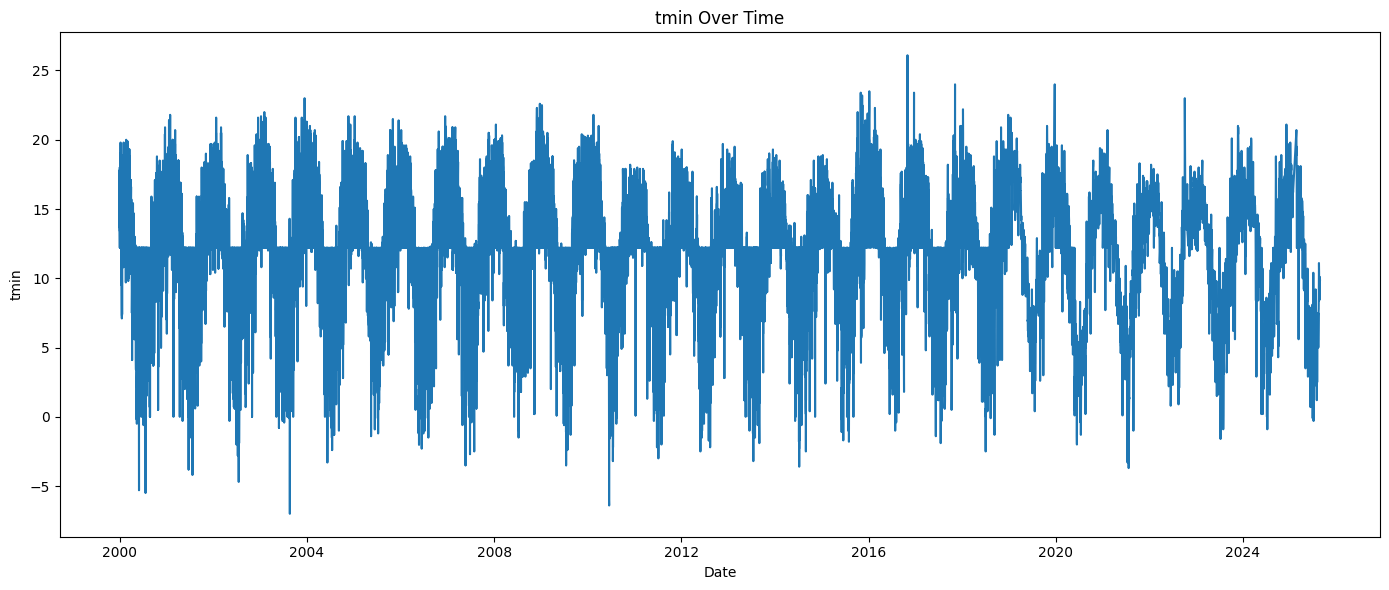

Weather time-series analysis complete.


In [16]:
# ============================================================
# WEATHER TIME-SERIES VISUALISATIONS
# ============================================================

if weather_name is not None:

    weather_df = cleaned_datasets[
        weather_name
    ].copy()

    # Find a usable date column.
    date_column = None

    for column in weather_df.columns:

        if pd.api.types.is_datetime64_any_dtype(
            weather_df[column]
        ):
            date_column = column
            break

    if date_column is None:

        for column in weather_df.columns:

            if str(column).lower() in [
                "date",
                "datetime",
                "timestamp",
                "time"
            ]:

                parsed = pd.to_datetime(
                    weather_df[column],
                    errors="coerce"
                )

                if parsed.notna().mean() >= 0.80:

                    weather_df[column] = parsed
                    date_column = column
                    break

    if date_column is None:

        print(
            "No usable date column found for weather time-series analysis."
        )

    else:

        weather_df = weather_df.sort_values(
            date_column
        )

        weather_plot_columns = [
            column
            for column in weather_df.columns
            if str(column).lower() in [
                "prcp",
                "tmax",
                "tmin",
                "temp",
                "temperature"
            ]
        ]

        for column in weather_plot_columns:

            if not pd.api.types.is_numeric_dtype(
                weather_df[column]
            ):
                continue

            plt.figure(
                figsize=(14, 6)
            )

            plt.plot(
                weather_df[date_column],
                weather_df[column]
            )

            plt.title(
                f"{column} Over Time"
            )

            plt.xlabel(
                "Date"
            )

            plt.ylabel(
                column
            )

            plt.tight_layout()

            safe_column = re.sub(
                r"[^A-Za-z0-9_.-]",
                "_",
                str(column)
            )

            plt.savefig(
                os.path.join(
                    EDA_VISUALISATION_DIR,
                    f"weather_{safe_column}_timeseries.png"
                ),
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()
            plt.close()

print("Weather time-series analysis complete.")


In [17]:
# ============================================================
# FEATURE ENGINEERING — WEATHER
# ============================================================

engineered_datasets = {
    name: df.copy()
    for name, df in cleaned_datasets.items()
}

if weather_name is not None:

    weather_features = cleaned_datasets[
        weather_name
    ].copy()

    # Identify a date column.
    date_column = None

    for column in weather_features.columns:

        if pd.api.types.is_datetime64_any_dtype(
            weather_features[column]
        ):
            date_column = column
            break

    if date_column is None:

        for column in weather_features.columns:

            if str(column).lower() in [
                "date",
                "datetime",
                "timestamp",
                "time"
            ]:

                parsed = pd.to_datetime(
                    weather_features[column],
                    errors="coerce"
                )

                if parsed.notna().mean() >= 0.80:

                    weather_features[column] = parsed
                    date_column = column
                    break

    if date_column is not None:

        weather_features = (
            weather_features
            .sort_values(date_column)
            .reset_index(drop=True)
        )

        weather_features["year"] = (
            weather_features[date_column].dt.year
        )

        weather_features["month"] = (
            weather_features[date_column].dt.month
        )

        weather_features["day"] = (
            weather_features[date_column].dt.day
        )

        weather_features["day_of_year"] = (
            weather_features[date_column].dt.dayofyear
        )

        weather_features["quarter"] = (
            weather_features[date_column].dt.quarter
        )

        # Cyclical month representation preserves seasonal continuity.
        weather_features["month_sin"] = np.sin(
            2 * np.pi *
            weather_features["month"] / 12
        )

        weather_features["month_cos"] = np.cos(
            2 * np.pi *
            weather_features["month"] / 12
        )

        # Rainfall features.
        prcp_column = next(
            (
                column
                for column in weather_features.columns
                if str(column).lower() in [
                    "prcp",
                    "precipitation",
                    "precip"
                ]
            ),
            None
        )

        if prcp_column is not None:

            weather_features["rainfall_present"] = (
                pd.to_numeric(
                    weather_features[prcp_column],
                    errors="coerce"
                )
                > 0
            ).astype(int)

            rainfall = pd.to_numeric(
                weather_features[prcp_column],
                errors="coerce"
            )

            weather_features["rainfall_7day"] = (
                rainfall.rolling(
                    7,
                    min_periods=1
                ).sum()
            )

            weather_features["rainfall_30day"] = (
                rainfall.rolling(
                    30,
                    min_periods=1
                ).sum()
            )

            weather_features["rainfall_90day"] = (
                rainfall.rolling(
                    90,
                    min_periods=1
                ).sum()
            )

            weather_features["rainfall_7day_mean"] = (
                rainfall.rolling(
                    7,
                    min_periods=1
                ).mean()
            )

        # Temperature range.
        tmax_column = next(
            (
                column
                for column in weather_features.columns
                if str(column).lower() == "tmax"
            ),
            None
        )

        tmin_column = next(
            (
                column
                for column in weather_features.columns
                if str(column).lower() == "tmin"
            ),
            None
        )

        if (
            tmax_column is not None
            and
            tmin_column is not None
        ):

            tmax = pd.to_numeric(
                weather_features[tmax_column],
                errors="coerce"
            )

            tmin = pd.to_numeric(
                weather_features[tmin_column],
                errors="coerce"
            )

            weather_features["temperature_range"] = (
                tmax - tmin
            )

            weather_features["tmax_7day_mean"] = (
                tmax.rolling(
                    7,
                    min_periods=1
                ).mean()
            )

            weather_features["tmin_7day_mean"] = (
                tmin.rolling(
                    7,
                    min_periods=1
                ).mean()
            )

        engineered_datasets[
            weather_name
        ] = weather_features

        print(
            "Weather features created:"
        )

        new_features = [
            column
            for column in weather_features.columns
            if column not in cleaned_datasets[weather_name].columns
        ]

        for feature in new_features:
            print("  +", feature)

    else:

        print(
            "Weather dataset has no usable date column; "
            "temporal features were not created."
        )

print("Weather feature engineering complete.")


Weather features created:
  + year
  + month
  + day
  + day_of_year
  + quarter
  + month_sin
  + month_cos
  + rainfall_present
  + rainfall_7day
  + rainfall_30day
  + rainfall_90day
  + rainfall_7day_mean
  + temperature_range
  + tmax_7day_mean
  + tmin_7day_mean
Weather feature engineering complete.


In [18]:
# ============================================================
# FEATURE ENGINEERING — NUMERIC CHANGE / TREND FEATURES
# ============================================================

for name, df in list(engineered_datasets.items()):

    engineered = df.copy()

    numeric_columns = list(
        engineered.select_dtypes(
            include=np.number
        ).columns
    )

    # Only create trend features for datasets that have a meaningful
    # row sequence. Do not apply arbitrary percentage changes to
    # categorical/non-numeric fields.
    if len(engineered) >= 3:

        for column in numeric_columns:

            # Avoid creating redundant changes for binary variables.
            unique_values = engineered[column].nunique()

            if unique_values <= 2:
                continue

            safe_column = re.sub(
                r"[^A-Za-z0-9_]",
                "_",
                str(column)
            )

            engineered[
                f"{safe_column}_change"
            ] = (
                pd.to_numeric(
                    engineered[column],
                    errors="coerce"
                ).diff()
            )

            engineered[
                f"{safe_column}_pct_change"
            ] = (
                pd.to_numeric(
                    engineered[column],
                    errors="coerce"
                )
                .pct_change()
                .replace(
                    [np.inf, -np.inf],
                    np.nan
                )
            )

    engineered_datasets[name] = engineered

print(
    "General numeric trend features created where appropriate."
)


General numeric trend features created where appropriate.


In [19]:
# ============================================================
# FEATURE ENGINEERING SUMMARY
# ============================================================

feature_summary_records = []

for name, df in engineered_datasets.items():

    original_df = cleaned_datasets[name]

    original_columns = set(
        original_df.columns
    )

    engineered_columns = set(
        df.columns
    )

    new_features = sorted(
        engineered_columns - original_columns
    )

    feature_summary_records.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Original Columns": original_df.shape[1],
        "Engineered Columns": df.shape[1],
        "New Features": len(new_features),
        "New Feature Names": "; ".join(
            map(str, new_features)
        ),
        "Numeric Features": len(
            df.select_dtypes(
                include=np.number
            ).columns
        ),
    })

feature_summary_df = pd.DataFrame(
    feature_summary_records
)

display(feature_summary_df)

feature_summary_df.to_csv(
    os.path.join(
        FEATURE_ENGINEERING_DIR,
        "feature_engineering_summary.csv"
    ),
    index=False
)

print("Feature engineering summary saved.")


,Dataset,Rows,Original Columns,Engineered Columns,New Features,New Feature Names,Numeric Features
0,Areas of Highest Vulnerability_ 2026_04_21,11,21,21,0,,0
1,Drinking Water Quality Compliance - SANS 241 _...,4,2,4,2,sans_241__2006_change; sans_241__2006_pct_change,3
2,Households Served with Water_ 2026_04_21,11,17,19,2,households_served_with_water_201415_change; ho...,4
3,Institutional Compliance_ 2026_04_21,11,5,9,4,effluent_water_compliance_percentage_change; e...,6
4,Microbiological _ Acute Health_ 2026_04_21,11,8,12,4,analysis_failed_change; analysis_failed_pct_ch...,6
5,NIWIS_GroundwaterStatus_16-Jul-2026,1946,8,8,0,,1
6,NIWIS_RWT_16-Jul-2026,9,5,11,6,domestic_and_industry_c_m3_change; domestic_an...,9
7,NIWIS_WasteWaterQuality_16-Jul-2026,143,5,5,0,,0
8,NIWIS_Water Supply Reliability - population_16...,144,13,13,0,,0
9,Operational_ 2026_04_21,11,8,12,4,analysis_failed_change; analysis_failed_pct_ch...,6


Feature engineering summary saved.


In [20]:
# ============================================================
# SAVE ENGINEERED DATASETS
# ============================================================

print("=" * 90)
print("SAVING ENGINEERED DATASETS")
print("=" * 90)

for name, df in engineered_datasets.items():

    safe_name = re.sub(
        r"[^A-Za-z0-9_.-]",
        "_",
        str(name)
    )

    output_path = os.path.join(
        FEATURE_ENGINEERING_DIR,
        f"{safe_name}_engineered.csv"
    )

    df.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved: {output_path}"
    )

print()
print("All engineered datasets saved.")


SAVING ENGINEERED DATASETS
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering/Areas_of_Highest_Vulnerability__2026_04_21_engineered.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering/Drinking_Water_Quality_Compliance_-_SANS_241__2006_-_National__From__2022-07-01_To__2026-06-30__engineered.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering/Households_Served_with_Water__2026_04_21_engineered.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering/Institutional_Compliance__2026_04_21_engineered.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering/Microbiological___Acute_Health__2026_04_21_engineered.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering/NIWIS_GroundwaterStatus_16-Jul-2026__engineered.csv
Saved: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering/NIWIS_RWT_16-Jul-2026__engineered.csv
Saved: /content/ANLOK-W

In [21]:
# ============================================================
# CREATE MODELLING-DATA CANDIDATES
# NOTEBOOK 4 WILL USE THESE OUTPUTS
# ============================================================

print("=" * 90)
print("CREATING MODELLING-DATA CANDIDATES")
print("=" * 90)

modelling_candidates = {}

for name, df in engineered_datasets.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    if numeric_df.shape[1] >= 2:

        modelling_candidates[name] = df.copy()

        safe_name = re.sub(
            r"[^A-Za-z0-9_.-]",
            "_",
            str(name)
        )

        output_path = os.path.join(
            MODELLING_DATA_DIR,
            f"{safe_name}_model_ready.csv"
        )

        df.to_csv(
            output_path,
            index=False
        )

        print(
            f"Model candidate: {name:<50}"
            f"Shape = {df.shape}"
        )

print()
print(
    f"Modelling candidates created: "
    f"{len(modelling_candidates)}"
)


CREATING MODELLING-DATA CANDIDATES
Model candidate: Drinking Water Quality Compliance - SANS 241 _2006 - National [From_ 2022-07-01 To_ 2026-06-30]Shape = (4, 4)
Model candidate: Households Served with Water_ 2026_04_21          Shape = (11, 19)
Model candidate: Institutional Compliance_ 2026_04_21              Shape = (11, 9)
Model candidate: Microbiological _ Acute Health_ 2026_04_21        Shape = (11, 12)
Model candidate: NIWIS_RWT_16-Jul-2026                             Shape = (9, 11)
Model candidate: Operational_ 2026_04_21                           Shape = (11, 12)
Model candidate: People Served with Water_ 2026_04_21              Shape = (11, 19)
Model candidate: Piped Water Households _ 2026_04_21               Shape = (10, 12)
Model candidate: Potable Systems_ 2026_04_21                       Shape = (61, 15)
Model candidate: Protests Identified by Municipal IQ_ 2026_04_21   Shape = (11, 42)
Model candidate: Surface Water Storage ( 2020 -2026)               Shape = (375, 25)

In [22]:
# ============================================================
# IDENTIFY POTENTIAL TARGET VARIABLES
# ============================================================

target_keywords = [
    "water_supply",
    "reliable_supply",
    "water_access",
    "supply",
    "storage",
    "water_quality",
    "compliance",
    "vulnerability",
    "demand",
    "water",
]

target_candidate_records = []

for name, df in engineered_datasets.items():

    for column in df.columns:

        column_lower = str(column).lower()

        matched_keywords = [
            keyword
            for keyword in target_keywords
            if keyword in column_lower
        ]

        if (
            matched_keywords
            and
            pd.api.types.is_numeric_dtype(
                df[column]
            )
        ):

            target_candidate_records.append({
                "Dataset": name,
                "Column": column,
                "Matched Keywords": ", ".join(
                    matched_keywords
                ),
                "Data Type": str(
                    df[column].dtype
                ),
                "Unique Values": int(
                    df[column].nunique()
                ),
                "Missing Values": int(
                    df[column].isna().sum()
                ),
            })

target_candidates_df = pd.DataFrame(
    target_candidate_records
)

display(target_candidates_df)

target_candidates_df.to_csv(
    os.path.join(
        MODELLING_DATA_DIR,
        "target_candidates.csv"
    ),
    index=False
)

print(
    "Target candidate inventory saved."
)

print()
print(
    "IMPORTANT: target_candidates.csv is a candidate list, "
    "not an automatic final target selection."
)


,Dataset,Column,Matched Keywords,Data Type,Unique Values,Missing Values
0,Households Served with Water_ 2026_04_21,households_served_with_water_201415,water,float64,7,0
1,Households Served with Water_ 2026_04_21,households_served_with_water_202122,water,float64,1,0
2,Households Served with Water_ 2026_04_21,households_served_with_water_201415_change,water,float64,8,1
3,Households Served with Water_ 2026_04_21,households_served_with_water_201415_pct_change,water,float64,4,6
4,Institutional Compliance_ 2026_04_21,potable_water_compliance_percentage,"compliance, water",float64,11,0
5,Institutional Compliance_ 2026_04_21,effluent_water_compliance_percentage,"compliance, water",float64,11,0
6,Institutional Compliance_ 2026_04_21,potable_water_compliance_percentage_change,"compliance, water",float64,10,1
7,Institutional Compliance_ 2026_04_21,potable_water_compliance_percentage_pct_change,"compliance, water",float64,10,1
8,Institutional Compliance_ 2026_04_21,effluent_water_compliance_percentage_change,"compliance, water",float64,10,1
9,Institutional Compliance_ 2026_04_21,effluent_water_compliance_percentage_pct_change,"compliance, water",float64,10,1


Target candidate inventory saved.

IMPORTANT: target_candidates.csv is a candidate list, not an automatic final target selection.


In [23]:
# ============================================================
# FINAL FEATURE ENGINEERING VALIDATION
# ============================================================

validation_records = []

for name, df in engineered_datasets.items():

    missing = int(
        df.isna().sum().sum()
    )

    duplicates = int(
        df.duplicated().sum()
    )

    numeric_df = df.select_dtypes(
        include=np.number
    )

    if not numeric_df.empty:

        numeric_values = (
            numeric_df
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy()
        )

        infinite = int(
            np.isinf(
                numeric_values
            ).sum()
        )

    else:

        infinite = 0

    validation_records.append({

        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Values": missing,
        "Duplicate Rows": duplicates,
        "Infinite Values": infinite,
        "Validation": (
            "PASS"
            if (
                missing == 0
                and duplicates == 0
                and infinite == 0
            )
            else "REVIEW"
        )
    })

feature_validation_df = pd.DataFrame(
    validation_records
)

display(feature_validation_df)

feature_validation_df.to_csv(
    os.path.join(
        FEATURE_ENGINEERING_DIR,
        "feature_engineering_validation.csv"
    ),
    index=False
)

print("Feature engineering validation saved.")


,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Infinite Values,Validation
0,Areas of Highest Vulnerability_ 2026_04_21,11,21,0,0,0,PASS
1,Drinking Water Quality Compliance - SANS 241 _...,4,4,2,0,0,REVIEW
2,Households Served with Water_ 2026_04_21,11,19,7,0,0,REVIEW
3,Institutional Compliance_ 2026_04_21,11,9,4,0,0,REVIEW
4,Microbiological _ Acute Health_ 2026_04_21,11,12,9,0,0,REVIEW
5,NIWIS_GroundwaterStatus_16-Jul-2026,1946,8,0,0,0,PASS
6,NIWIS_RWT_16-Jul-2026,9,11,7,0,0,REVIEW
7,NIWIS_WasteWaterQuality_16-Jul-2026,143,5,0,0,0,PASS
8,NIWIS_Water Supply Reliability - population_16...,144,13,0,0,0,PASS
9,Operational_ 2026_04_21,11,12,8,0,0,REVIEW


Feature engineering validation saved.


In [24]:
# ============================================================
# CREATE A HUMAN-READABLE NOTEBOOK 3 SUMMARY
# ============================================================

summary_records = [
    {
        "Metric": "Clean datasets received from Notebook 2",
        "Value": len(cleaned_datasets)
    },
    {
        "Metric": "Engineered datasets",
        "Value": len(engineered_datasets)
    },
    {
        "Metric": "Modelling candidates",
        "Value": len(modelling_candidates)
    },
    {
        "Metric": "Target candidates identified",
        "Value": len(target_candidates_df)
    },
    {
        "Metric": "EDA output directory",
        "Value": EDA_DIR
    },
    {
        "Metric": "Feature engineering output directory",
        "Value": FEATURE_ENGINEERING_DIR
    },
    {
        "Metric": "Modelling data directory",
        "Value": MODELLING_DATA_DIR
    },
]

notebook3_summary_df = pd.DataFrame(
    summary_records
)

display(notebook3_summary_df)

notebook3_summary_df.to_csv(
    os.path.join(
        EDA_DIR,
        "notebook3_summary.csv"
    ),
    index=False
)

print("Notebook 3 summary saved.")


,Metric,Value
0,Clean datasets received from Notebook 2,26
1,Engineered datasets,26
2,Modelling candidates,18
3,Target candidates identified,44
4,EDA output directory,/content/ANLOK-WATER-PREDICTION-PROJECT-/Outpu...
5,Feature engineering output directory,/content/ANLOK-WATER-PREDICTION-PROJECT-/Outpu...
6,Modelling data directory,/content/ANLOK-WATER-PREDICTION-PROJECT-/Outpu...


Notebook 3 summary saved.


In [25]:
# ============================================================
# GITHUB STATUS CHECK BEFORE PUSH
# ============================================================

os.chdir(PROJECT_ROOT)

status_result = subprocess.run(
    ["git", "status", "--short"],
    capture_output=True,
    text=True
)

print("=" * 90)
print("GITHUB STATUS")
print("=" * 90)

print(
    status_result.stdout
    if status_result.stdout.strip()
    else "No uncommitted changes detected."
)


GITHUB STATUS
?? Outputs/EDA/
?? Outputs/FeatureEngineering/
?? Outputs/ModellingData/



In [26]:
# ============================================================
# PUSH NOTEBOOK 3 RESULTS TO GITHUB
# ============================================================
#
# Authentication:
#   - The token is NOT stored in the notebook.
#   - If GITHUB_TOKEN is already available in the environment,
#     it is used.
#   - Otherwise, the user is securely prompted for a token.
#
# The token is supplied to Git only for the push command and is
# not written into the Git remote URL.
# ============================================================

import base64

print("=" * 90)
print("PUSHING NOTEBOOK 3 RESULTS TO GITHUB")
print("=" * 90)

os.chdir(PROJECT_ROOT)

# Configure commit identity for this repository.
subprocess.run(
    [
        "git",
        "config",
        "user.name",
        "ANLOK Water Prediction Project"
    ],
    check=False
)

subprocess.run(
    [
        "git",
        "config",
        "user.email",
        "anlok-water-project@users.noreply.github.com"
    ],
    check=False
)

# Stage Notebook 3 outputs.
subprocess.run(
    [
        "git",
        "add",
        "Outputs/EDA",
        "Outputs/FeatureEngineering",
        "Outputs/ModellingData"
    ],
    check=False
)

# Check whether there is anything to commit.
status_after_add = subprocess.run(
    ["git", "status", "--short"],
    capture_output=True,
    text=True
)

print()
print("Files staged:")
print(
    status_after_add.stdout
    if status_after_add.stdout.strip()
    else "No changes to commit."
)

if status_after_add.stdout.strip():

    commit_result = subprocess.run(
        [
            "git",
            "commit",
            "-m",
            "Add Notebook 3 EDA and feature engineering results"
        ],
        capture_output=True,
        text=True
    )

    print()
    print("Commit:")
    print(commit_result.stdout)

    if commit_result.returncode != 0:
        print(commit_result.stderr)

        raise RuntimeError(
            "Git commit failed."
        )

# ------------------------------------------------------------
# AUTHENTICATED PUSH
# ------------------------------------------------------------

token = os.environ.get(
    "GITHUB_TOKEN",
    ""
).strip()

if not token:

    print()
    print(
        "No GITHUB_TOKEN environment variable was found."
    )

    token = getpass(
        "Enter a GitHub Personal Access Token with repository write access: "
    ).strip()

if not token:

    raise RuntimeError(
        "No GitHub token was provided. "
        "The results were saved locally but were not pushed."
    )

username = os.environ.get(
    "GITHUB_USERNAME",
    "LulutheBA"
).strip()

auth_string = f"{username}:{token}"
encoded_auth = base64.b64encode(
    auth_string.encode()
).decode()

push_result = subprocess.run(
    [
        "git",
        "-c",
        f"http.extraHeader=AUTHORIZATION: basic {encoded_auth}",
        "push",
        "origin",
        "HEAD:main"
    ],
    capture_output=True,
    text=True
)

# Remove the local token variable as soon as the push completes.
token = ""
auth_string = ""
encoded_auth = ""

print()
print("GitHub push output:")
print(push_result.stdout)

if push_result.returncode != 0:

    print(push_result.stderr)

    raise RuntimeError(
        "GitHub push failed. "
        "Check that the token has repository write permission "
        "and that the repository branch is main."
    )

print()
print("=" * 90)
print("SUCCESS — NOTEBOOK 3 RESULTS PUSHED TO GITHUB")
print("=" * 90)


PUSHING NOTEBOOK 3 RESULTS TO GITHUB

Files staged:
A  Outputs/EDA/Households_Served_with_Water__2026_04_21_correlation_matrix.csv
A  Outputs/EDA/Institutional_Compliance__2026_04_21_correlation_matrix.csv
A  Outputs/EDA/Microbiological___Acute_Health__2026_04_21_correlation_matrix.csv
A  Outputs/EDA/NIWIS_RWT_16-Jul-2026__correlation_matrix.csv
A  Outputs/EDA/Operational__2026_04_21_correlation_matrix.csv
A  Outputs/EDA/People_Served_with_Water__2026_04_21_correlation_matrix.csv
A  Outputs/EDA/Piped_Water_Households___2026_04_21_correlation_matrix.csv
A  Outputs/EDA/Potable_Systems__2026_04_21_correlation_matrix.csv
A  Outputs/EDA/Protests_Identified_by_Municipal_IQ__2026_04_21_correlation_matrix.csv
A  Outputs/EDA/Surface_Water_Storage__2014-2020__correlation_matrix.csv
A  Outputs/EDA/Surface_Water_Storage___2020_-2026__correlation_matrix.csv
A  Outputs/EDA/Visualisations/Drinking_Water_Quality_Compliance_-_SANS_241__2006_-_National__From__2022-07-01_To__2026-06-30__sans_241__2006_bo

In [27]:
# ============================================================
# NOTEBOOK 3 COMPLETION SUMMARY
# ============================================================

print()
print("=" * 90)
print("NOTEBOOK 3 COMPLETE")
print("=" * 90)

print()
print("INPUT FROM NOTEBOOK 2:")
print(CLEAN_DATA_DIR)

print()
print("EDA OUTPUTS:")
print(EDA_DIR)

print()
print("EDA VISUALISATIONS:")
print(EDA_VISUALISATION_DIR)

print()
print("FEATURE ENGINEERING OUTPUTS:")
print(FEATURE_ENGINEERING_DIR)

print()
print("MODELLING DATA:")
print(MODELLING_DATA_DIR)

print()
print("NEXT:")
print("Notebook 4 — Model Development, Training and Validation")

print()
print("All Notebook 3 analysis outputs are designed to be committed")
print("and pushed back to the same GitHub repository.")



NOTEBOOK 3 COMPLETE

INPUT FROM NOTEBOOK 2:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/CleanData

EDA OUTPUTS:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/EDA

EDA VISUALISATIONS:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/EDA/Visualisations

FEATURE ENGINEERING OUTPUTS:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/FeatureEngineering

MODELLING DATA:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/ModellingData

NEXT:
Notebook 4 — Model Development, Training and Validation

All Notebook 3 analysis outputs are designed to be committed
and pushed back to the same GitHub repository.
